In [ ]:
!pip install transformers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/receptor
#!git clone https://github.com/kexinhuang12345/DeepPurpose.git  # 只需运行一次
%cd DeepPurpose


Mounted at /content/drive
/content/drive/MyDrive/receptor
/content/drive/MyDrive/receptor/DeepPurpose


In [ ]:
'''
!pip install  torch==1.13.1 torchvision==0.14.1 torchaudio==0.13.1
!pip install  gpytorch==1.9.1 botorch==0.8.5
!pip install  numpy==1.21.6 pandas==1.3.5 scikit-learn==0.24.2 scipy==1.7.3 seaborn tqdm matplotlib
!pip install  rdkit-pypi descriptastorus
!pip install  jupyter notebook
!pip install  autograd autograd-gamma ax-platform lifelines prettytable subword-nmt wget
!pip install  requests==2.23.0 urllib3==1.25.8
'''

'\n!pip install  torch==1.13.1 torchvision==0.14.1 torchaudio==0.13.1\n!pip install  gpytorch==1.9.1 botorch==0.8.5\n!pip install  numpy==1.21.6 pandas==1.3.5 scikit-learn==0.24.2 scipy==1.7.3 seaborn tqdm matplotlib\n!pip install  rdkit-pypi descriptastorus\n!pip install  jupyter notebook\n!pip install  autograd autograd-gamma ax-platform lifelines prettytable subword-nmt wget\n!pip install  requests==2.23.0 urllib3==1.25.8\n'

In [ ]:
# Install official rdkit
!pip install rdkit

# Read version number
import rdkit
RDV = rdkit.__version__
print("Current rdkit version:", RDV)

# Create alias package directory
!rm -rf /content/rdkit_pypi_alias
!mkdir -p /content/rdkit_pypi_alias

# Write pyproject.toml file
with open("/content/rdkit_pypi_alias/pyproject.toml", "w") as f:
    f.write(f"""
[build-system]
requires = ["setuptools>=61"]
build-backend = "setuptools.build_meta"

[project]
name = "rdkit-pypi"
version = "{RDV}"          # If old project pinned a specific version, change to that
description = "Compatibility alias: rdkit-pypi -> rdkit"
requires-python = ">=3.8"
dependencies = ["rdkit>={RDV}"]
""")

# Install alias package
!pip install /content/rdkit_pypi_alias

# Verify
!pip show rdkit-pypi
import rdkit
from rdkit import Chem
print("RDKit version:", rdkit.__version__)
print("Benzene atoms:", Chem.MolFromSmiles("c1ccccc1").GetNumAtoms())
print("✅ Alias rdkit-pypi installed, compatible with old dependencies.")
!pip install descriptastorus


In [ ]:
!pip install  .

Processing /content/drive/MyDrive/receptor/DeepPurpose
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%cd
!pip install alphashape
import sys
import torch
import torch.nn.functional as F
from DeepPurpose import DTI as models
from DeepPurpose import utils, dataset
import pandas as pd
from pprint import pprint
from IPython.display import Image
from collections import defaultdict
from typing import List, Dict
from torch.utils.data import Dataset, DataLoader
import random
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.optim import Adam
from typing import Callable, Optional, List, Union
from tqdm import tqdm
import os
import pickle
import numpy as np
from torch.utils.data import random_split
from torch.amp import GradScaler, autocast
from contextlib import nullcontext
from typing import Callable, List, Optional, Union
import re
from sklearn.cluster import MiniBatchKMeans, KMeans
import json
import matplotlib as plt
plt.rcParams['font.family'] = 'Liberation Sans'



/root
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 19.5 MB/s eta 0:00:00


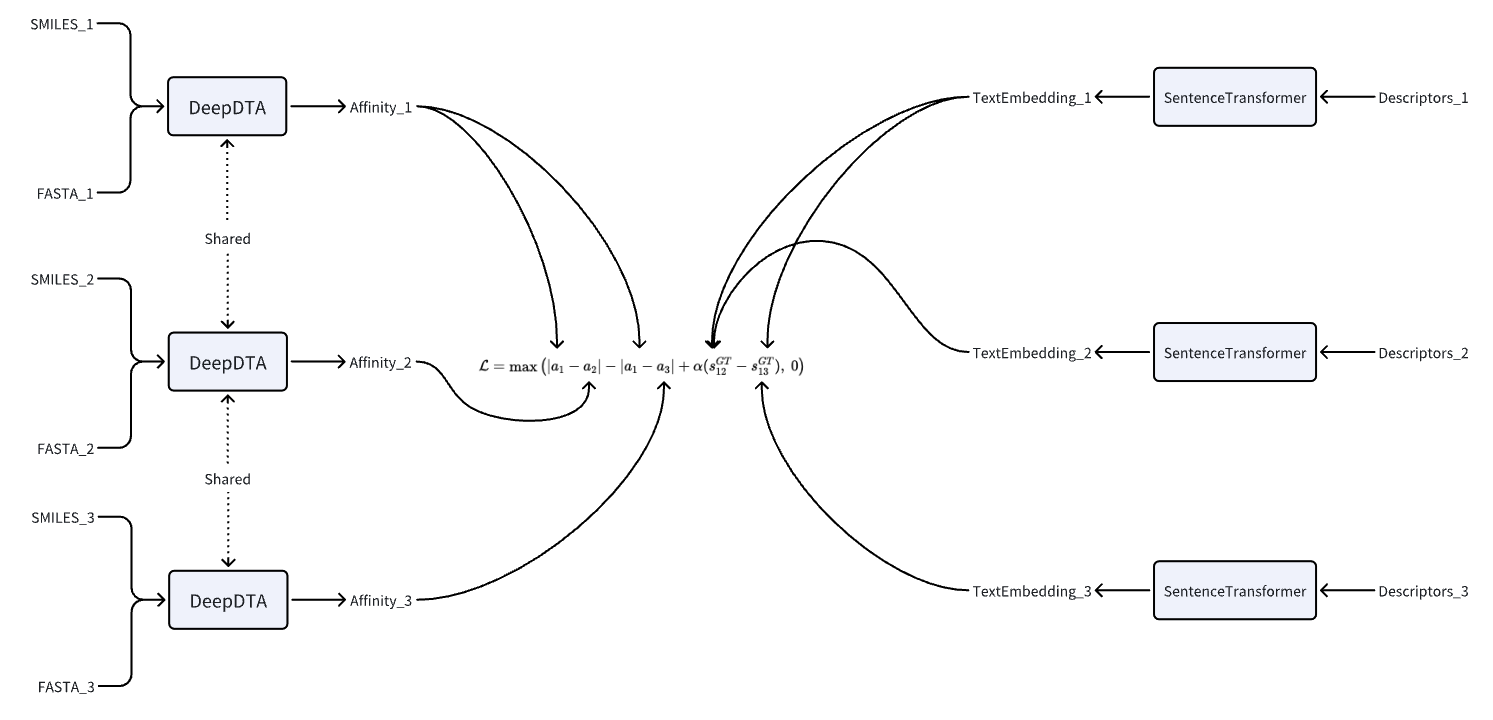

In [ ]:
%ls /content/drive/MyDrive/receptor/

 cleaned_odor_data/
 dataclean.ipynb
 DeepPurpose/
 models/
 modified_receptormap_triplet.ipynb
 Multi-Labelled_Smiles_Odors_dataset.csv
 odor_dict_cleaned_CAS.csv
 odor_dict_cleaned_CID.csv
 odor_dict_cleaned.csv
 pyrfume_downloaded_data/
 rankinganalysis.ipynb
 receptormap.ipynb
 receptor_map_prediction.ipynb
 receptormap_triplet.ipynb（副本）
 reeceptorlist.gsheet
 reeceptorlist.xlsx
 result/
 scent_multilabel_prediction_unimol-odormap-reproduce-openpom+ORs.ipynb
 scent_multilabel_prediction_unimol-odormap-reproduce-predo3.ipynb
 sequences_cleaned.csv
 splitcsv.ipynb
 Table_S1_Pred-O3.csv
 test11.csv
 test1.csv
 Untitled
'无标题文档 (1).gdoc'
 无标题文档.gdoc


In [ ]:
class TextEncoder(torch.nn.Module):
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2'):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name)

    def forward(self, texts):
        tokens = self.tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
        with torch.no_grad():
            outputs = self.encoder(**tokens)
        return F.normalize(outputs.last_hidden_state[:, 0, :], p=2, dim=1)

text_encoder = TextEncoder()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# validate deeppurpose model

In [ ]:
# Download and get model path
path = utils.download_pretrained_model('MPNN_CNN_BindingDB')

# Load model
net = models.model_pretrained(path_dir=path)


import pprint as pp



# Compatible with different config types: dict / Namespace / other objects
cfg_obj = net.config
try:
    cfg = dict(cfg_obj)
except Exception:
    try:
        cfg = vars(cfg_obj)  # e.g., argparse.Namespace
    except Exception:
        # Fallback: only print the object itself
        cfg = {}

# Key information
keys = [
    'drug_encoding','target_encoding',
    'hidden_dim_drug','hidden_dim_protein',
    'cnn_target_filters','cnn_target_kernels',
    'cls_hidden_dims','gnn_hop','mpnn_depth',
]
pp.pprint({k: cfg.get(k, None) for k in keys})

# Read structure/shape directly from the model
print("dropout p =", net.model.dropout.p)
print("protein conv kernels =", [m.kernel_size for m in net.model.model_protein.conv])
print("protein conv channels =", [(m.in_channels, m.out_channels) for m in net.model.model_protein.conv])
print("protein fc1 in/out =", net.model.model_protein.fc1.in_features, net.model.model_protein.fc1.out_features)
print("predictor dims =", [(m.in_features, m.out_features) for m in net.model.predictor])
print("MPNN hidden =", net.model.model_drug.W_i.out_features)


pretrained model Successfully Downloaded...
{'cls_hidden_dims': [1024, 1024, 512],
 'cnn_target_filters': [32, 64, 96],
 'cnn_target_kernels': [4, 8, 12],
 'drug_encoding': 'MPNN',
 'gnn_hop': None,
 'hidden_dim_drug': 128,
 'hidden_dim_protein': 256,
 'mpnn_depth': 3,
 'target_encoding': 'CNN'}
dropout p = 0.1
protein conv kernels = [(4,), (8,), (12,)]
protein conv channels = [(26, 32), (32, 64), (64, 96)]
protein fc1 in/out = 96 256
predictor dims = [(384, 1024), (1024, 1024), (1024, 512), (512, 1)]
MPNN hidden = 128


model with same structure

In [ ]:

class MPNN(nn.Module):

    def __init__(
        self,
        atom_in: int = 50,
        hidden: int = 128,
        readout_in: int = 167,
        *,
        aggregator: str = "mean",       # ["mean","sum","max","attn"]
        combine: str = "gated",         # ["gated","concat","avg"]
        dropout_p: float = 0.1,
        use_layernorm: bool = True,
        act: str = "silu",              # ["relu","gelu","silu"]
        init: str = "kaiming_uniform"   # ["kaiming_uniform","xavier_uniform","none"]
    ):
        super().__init__()
        self.hidden = hidden
        self.aggregator = aggregator
        self.combine = combine
        self.use_layernorm = use_layernorm
        self.dropout = nn.Dropout(dropout_p)

        # Linear mapping
        self.W_i = nn.Linear(atom_in, hidden, bias=True)
        self.W_h = nn.Linear(hidden, hidden, bias=True)
        self.W_o = nn.Linear(readout_in, hidden, bias=True)

        # Learnable fusion (gated or concat)
        if combine == "gated":
            self.gate = nn.Parameter(torch.zeros(hidden))  # Broadcast to (B, hidden)
        elif combine == "concat":
            self.proj = nn.Linear(hidden * 2, hidden, bias=True)

        # Attention pooling
        if aggregator == "attn":
            self.q = nn.Linear(hidden, hidden, bias=False)
            self.k = nn.Linear(hidden, hidden, bias=False)

        # Normalization
        if use_layernorm:
            self.ln_h = nn.LayerNorm(hidden)
            self.ln_o = nn.LayerNorm(hidden)

        # Activation function selection
        if act == "relu":
            self.act = F.relu
        elif act == "gelu":
            self.act = F.gelu
        else:
            self.act = F.silu

        # Initialization
        if init != "none":
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    if init == "kaiming_uniform":
                        nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                    elif init == "xavier_uniform":
                        nn.init.xavier_uniform_(m.weight)
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

    @staticmethod
    def _masked_mean(x: torch.Tensor, mask: Optional[torch.Tensor]) -> torch.Tensor:
        # x: (B,N,D), mask: (B,N) bool
        if mask is None:
            return x.mean(dim=1)
        mask = mask.to(dtype=torch.bool)
        mask_f = mask.unsqueeze(-1).to(x.dtype)
        denom = mask_f.sum(dim=1).clamp_min(1.0)               # (B,1)
        num = (x * mask_f).sum(dim=1)                          # (B,D)
        # If a sample is all False, return a zero vector
        zero_batch = (denom.squeeze(-1) == 0)
        out = num / denom
        if zero_batch.any():
            out[zero_batch] = 0.0
        return out

    @staticmethod
    def _masked_sum(x: torch.Tensor, mask: Optional[torch.Tensor]) -> torch.Tensor:
        if mask is None:
            return x.sum(dim=1)
        mask_f = mask.unsqueeze(-1).to(x.dtype)
        return (x * mask_f).sum(dim=1)

    @staticmethod
    def _masked_max(x: torch.Tensor, mask: Optional[torch.Tensor]) -> torch.Tensor:
        if mask is None:
            return x.max(dim=1).values
        # Set masked elements to a very small value
        very_neg = torch.finfo(x.dtype).min
        mask_f = mask.unsqueeze(-1).to(x.dtype)
        x_masked = x * mask_f + (1.0 - mask_f) * very_neg
        return x_masked.max(dim=1).values

    def _attn_pool(self, nodes: torch.Tensor, mask: Optional[torch.Tensor]) -> torch.Tensor:
        """
        Concise single-query attention pooling: weighted aggregation of nodes using a query vector derived from the mean of the nodes themselves.
        nodes: (B,N,D)
        """
        B, N, D = nodes.shape
        # First, calculate a rough mean to get the source of q (can be masked)
        base = self._masked_mean(nodes, mask)                  # (B,D)
        q = self.q(base).unsqueeze(1)                          # (B,1,D)
        k = self.k(nodes)                                      # (B,N,D)
        logits = (q * k).sum(-1) / (D ** 0.5)                  # (B,N)

        if mask is not None:
            mask = mask.to(torch.bool)
            logits = logits.masked_fill(~mask, float("-inf"))

        attn = torch.softmax(logits, dim=1)                    # (B,N)
        pooled = torch.bmm(attn.unsqueeze(1), nodes).squeeze(1)# (B,D)
        return pooled

    def _aggregate(self, x_nodes: torch.Tensor, mask: Optional[torch.Tensor]) -> torch.Tensor:
        if self.aggregator == "sum":
            return self._masked_sum(x_nodes, mask)
        elif self.aggregator == "max":
            return self._masked_max(x_nodes, mask)
        elif self.aggregator == "attn":
            return self._attn_pool(x_nodes, mask)
        else:  # "mean"
            return self._masked_mean(x_nodes, mask)

    def forward(
        self,
        atom_feat: torch.Tensor,    # (B,N,50)
        msg_feat: torch.Tensor,     # (B,N,128)
        readout_feat: torch.Tensor, # (B,N,167)
        mask: Optional[torch.Tensor] = None  # (B,N) bool
    ) -> torch.Tensor:
        # Node-level representation
        x0 = self.W_i(atom_feat)                         # (B,N,128)
        h_nodes = self.act(x0 + self.W_h(msg_feat))      # (B,N,128)
        o_nodes = self.act(self.W_o(readout_feat))       # (B,N,128)

        if self.use_layernorm:
            # Apply LayerNorm to node dimension for stability
            h_nodes = self.ln_h(h_nodes)
            o_nodes = self.ln_o(o_nodes)

        # Pooling (supports masking)
        h = self._aggregate(h_nodes, mask)               # (B,128)
        o = self._aggregate(o_nodes, mask)               # (B,128)

        # Fusion
        if self.combine == "gated":
            g = torch.sigmoid(self.gate).unsqueeze(0)    # (1,128) -> broadcast to (B,128)
            out = g * h + (1 - g) * o
        elif self.combine == "concat":
            out = self.proj(torch.cat([h, o], dim=-1))
        else:  # "avg"
            out = 0.5 * (h + o)

        out = self.dropout(out)
        return out                                       # (B,128)

class CNN(nn.Module):
    def __init__(self, in_ch=26, c1=32, c2=64, c3=96, fc1_out=256, p_drop=0.1,
                 act='relu'):
        super().__init__()
        # === The definition of these layers is exactly the same as the old model (names, order, and shape are all the same) ===
        self.conv = nn.ModuleList([
            nn.Conv1d(in_ch, c1, kernel_size=4, stride=1),   # conv.0
            nn.Conv1d(c1,  c2, kernel_size=8, stride=1),     # conv.1
            nn.Conv1d(c2,  c3, kernel_size=12, stride=1),    # conv.2
        ])
        self.fc1 = nn.Linear(c3, fc1_out)                    # Shape remains (96 -> 256)

        # === Newly added "activation/normalization" are all parameter-free modules, which do not affect state_dict ===
        def make_act():
            if act == 'relu':
                return nn.ReLU(inplace=True)
            elif act == 'gelu':
                return nn.GELU()
            elif act == 'silu':
                return nn.SiLU(inplace=True)
            else:
                return nn.ReLU(inplace=True)

        self.post_convs_act = nn.ModuleList([make_act(), make_act(), make_act()])
        self.post_fc_act = make_act()
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):  # x: (B, 26, L)
        # Add extra activation after convolutional layers, but do not change state_dict keys/shapes
        for conv, act in zip(self.conv, self.post_convs_act):
            x = act(conv(x))

        # Still only performs max-pooling; output dimension is still c3 (=96)
        x = torch.amax(x, dim=2)  # (B, c3)

        # Fully connected layer maintains old shape; add activation and dropout afterwards (both parameter-free)
        x = self.fc1(x)           # (B, 256)
        x = self.post_fc_act(x)
        x = self.dropout(x)
        return x


class Classifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.model_drug    = MPNN(cfg["mpnn_atom_in"], cfg["mpnn_hidden"], cfg["mpnn_readout_in"])
        self.model_protein = CNN(cfg["cnn_in_ch"], cfg["cnn_c1"], cfg["cnn_c2"], cfg["cnn_c3"], cfg["cnn_fc1_out"])
        self.dropout = nn.Dropout(p=cfg.get("dropout_p", 0.1))
        dims = cfg["mlp_dims"]  # [384,1024,1024,512,1]
        self.predictor = nn.ModuleList([nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])

    def forward(self, atom_feat, msg_feat, readout_feat, protein_onehot, mask=None):
        h_d = self.model_drug(atom_feat, msg_feat, readout_feat, mask=mask)  # (B,128)
        h_p = self.model_protein(protein_onehot)                              # (B,256)
        x = self.dropout(torch.cat([h_d, h_p], dim=1))                        # (B,384)
        for i, layer in enumerate(self.predictor):
            x = layer(x)
            if i < len(self.predictor)-1:
                x = F.relu(x)
        return x.squeeze(-1)  # (B,)

In [ ]:
# 3) Export necessary hyperparameters

cfg = {
    "mpnn_atom_in": 50,        # W_i.in_features
    "mpnn_hidden": 128,        # W_i/W_h/W_o out_features
    "mpnn_readout_in": 167,    # W_o.in_features
    "cnn_in_ch": 26,           # Conv1d input channels
    "cnn_c1": 32, "cnn_c2": 64, "cnn_c3": 96,
    "cnn_fc1_out": 256,        # Linear(96,256)
    "mlp_dims": [384, 1024, 1024, 512, 1],
    "dropout_p": 0.1
}
standalone = Classifier(cfg)
#state = net.model.state_dict()   # Directly use DeepPurpose weights
#missing, unexpected = standalone.load_state_dict(state, strict=False)
#print("missing:", missing)
#print("unexpected:", unexpected)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
standalone.to(device).eval()

Classifier(
  (model_drug): MPNN(
    (dropout): Dropout(p=0.1, inplace=False)
    (W_i): Linear(in_features=50, out_features=128, bias=True)
    (W_h): Linear(in_features=128, out_features=128, bias=True)
    (W_o): Linear(in_features=167, out_features=128, bias=True)
    (ln_h): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (ln_o): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (model_protein): CNN(
    (conv): ModuleList(
      (0): Conv1d(26, 32, kernel_size=(4,), stride=(1,))
      (1): Conv1d(32, 64, kernel_size=(8,), stride=(1,))
      (2): Conv1d(64, 96, kernel_size=(12,), stride=(1,))
    )
    (fc1): Linear(in_features=96, out_features=256, bias=True)
    (post_convs_act): ModuleList(
      (0-2): 3 x ReLU(inplace=True)
    )
    (post_fc_act): ReLU(inplace=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (predictor): ModuleList(
    (0): Linear(in_features=384, out_features=1024, bias=True)
    (1): 

Import parameters

In [ ]:
from DeepPurpose import encoders as dp_enc
from types import MethodType
def patch_classifier_to_use_dp_mpnn(standalone, mpnn_depth=3):

    device = next(standalone.parameters()).device
    old = standalone.model_drug
    hidden = old.W_i.out_features  # 128

    # 1) Build DP native MPNN
    dp_mpnn = dp_enc.MPNN(mpnn_hidden_size=hidden, mpnn_depth=mpnn_depth).to(device)
    dp_mpnn.eval()

    # 2) Copy weights (shapes are exactly the same)
    with torch.no_grad():
        dp_mpnn.W_i.weight.copy_(old.W_i.weight.data)
        dp_mpnn.W_h.weight.copy_(old.W_h.weight.data)
        dp_mpnn.W_o.weight.copy_(old.W_o.weight.data)

    # 3) Replace
    standalone.model_drug = dp_mpnn


    def forward_dp(self, drug_feature_tuple, protein_onehot):
        h_d = self.model_drug(drug_feature_tuple)     # DP encoders.MPNN.forward
        h_p = self.model_protein(protein_onehot)      # CNN(26,L) → 256
        x = self.dropout(torch.cat([h_d, h_p], dim=1))# 384
        for i, layer in enumerate(self.predictor):
            x = layer(x)
            if i < len(self.predictor) - 1:
                x = torch.relu(x)
        return x.squeeze(-1)

    standalone.forward_dp = MethodType(forward_dp, standalone)
    return standalone

# Execute replacement (using the confirmed mpnn_depth=3)
standalone = patch_classifier_to_use_dp_mpnn(standalone, mpnn_depth=3)
# Load all DP model weights (where keys match) into your modified standalone
dp_sd = net.model.state_dict()
own_sd = standalone.state_dict()

# Filter out keys with matching shapes for safety
compatible = {k: v for k, v in dp_sd.items() if k in own_sd and own_sd[k].shape == v.shape}
own_sd.update(compatible)
standalone.load_state_dict(own_sd)  # Equivalent to strict=False but more controllable


<All keys matched successfully>

Model used for comparison

In [ ]:
cfg = {
    "mpnn_atom_in": 50,        # W_i.in_features
    "mpnn_hidden": 128,        # W_i/W_h/W_o out_features
    "mpnn_readout_in": 167,    # W_o.in_features
    "cnn_in_ch": 26,           # Conv1d input channels
    "cnn_c1": 32, "cnn_c2": 64, "cnn_c3": 96,
    "cnn_fc1_out": 256,        # Linear(96,256)
    "mlp_dims": [384, 1024, 1024, 512, 1],
    "dropout_p": 0.1
}
model_ctl = Classifier(cfg)
state = net.model.state_dict()   # Directly use DeepPurpose weights


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ctl.to(device).eval()
# Execute replacement (using the confirmed mpnn_depth=3)
model_ctl = patch_classifier_to_use_dp_mpnn(model_ctl, mpnn_depth=3)
# Load all DP model weights (where keys match) into your modified model_ctl
dp_sd = net.model.state_dict()
own_sd = model_ctl.state_dict()

# Filter out keys with matching shapes for safety
compatible = {k: v for k, v in dp_sd.items() if k in own_sd and own_sd[k].shape == v.shape}
own_sd.update(compatible)
model_ctl.load_state_dict(own_sd)  # Equivalent to strict=False but more controllable

<All keys matched successfully>

In [ ]:

def protein_chars_to_cnn_tensor(chars):
    # Keep 26 channels (including '?'), align with Conv1d(26,32,4)
    oh_LC = enc_protein.transform(np.array(chars).reshape(-1, 1)).toarray()  # (L,26)
    return torch.tensor(oh_LC.T.astype(np.float32))  # (26, L)

def predict_pairs_strings(model, smiles_list, protein_list, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device).eval()

    # First calculate protein embeddings
    prot_embeds = []
    prot_inputs = []
    with torch.no_grad():
        for seq in protein_list:
            chars = trans_protein(seq)  # pad to 1000
            prot = protein_chars_to_cnn_tensor(chars).unsqueeze(0).to(device)  # (1,26,L)
            hp = model.model_protein(prot)
            prot_embeds.append(hp)
            prot_inputs.append(prot)

    out = np.zeros((len(smiles_list), len(protein_list)), dtype=float)
    with torch.no_grad():
        for i, smi in enumerate(smiles_list):
            f_atoms, f_bonds, agraph, bgraph, shape = smiles2mpnnfeature(smi)
            feat_tuple = (
                f_atoms.unsqueeze(0).to(device),        # (1, MAX_ATOM, 39)
                f_bonds.unsqueeze(0).to(device),        # (1, MAX_BOND, 50)
                agraph.unsqueeze(0).long().to(device),  # (1, MAX_ATOM, 6)
                bgraph.unsqueeze(0).long().to(device),  # (1, MAX_BOND, 6)
                shape.unsqueeze(0).to(device)           # (1,1,2)
            )

            for j, prot in enumerate(prot_inputs):
                y = model(feat_tuple, prot)  # -> (1,)
                out[i, j] = float(y.item())
    return out


tool functions (from deeppurpose)

In [ ]:
import rdkit
import rdkit.Chem as Chem
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from collections import defaultdict
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions
import torch

def get_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    Chem.Kekulize(mol)
    return mol

ELEM_LIST = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 'Na', 'Ca', 'Fe', 'Al', 'I', 'B', 'K', 'Se', 'Zn', 'H', 'Cu', 'Mn', 'unknown']
ATOM_FDIM = len(ELEM_LIST) + 6 + 5 + 4 + 1
BOND_FDIM = 5 + 6
MAX_NB = 6
### basic setting from https://github.com/wengong-jin/iclr19-graph2graph/blob/master/fast_jtnn/mpn.py

def onek_encoding_unk(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]
    return list(map(lambda s: x == s, allowable_set))

def atom_features(atom):
    return torch.Tensor(onek_encoding_unk(atom.GetSymbol(), ELEM_LIST)
            + onek_encoding_unk(atom.GetDegree(), [0,1,2,3,4,5])
            + onek_encoding_unk(atom.GetFormalCharge(), [-1,-2,1,2,0])
            + onek_encoding_unk(int(atom.GetChiralTag()), [0,1,2,3])
            + [atom.GetIsAromatic()])


def bond_features(bond):
    bt = bond.GetBondType()
    stereo = int(bond.GetStereo())
    fbond = [bt == Chem.rdchem.BondType.SINGLE, bt == Chem.rdchem.BondType.DOUBLE, bt == Chem.rdchem.BondType.TRIPLE, bt == Chem.rdchem.BondType.AROMATIC, bond.IsInRing()]
    fstereo = onek_encoding_unk(stereo, [0,1,2,3,4,5])
    return torch.Tensor(fbond + fstereo)
# '?' padding
amino_char = ['?', 'A', 'C', 'B', 'E', 'D', 'G', 'F', 'I', 'H', 'K', 'M', 'L', 'O',
       'N', 'Q', 'P', 'S', 'R', 'U', 'T', 'W', 'V', 'Y', 'X', 'Z']

smiles_char = ['?', '#', '%', ')', '(', '+', '-', '.', '1', '0', '3', '2', '5', '4',
       '7', '6', '9', '8', '=', 'A', 'C', 'B', 'E', 'D', 'G', 'F', 'I',
       'H', 'K', 'M', 'L', 'O', 'N', 'P', 'S', 'R', 'U', 'T', 'W', 'V',
       'Y', '[', 'Z', ']', '_', 'a', 'c', 'b', 'e', 'd', 'g', 'f', 'i',
       'h', 'm', 'l', 'o', 'n', 's', 'r', 'u', 't', 'y']

from sklearn.preprocessing import OneHotEncoder
enc_protein = OneHotEncoder().fit(np.array(amino_char).reshape(-1, 1))
enc_drug = OneHotEncoder().fit(np.array(smiles_char).reshape(-1, 1))

MAX_SEQ_PROTEIN = 1000
MAX_SEQ_DRUG = 100
MAX_ATOM = 200
MAX_BOND = 600
def trans_protein(x):

	temp = list(x.upper())
	temp = [i if i in amino_char else '?' for i in temp]
	if len(temp) < MAX_SEQ_PROTEIN:
		temp = temp + ['?'] * (MAX_SEQ_PROTEIN-len(temp))
	else:
		temp = temp [:MAX_SEQ_PROTEIN]
	return temp

def smiles2mpnnfeature(smiles):
	## mpn.py::tensorize
	'''
		data-flow:
			data_process(): apply(smiles2mpnnfeature)
			DBTA: train(): data.DataLoader(data_process_loader())
			mpnn_collate_func()

	## utils.smiles2mpnnfeature -> utils.mpnn_collate_func -> utils.mpnn_feature_collate_func -> encoders.MPNN.forward

	'''
	try:
		padding = torch.zeros(ATOM_FDIM + BOND_FDIM)
		fatoms, fbonds = [], [padding]
		in_bonds,all_bonds = [], [(-1,-1)]
		mol = get_mol(smiles)
		n_atoms = mol.GetNumAtoms()
		for atom in mol.GetAtoms():
			fatoms.append( atom_features(atom))
			in_bonds.append([])

		for bond in mol.GetBonds():
			a1 = bond.GetBeginAtom()
			a2 = bond.GetEndAtom()
			x = a1.GetIdx()
			y = a2.GetIdx()

			b = len(all_bonds)
			all_bonds.append((x,y))
			fbonds.append( torch.cat([fatoms[x], bond_features(bond)], 0) )
			in_bonds[y].append(b)

			b = len(all_bonds)
			all_bonds.append((y,x))
			fbonds.append( torch.cat([fatoms[y], bond_features(bond)], 0) )
			in_bonds[x].append(b)

		total_bonds = len(all_bonds)
		fatoms = torch.stack(fatoms, 0)
		fbonds = torch.stack(fbonds, 0)
		agraph = torch.zeros(n_atoms,MAX_NB).long()
		bgraph = torch.zeros(total_bonds,MAX_NB).long()
		for a in range(n_atoms):
			for i,b in enumerate(in_bonds[a]):
				agraph[a,i] = b

		for b1 in range(1, total_bonds):
			x,y = all_bonds[b1]
			for i,b2 in enumerate(in_bonds[x]):
				if all_bonds[b2][0] != y:
					bgraph[b1,i] = b2

	except:
		print('Molecules not found and change to zero vectors..')
		fatoms = torch.zeros(0,39)
		fbonds = torch.zeros(0,50)
		agraph = torch.zeros(0,6)
		bgraph = torch.zeros(0,6)
	#fatoms, fbonds, agraph, bgraph = [], [], [], []
	#print(fatoms.shape, fbonds.shape, agraph.shape, bgraph.shape)
	Natom, Nbond = fatoms.shape[0], fbonds.shape[0]


	'''
	## completion to make feature size equal.
	MAX_ATOM = 100
	MAX_BOND = 200
	'''


	atoms_completion_num = MAX_ATOM - fatoms.shape[0]
	bonds_completion_num = MAX_BOND - fbonds.shape[0]
	try:
		assert atoms_completion_num >= 0 and bonds_completion_num >= 0
	except:
		raise Exception("Please increasing MAX_ATOM in line 26 utils.py, for example, MAX_ATOM=600 and reinstall it via 'python setup.py install'. The current setting is for small molecule. ")


	fatoms_dim = fatoms.shape[1]
	fbonds_dim = fbonds.shape[1]
	fatoms = torch.cat([fatoms, torch.zeros(atoms_completion_num, fatoms_dim)], 0)
	fbonds = torch.cat([fbonds, torch.zeros(bonds_completion_num, fbonds_dim)], 0)
	agraph = torch.cat([agraph.float(), torch.zeros(atoms_completion_num, MAX_NB)], 0)
	bgraph = torch.cat([bgraph.float(), torch.zeros(bonds_completion_num, MAX_NB)], 0)
	# print("atom size", fatoms.shape[0], agraph.shape[0])
	# print("bond size", fbonds.shape[0], bgraph.shape[0])
	shape_tensor = torch.Tensor([Natom, Nbond]).view(1,-1)
	return [fatoms.float(), fbonds.float(), agraph.float(), bgraph.float(), shape_tensor.float()]



Utility functions (from DeepPurpose source code)

In [ ]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
standalone.to(device).eval()

# (chars[1000]) -> (26, L) one-hot；keep '?'chennel， in_channels=26
def protein_chars_to_cnn_tensor(chars):
    oh_LC = enc_protein.transform(np.array(chars).reshape(-1, 1)).toarray()  # (L, 26)
    return torch.tensor(oh_LC.T.astype(np.float32))  # (26, L)

def predict_pairs_strings(model, smiles_list, protein_list, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device).eval()

    # protein embedding
    prot_inputs  = []
    prot_embeds  = []
    with torch.no_grad():
        for seq in protein_list:
            chars = trans_protein(seq)  # pad to 1000，with'?'
            prot = protein_chars_to_cnn_tensor(chars).unsqueeze(0).to(device)  # (1,26,L)

            assert prot.size(1) == model.model_protein.conv[0].in_channels, \
                f"Protein channels {prot.size(1)} != expected {model.model_protein.conv[0].in_channels}"
            h_p = model.model_protein(prot)  # (1,256)
            prot_inputs.append(prot)
            prot_embeds.append(h_p)

    out = np.zeros((len(smiles_list), len(protein_list)), dtype=float)
    with torch.no_grad():
        for i, smi in enumerate(smiles_list):

            f_atoms, f_bonds, agraph, bgraph, shape = smiles2mpnnfeature(smi)
            feat_tuple = (
                f_atoms.unsqueeze(0).to(device),        # (1, MAX_ATOM, 39)
                f_bonds.unsqueeze(0).to(device),        # (1, MAX_BOND, 50)
                agraph.unsqueeze(0).long().to(device),  # (1, MAX_ATOM, 6)
                bgraph.unsqueeze(0).long().to(device),  # (1, MAX_BOND, 6)
                shape.to(device)                        #
            )
            #  MPNN -> (1,128)
            h_d = model.model_drug(feat_tuple)

            for j, h_p in enumerate(prot_embeds):
                x = torch.cat([h_d, h_p], dim=1)  # (1,384)
                x = model.dropout(x)
                y = x
                for k, layer in enumerate(model.predictor):
                    y = layer(y)
                    if k < len(model.predictor) - 1:
                        y = torch.relu(y)
                out[i, j] = float(y.squeeze(-1).item())
    return out

#test
drug_smiles = ["CCO", "CCN(CC)CC", "CC(=O)O"]
protein_seqs = [
    "MKWVTFISLLLLFSSAYSRGVFRRDAHKSEVAHRFKDLGE",
    "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPP..."
]


scores = predict_pairs_strings(standalone, drug_smiles, protein_seqs, device=device)


df = pd.DataFrame(
    scores,
    index=[f"SMILES[{i}]: {s}" for i, s in enumerate(drug_smiles)],
    columns=[f"Protein[{j}]: {p[:12]}..." for j, p in enumerate(protein_seqs)]
)
print("Predicted affinity (standalone, DP-aligned inputs):")
display(df)


Predicted affinity (standalone, DP-aligned inputs):


,Protein[0]: MKWVTFISLLLL...,Protein[1]: MQIFVKTLTGKT...
SMILES[0]: CCO,3.590405,3.570866
SMILES[1]: CCN(CC)CC,3.501290,3.515413
SMILES[2]: CC(=O)O,5.139979,5.145109


dataset without blurred sample

In [ ]:
# -*- coding: utf-8 -*-
import os, math, random, pickle, warnings
from typing import Callable, List, Optional, Dict

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from tqdm import tqdm

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.mixture import GaussianMixture


# -------------------------
# Utility functions
# -------------------------
def _clean_cell(x):
    if x is None:
        return ""
    if isinstance(x, float) and (np.isnan(x) or np.isinf(x)):
        return ""
    s = str(x).strip()
    # Remove obvious placeholder text
    if s.lower() in {"nan", "none", "null"}:
        return ""
    return s

def _l2_normalize_tensor(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    n = torch.linalg.vector_norm(x, ord=2, dim=-1, keepdim=True)
    return x / (n + eps)


# -------------------------
# Dataset (with fuzzy filtering)
# -------------------------
class SmilesTripletClusterDataset(Dataset):
    """
    CSV format: Column 1 = SMILES, remaining columns = descriptor text (can be missing/empty).
    Process:
      1) Batch encode all descriptors (text_encoder: List[str]→(B,H) L2 normalized vectors);
      2) Average descriptor vectors for each row (optionally L2 normalize again) → row_vectors;
      3) MiniBatchKMeans clustering (n_clusters=k);
      4) Apply "fuzzy filtering" rule → mark low-confidence samples as -1 (noise), skip during sampling;
      5) __getitem__ returns (a, p, n) smiles + label.
    """

    def __init__(
        self,
        csv_path: str,
        text_encoder: Callable[[List[str]], torch.Tensor],
        n_clusters: int,
        *,
        has_header: bool = True,
        drop_no_label: bool = True,          # Whether to drop samples with no valid descriptors
        normalize_after_mean: bool = True,   # L2 normalize again after row mean
        encode_batch_size: int = 256,
        cache_path: Optional[str] = None,    # Cache pkl for pre-calculated row_vectors
        show_progress: bool = True,
        random_state: int = 42,
        # Fuzzy filtering
        fuzzy_rule: Optional[str] = "silhouette",  # "silhouette" | "margin" | "gmm" | None
        fuzzy_thresh: float = 0.10,               # silhouette threshold (0.05~0.15) / margin threshold (0.03~0.1) / gmm probability (0.6~0.8)
        gmm_covariance_type: str = "diag",
    ):
        self.csv_path = csv_path
        self.text_encoder = text_encoder
        self.n_clusters = int(n_clusters)
        self.has_header = has_header
        self.drop_no_label = drop_no_label
        self.normalize_after_mean = normalize_after_mean
        self.encode_batch_size = int(encode_batch_size)
        self.cache_path = cache_path
        self.show_progress = show_progress
        self.random_state = random_state

        self.fuzzy_rule = fuzzy_rule
        self.fuzzy_thresh = float(fuzzy_thresh)
        self.gmm_covariance_type = gmm_covariance_type

        # === Read and clean ===
        self.df = pd.read_csv(csv_path, sep=None, engine="python", dtype=str,
                              header=0 if has_header else None)
        if self.df.shape[1] < 2:
            raise ValueError("Input file requires at least two columns (SMILES + at least one descriptor column)")

        if has_header:
            self.df.rename(columns={self.df.columns[0]: "SMILES"}, inplace=True)
        else:
            self.df.columns = ["SMILES"] + [f"desc_{i}" for i in range(1, self.df.shape[1])]

        self.df["SMILES"] = self.df["SMILES"].map(_clean_cell)
        self.desc_cols = list(self.df.columns[1:])
        for c in self.desc_cols:
            self.df[c] = self.df[c].map(_clean_cell)

        # Remove empty SMILES
        self.df = self.df[self.df["SMILES"] != ""].reset_index(drop=True)
        if len(self.df) == 0:
            raise ValueError("All SMILES are empty, please check input.")

        # === Row vectors (encode & cache) ===
        self.row_vectors: Optional[torch.Tensor] = None  # (N, H)
        if cache_path and os.path.exists(cache_path):
            with open(cache_path, "rb") as f:
                cache = pickle.load(f)
            self.row_vectors = cache["row_vectors"]
            if not isinstance(self.row_vectors, torch.Tensor):
                self.row_vectors = torch.tensor(self.row_vectors, dtype=torch.float32)
            if self.row_vectors.shape[0] != len(self.df):
                raise ValueError("Cache and current data row count mismatch, please delete cache and recalculate.")
        else:
            self.row_vectors = self._encode_all_rows_mean()
            if cache_path:
                with open(cache_path, "wb") as f:
                    pickle.dump({"row_vectors": self.row_vectors}, f)

        # Drop samples without labels (entire row is NaN)
        if drop_no_label:
            keep = ~torch.isnan(self.row_vectors).any(dim=1)
            self.df = self.df.loc[keep.cpu().numpy()].reset_index(drop=True)
            self.row_vectors = self.row_vectors[keep]

        if len(self.df) == 0:
            raise ValueError("Data is empty after cleaning: please check input, or set drop_no_label=False.")

        # === Clustering ===
        self.labels = self._cluster_minibatch(self.row_vectors, self.n_clusters, self.random_state)

        # === Fuzzy filtering ===
        if self.fuzzy_rule:
            self.labels = self._mark_fuzzy_as_noise(
                self.row_vectors, self.labels,
                rule=self.fuzzy_rule, thresh=self.fuzzy_thresh
            )

        # === Build sampling pool ===
        self._build_index_pools()

        # Warning: if noise ratio is too high
        noise_ratio = float(np.mean(self.labels == -1))
        if noise_ratio > 0.5:
            warnings.warn(f"[Dataset] High noise ratio: {noise_ratio:.1%}, please check fuzzy_thresh or clustering features.")

    # ========= Encoding & Clustering =========
    def _encode_all_rows_mean(self) -> torch.Tensor:
        N = len(self.df)
        flat_texts: List[str] = []
        flat_rows: List[int] = []
        for i in range(N):
            row = self.df.iloc[i]
            for c in self.desc_cols:
                txt = row[c]
                if txt:
                    full_text= f"A gas with smell of {txt}."
                    flat_texts.append(full_text)
                    flat_rows.append(i)

        H = None
        sums = None            # (N, H)
        counts = torch.zeros(N, dtype=torch.long)

        it = range(0, len(flat_texts), self.encode_batch_size)
        if self.show_progress:
            it = tqdm(it, desc="Encoding descriptors (batched)", unit="batch")
        for start in it:
            end = min(start + self.encode_batch_size, len(flat_texts))
            batch_texts = flat_texts[start:end]
            with torch.no_grad():
                emb = self.text_encoder(batch_texts)  # (B, H) already L2
                if not isinstance(emb, torch.Tensor):
                    emb = torch.tensor(emb, dtype=torch.float32)

            if H is None:
                H = emb.shape[1]
                sums = torch.zeros((N, H), dtype=torch.float32)

            rows = flat_rows[start:end]
            for k, r in enumerate(rows):
                sums[r] += emb[k]
                counts[r] += 1

        row_vectors = torch.full((N, H if H is not None else 1), float("nan"), dtype=torch.float32)
        nonzero = counts > 0
        if H is not None:
            row_vectors[nonzero] = sums[nonzero] / counts[nonzero].unsqueeze(1).to(torch.float32)

        if self.normalize_after_mean and H is not None:
            mask = ~torch.isnan(row_vectors).any(dim=1)
            row_vectors[mask] = _l2_normalize_tensor(row_vectors[mask])
        return row_vectors

    def _cluster_minibatch(self, vecs: torch.Tensor, n_clusters: int, random_state: int) -> np.ndarray:
        X = vecs[~torch.isnan(vecs).any(dim=1)].cpu().numpy()
        if X.shape[0] < n_clusters:
            raise ValueError(f"Number of valid samples ({X.shape[0]}) is less than number of clusters ({n_clusters}).")

        km = MiniBatchKMeans(
            n_clusters=n_clusters, n_init=20, batch_size=2048,
            max_iter=200, reassignment_ratio=0.01, random_state=random_state
        )
        y_valid = km.fit_predict(X)
        self._kmeans_model = km  # Save centers for margin filtering

        labels = np.full(len(vecs), -1, dtype=np.int32)
        valid = ~torch.isnan(vecs).any(dim=1)
        labels[valid.cpu().numpy()] = y_valid.astype(np.int32)
        return labels

    # ========= Fuzzy Filtering =========
    def _mark_fuzzy_as_noise(self, vecs: torch.Tensor, labels: np.ndarray,
                             rule: str = "silhouette", thresh: float = 0.10) -> np.ndarray:
        valid_mask = ~torch.isnan(vecs).any(dim=1)
        X = vecs[valid_mask].cpu().numpy()
        y = labels[valid_mask]

        if len(np.unique(y)) <= 1:
            # Only 1 cluster, cannot perform silhouette/margin, return directly
            return labels

        if rule == "silhouette":
            s = silhouette_samples(X, y, metric='cosine')  # Cosine more stable after L2
            keep = s >= thresh

        elif rule == "margin":
            if not hasattr(self, "_kmeans_model"):
                raise RuntimeError("Margin filtering requires KMeans clustering to be performed first.")
            D = cosine_distances(X, self._kmeans_model.cluster_centers_)  # (N,k)
            d1 = D[np.arange(len(X)), y]
            # Second smallest distance (to nearest other cluster center)
            D_sorted = np.partition(D, 1, axis=1)
            d2 = np.where(D_sorted[:, 0] == d1, D_sorted[:, 1], D_sorted[:, 0])
            conf = (d2 - d1) / (d2 + 1e-8)  # Normalized margin (0~1)
            keep = conf >= thresh

        elif rule == "gmm":
            k = len(np.unique(y))
            gmm = GaussianMixture(n_components=k, covariance_type=self.gmm_covariance_type,
                                  reg_covar=1e-6, random_state=self.random_state).fit(X)
            proba = gmm.predict_proba(X)
            conf = proba.max(axis=1)
            keep = conf >= thresh

        else:
            # No fuzzy filtering
            return labels

        new_labels = labels.copy()
        idx_valid = np.where(valid_mask.cpu().numpy())[0]
        new_labels[idx_valid[~keep]] = -1
        return new_labels

    # ========= Sampling Pool =========
    def _build_index_pools(self):
        self.cluster_to_indices: Dict[int, List[int]] = {}
        for i, lab in enumerate(self.labels):
            if int(lab) == -1:  # Skip noise
                continue
            self.cluster_to_indices.setdefault(int(lab), []).append(i)

        self.cluster_ids = sorted(self.cluster_to_indices.keys())
        self.all_indices = [i for i in range(len(self.df)) if int(self.labels[i]) != -1]

        if len(self.cluster_ids) == 0:
            warnings.warn("[Dataset] All samples marked as noise; will degrade to random sampling.")

    def __len__(self):
        return len(self.all_indices) if self.all_indices else len(self.df)

    def _sample_pos(self, anchor_idx: int, label: int) -> int:
        pool = self.cluster_to_indices.get(label, [anchor_idx])
        if len(pool) <= 1:
            return anchor_idx
        j = anchor_idx
        while j == anchor_idx:
            j = random.choice(pool)
        return j

    def _sample_neg(self, label: int) -> int:
        valid_clusters = [c for c in self.cluster_ids if c != label]
        if not valid_clusters:
            # Only one cluster or all noise: fallback
            return random.choice(self.all_indices) if self.all_indices else 0
        neg_lab = random.choice(valid_clusters)
        return random.choice(self.cluster_to_indices[neg_lab])

    def __getitem__(self, idx: int):
        # Map external idx to valid index
        if self.all_indices:
            idx = self.all_indices[idx % len(self.all_indices)]
        a_smi = self.df.iloc[idx]["SMILES"]
        a_lab = int(self.labels[idx])

        p_idx = self._sample_pos(idx, a_lab)
        n_idx = self._sample_neg(a_lab)

        p_smi = self.df.iloc[p_idx]["SMILES"]
        n_smi = self.df.iloc[n_idx]["SMILES"]

        return {
            "a": {"smiles": a_smi, "label": a_lab},
            "p": {"smiles": p_smi, "label": int(self.labels[p_idx])},
            "n": {"smiles": n_smi, "label": int(self.labels[n_idx])},
        }

    @staticmethod
    def collate_fn(batch: List[dict]):
        smiles_a = [b["a"]["smiles"] for b in batch]
        smiles_p = [b["p"]["smiles"] for b in batch]
        smiles_n = [b["n"]["smiles"] for b in batch]

        label_a = torch.tensor([b["a"]["label"] for b in batch], dtype=torch.long)
        label_p = torch.tensor([b["p"]["label"] for b in batch], dtype=torch.long)
        label_n = torch.tensor([b["n"]["label"] for b in batch], dtype=torch.long)

        return {
            "smiles_a": smiles_a, "label_a": label_a,
            "smiles_p": smiles_p, "label_p": label_p,
            "smiles_n": smiles_n, "label_n": label_n,
        }


        # ========= New feature: "center" representative samples for each cluster =========
        # ========= New feature: Top-N representative samples for each cluster =========
    def get_cluster_topn_representatives(self, topn: int = 5, strategy: str = "center"):
        """
        Selects the topn "most representative" samples for each cluster.
        Returns a dictionary:
        {
            cluster_id: [
                {"index": row_number, "smiles": ..., "descriptors": [...], "distance": ...},
                ...
            ]
        }
        """
        reps = {}
        if not hasattr(self, "cluster_to_indices"):
            self._build_index_pools()

        V = self.row_vectors.cpu().numpy()
        use_kmeans_center = hasattr(self, "_kmeans_model") and strategy == "center"
        centers = None
        if use_kmeans_center:
            try:
                centers = self._kmeans_model.cluster_centers_
            except Exception:
                centers = None

        def _l2norm(a, eps=1e-8):
            n = np.linalg.norm(a, ord=2, axis=-1, keepdims=True)
            return a / (n + eps)

        for c in self.cluster_ids:
            idxs = self.cluster_to_indices.get(c, [])
            if len(idxs) == 0:
                continue

            Xc = V[idxs]
            valid_mask = ~np.isnan(Xc).any(axis=1)
            if not np.any(valid_mask):
                continue
            Xc_valid = Xc[valid_mask]
            idxs_valid = np.array(idxs)[valid_mask]

            # Cluster center
            if centers is not None:
                center = centers[int(c)]
            else:
                center = Xc_valid.mean(axis=0)

            Xn = _l2norm(Xc_valid)
            cn = _l2norm(center.reshape(1, -1))[0]
            cos_sim = (Xn @ cn.reshape(-1, 1)).reshape(-1)
            dist = 1.0 - cos_sim

            # Take topn
            order = np.argsort(dist)[:topn]
            cluster_reps = []
            for j in order:
                best_idx = int(idxs_valid[j])
                row = self.df.iloc[best_idx]
                desc_texts = []
                for col in self.desc_cols:
                    val = str(row[col]).strip()
                    if val and val.lower() not in {"nan", "none", "null"}:
                        desc_texts.append(val)
                cluster_reps.append({
                    "index": best_idx,
                    "smiles": row["SMILES"],
                    "descriptors": desc_texts,
                    "distance": float(dist[j]),
                })
            reps[int(c)] = cluster_reps
        return reps

    def print_cluster_topn_labels(self, topn: int = 5, max_desc: int = 8):
        """
        Prints Top-N representative samples and their natural language labels for each cluster.
        """
        reps = self.get_cluster_topn_representatives(topn=topn)
        if not reps:
            print("[Info] No available representative samples for clusters.")
            return

        print(f"Total {len(reps)} clusters, Top-{topn} representative samples for each cluster:")
        for c in sorted(reps.keys()):
            print("=" * 80)
            print(f"[Cluster {c}]")
            for rank, info in enumerate(reps[c], 1):
                print(f"  #{rank} sample row_num={info['index']} | SMILES={info['smiles']} | Distance_to_center={info['distance']:.4f}")
                ds = info["descriptors"][:max_desc]
                if ds:
                    for k, t in enumerate(ds, 1):
                        print(f"     {k}. {t}")
                else:
                    print("     <No valid descriptors>")


Function for result visualization

In [ ]:

import alphashape
from shapely.geometry import Polygon
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # 3D绘图
import seaborn as sns
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.colors import ListedColormap
from scipy.spatial import ConvexHull
import matplotlib.cm as cm
import alphashape
from shapely.geometry import Polygon
import matplotlib.patches as mpatches
def show_and_save(save_dir: str | None, key: str, *, prefix: str = "", transparent=True):

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        safe = re.sub(r"[^a-zA-Z0-9_\-]+", "_", key).strip("_")
        out_path = os.path.join(save_dir, f"{prefix}{safe}.pdf")
        plt.gcf().savefig(out_path, format="pdf", bbox_inches="tight", transparent=transparent)
    plt.show()

def visualize_topn_reps_v2(
    topn_reps: dict,
    *,
    max_desc_per_sample: int = 999,
    maxword: int = 99,
    samples_per_cluster: int = 5,   # 每个簇用于词云的样本数
    show_wordclouds: bool = True,
    show_scatter: bool = True,
    show_heatmap: bool = True,
    show_scatter_3D: bool =True,
    random_state: int = 42,
    save_dir: str | None = None,
    save_prefix: str = ""

):



    # ---------- 1) 构造簇文档 ----------
    cluster_ids = []
    cluster_docs = []
    cluster_examples = []
    for cid in sorted(topn_reps.keys()):
        samples = topn_reps[cid]
        # 每个簇拼成一个“文档”用于初步聚类表示
        words = []
        ex_smiles = []
        for sample in samples:
            ex_smiles.append(sample["smiles"])
            labels = sample.get("descriptors", [])[:max_desc_per_sample]
            for t in labels:
                t = (t or "").strip()
                if not t:
                    continue
                words.extend(t.split())
                words.append(t.lower())
        cluster_ids.append(cid)
        cluster_docs.append(" ".join(words))
        cluster_examples.append(ex_smiles[:5])

    # ---------- 2) 文本嵌入 ----------
    def embed_texts(texts):
        try:
            from sentence_transformers import SentenceTransformer
            model = SentenceTransformer("all-MiniLM-L6-v2")
            X = model.encode(texts, show_progress_bar=False, normalize_embeddings=True)
            return np.asarray(X, dtype=np.float32), "sbert"
        except Exception:
            vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1)
            X = vec.fit_transform(texts).toarray().astype(np.float32)
            norm = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
            return (X / norm), "tfidf"

    X, emb_method = embed_texts(cluster_docs)

    # ---------- 3) 每簇内部重新挑选“中心样本”用于词云 ----------
    cluster_vocab_counts = []
    for cid, samples in topn_reps.items():
        # 获取该簇所有样本的文本嵌入
        sample_texts = [
            " ".join((sample.get("descriptors") or [])[:max_desc_per_sample])
            for sample in samples
        ]
        if not sample_texts:
            cluster_vocab_counts.append(Counter())
            continue

        Xs, _ = embed_texts(sample_texts)
        centroid = Xs.mean(axis=0, keepdims=True)
        sims = cosine_similarity(Xs, centroid).flatten()
        # 选取最靠近中心的若干样本
        idx_top = np.argsort(sims)[-samples_per_cluster:]
        words = []
        for i in idx_top:
            labels = (samples[i].get("descriptors") or [])[:max_desc_per_sample]
            for t in labels:
                t = (t or "").strip()
                if not t:
                    continue
                words.extend(t.split())
                words.append(t.lower())
        cluster_vocab_counts.append(Counter(words))


    # ---------- 4) 降维到 2D (PCA 版本) ----------


    def reduce_2d(X):
        pca = PCA(n_components=2, random_state=random_state)
        Z = pca.fit_transform(X)
        return Z, "pca"



    def reduce_3d(X):
        pca = PCA(n_components=3, random_state=random_state)
        Z = pca.fit_transform(X)
        return Z, "pca-3d"


    Z, red_method = reduce_2d(X)


    # ---------- 5) 词云 ----------


    # ---------- 7) 簇间相似度热力图（代表词 + 彩色标签） ----------
    if show_heatmap:
        S = cosine_similarity(X)

        # 获取每个簇最具代表性的词
        rep_labels = []
        for cnt in cluster_vocab_counts:
            if len(cnt) == 0:
                rep_labels.append("(empty)")
            else:
               #rep_labels.append(cnt.most_common(2)[0][0])
                top_words = [w for w, _ in cnt.most_common(2)]  # 取前两个高频词

                # 去除空白并小写
                top_words = [w.strip().lower() for w in top_words if w.strip()]

                # 如果第二个词与第一个完全相同或包含关系，则合并
                if len(top_words) > 1 and (
                    top_words[1] == top_words[0]
                    or top_words[1] in top_words[0]
                    or top_words[0] in top_words[1]
                ):
                    label = top_words[0]
                else:
                    label = ", ".join(top_words)

                rep_labels.append(label)

        # 使用与前面散点图一致的调色板
        n_clusters = len(cluster_ids)
        palette = sns.color_palette("husl", n_clusters)  # 可换成 tab20 / Set3 / glasbey

        plt.figure(figsize=(8,7))
        plt.imshow(S, aspect='auto', cmap="viridis")
        plt.colorbar(label="cosine similarity")

        # 绘制带颜色的 x/y 标签
        ax = plt.gca()
        ax.set_xticks(range(len(rep_labels)))
        ax.set_yticks(range(len(rep_labels)))
        ax.set_xticklabels(rep_labels, rotation=90, ha="right", fontsize=11)
        ax.set_yticklabels(rep_labels, fontsize=11)

        # 给坐标标签上色
        for i, label in enumerate(ax.get_xticklabels()):
            label.set_color(palette[i % len(palette)])
        for i, label in enumerate(ax.get_yticklabels()):
            label.set_color(palette[i % len(palette)])

        #plt.title("Inter-Cluster Semantic Similarity ", pad=20)
        plt.tight_layout()
        show_and_save(save_dir, "heatmap_inter_cluster_similarity", prefix=save_prefix)



        # ---------- 6) 三维散点可视化 (PCA 3D版本) ----------
    if show_scatter_3D:
        # 获取所有样本和簇标签
        all_texts = []
        cluster_labels = []
        for cid, samples in topn_reps.items():
            for sample in samples:
                txt = " ".join((sample.get("descriptors") or [])[:max_desc_per_sample])
                all_texts.append(txt)
                cluster_labels.append(cid)

        if not all_texts:
            print("[Scatter 3D] No sample text found.")
            return

        Xs, _ = embed_texts(all_texts)
        Zs, red_method = reduce_3d(Xs)
        cluster_labels = np.array(cluster_labels)

        # 使用更丰富的颜色调色板
        n_clusters = len(np.unique(cluster_labels))
        palette = sns.color_palette("husl", n_clusters)  # 可生成任意数量颜色

        #  取每个簇的两个高频词并自动合并相似词
        from difflib import SequenceMatcher

        def is_similar(a, b, threshold=0.8):
            return SequenceMatcher(None, a, b).ratio() >= threshold

        rep_labels = []
        for cnt in cluster_vocab_counts:
            if len(cnt) == 0:
                rep_labels.append("(empty)")
                continue
            top_words = [w for w, _ in cnt.most_common(2)]
            top_words = [w.strip().lower() for w in top_words if w.strip()]
            if len(top_words) > 1 and is_similar(top_words[0], top_words[1]):
                label = top_words[0]
            else:
                label = ", ".join(top_words)
            rep_labels.append(label)

        # ---------- 绘图 ----------
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')

        # 绘制灰色背景点（所有样本）
        ax.scatter(Zs[:, 0], Zs[:, 1], Zs[:, 2],
                  c="lightgray", s=20, alpha=0.4, label="All samples")

        # 绘制每个簇的彩色样本点
        unique_cids = sorted(np.unique(cluster_labels))
        for i, cid in enumerate(unique_cids):
            mask = cluster_labels == cid
            pts = Zs[mask]
            color = palette[i]
            label_text = rep_labels[i] if i < len(rep_labels) else f"Cluster {cid}"
            ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
                      color=color, s=30, alpha=0.8, label=label_text)

        # 设置视角与标签
        ax.view_init(elev=25, azim=45)
        #  让3D网格更轻、更淡
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.25)
        ax.xaxis._axinfo["grid"]["color"] =  (0.85, 0.85, 0.85, 0.25)
        ax.yaxis._axinfo["grid"]["color"] =  (0.85, 0.85, 0.85, 0.25)
        ax.zaxis._axinfo["grid"]["color"] =  (0.85, 0.85, 0.85, 0.25)

        # 背景白色 + 坐标轴线柔化
        ax.set_facecolor((1, 1, 1, 1))
        ax.xaxis.line.set_color((0.7, 0.7, 0.7, 0.3))
        ax.yaxis.line.set_color((0.7, 0.7, 0.7, 0.3))
        ax.zaxis.line.set_color((0.7, 0.7, 0.7, 0.3))


        ax.set_title("3D Semantic Space (PCA Projection)")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        plt.tight_layout()
        plt.show()
        #  图例放到主图外侧右边
        ncol = 1 if n_clusters <= 15 else 2 if n_clusters <= 30 else 3




        fig_leg, ax_leg = plt.subplots(figsize=(5, len(rep_labels) * 0.3))
        handles = [
            mpatches.Patch(color=palette[i], label=rep_labels[i])
            for i in range(len(rep_labels))
        ]
        ax_leg.legend(
            handles=handles,
            loc="center",
            fontsize=9,
            frameon=False,
            ncol=ncol,
        )
        ax_leg.axis("off")  # 不显示坐标轴
        plt.tight_layout()
        plt.show()



        #  汇总簇标签与颜色（新增部分）

    cluster_label_colors = []
    for i, cid in enumerate(cluster_ids):
        label_text = rep_labels[i] if i < len(rep_labels) else f"Cluster {cid}"
        color = palette[i % len(palette)]
        cluster_label_colors.append({
            "id": cid,
            "label": label_text,
            "color": color
        })

    return {
        "cluster_ids": cluster_ids,
        "cluster_vocab_counts": cluster_vocab_counts,
        "Z": Z,
        "X": X,
        "emb_method": emb_method,
        "red_method": red_method,
        "cluster_label_colors": cluster_label_colors,
    }



Define datasets, split into training and validation sets (from pre-divided files). Divided into 15 and 30 clusters respectively.

In [ ]:
import plotly.graph_objects as go
odor_data_train = "/content/drive/MyDrive/receptor/cleaned_odor_data/merged_smiles_train.csv"
odor_data_val = "/content/drive/MyDrive/receptor/cleaned_odor_data/merged_smiles_val.csv"
receptor_df = pd.read_csv("/content/drive/MyDrive/receptor/cleaned_odor_data/cleanedreceptor.csv",header=None )


# Row 0 is name, Row 1 is sequence
names = receptor_df.iloc[0].tolist()
seqs = receptor_df.iloc[1].dropna().astype(str).tolist()  # Second row is sequence

receptor_seqs = seqs


dataset_train_1 = SmilesTripletClusterDataset(
    odor_data_train, text_encoder, n_clusters=15,
    cache_path="rowvec10.pkl", normalize_after_mean=True,
    fuzzy_rule="silhouette", fuzzy_thresh=0.10,  # or "margin", 0.05; or "gmm", 0.6
    show_progress=False
)
dataset_val_1 = SmilesTripletClusterDataset(
    odor_data_val, text_encoder, n_clusters=15,
    cache_path="rowvec11.pkl", normalize_after_mean=True,
    fuzzy_rule="silhouette", fuzzy_thresh=0.10,  # or "margin", 0.05; or "gmm", 0.6
    show_progress=False
)
dataset_train_2 = SmilesTripletClusterDataset(
    odor_data_train, text_encoder, n_clusters=30,
    cache_path="rowvec20.pkl", normalize_after_mean=True,
    fuzzy_rule="silhouette", fuzzy_thresh=0.10,  # or "margin", 0.05; or "gmm", 0.6
    show_progress=False
)
dataset_val_2 = SmilesTripletClusterDataset(
    odor_data_val, text_encoder, n_clusters=30,
    cache_path="rowvec21.pkl", normalize_after_mean=True,
    fuzzy_rule="silhouette", fuzzy_thresh=0.10,  # or "margin", 0.05; or "gmm", 0.6
    show_progress=False
)
dataset_train_3 = SmilesTripletClusterDataset(
    odor_data_train, text_encoder, n_clusters=50,
    cache_path="rowvec30.pkl", normalize_after_mean=True,
    fuzzy_rule="silhouette", fuzzy_thresh=0.10,  # or "margin", 0.05; or "gmm", 0.6
    show_progress=False
)
dataset_val_3 = SmilesTripletClusterDataset(
    odor_data_val, text_encoder, n_clusters=50,
    cache_path="rowvec31.pkl", normalize_after_mean=True,
    fuzzy_rule="silhouette", fuzzy_thresh=0.10,  # or "margin", 0.05; or "gmm", 0.6
    show_progress=False
)


# 1) Representative sample information for each cluster (for visualization/manual inspection)


reps = dataset_train_1.get_cluster_topn_representatives(topn=30)
# reps[cluster_id]["descriptors"] is the natural language label list before embedding
result = visualize_topn_reps_v2(
    reps,
    max_desc_per_sample=20,
    show_wordclouds=False,
    show_scatter=False,
    show_heatmap=True,
    save_dir="/content/drive/MyDrive/receptor/result/figures/SI", save_prefix="dataset_train_15_"
)

reps = dataset_val_1.get_cluster_topn_representatives(topn=30)
# reps[cluster_id]["descriptors"] is the natural language label list before embedding
result = visualize_topn_reps_v2(
    reps,
    max_desc_per_sample=20,
    show_wordclouds=False,
    show_scatter=False,
    show_heatmap=True,
    save_dir="/content/drive/MyDrive/receptor/result/figures/SI", save_prefix="dataset_val_15_"

)

reps = dataset_train_2.get_cluster_topn_representatives(topn=30)
# reps[cluster_id]["descriptors"] is the natural language label list before embedding
result = visualize_topn_reps_v2(
    reps,
    max_desc_per_sample=20,
    show_wordclouds=False,
    show_scatter=False,
    show_heatmap=True,
    save_dir="/content/drive/MyDrive/receptor/result/figures/SI", save_prefix="dataset_train_30_"
)
reps = dataset_val_2.get_cluster_topn_representatives(topn=30)
# reps[cluster_id]["descriptors"] is the natural language label list before embedding
result = visualize_topn_reps_v2(
    reps,
    max_desc_per_sample=20,
    show_wordclouds=False,
    show_scatter=False,
    show_heatmap=True,
    save_dir="/content/drive/MyDrive/receptor/result/figures/SI", save_prefix="dataset_val_30_"
)

reps = dataset_train_3.get_cluster_topn_representatives(topn=20)
# reps[cluster_id]["descriptors"] is the natural language label list before embedding
result = visualize_topn_reps_v2(
    reps,
    max_desc_per_sample=20,
    show_wordclouds=False,
    show_scatter=False,
    show_heatmap=True,
    save_dir="/content/drive/MyDrive/receptor/result/figures/SI", save_prefix="dataset_train_50_"
)
reps = dataset_val_3.get_cluster_topn_representatives(topn=30)
# reps[cluster_id]["descriptors"] is the natural language label list before embedding
result = visualize_topn_reps_v2(
    reps,
    max_desc_per_sample=20,
    show_wordclouds=False,
    show_scatter=False,
    show_heatmap=True,
    save_dir="/content/drive/MyDrive/receptor/result/figures/SI", save_prefix="dataset_val_50_"
)


train_loader_1 = DataLoader(
    dataset_train_1,
    batch_size=16,                  # Draw 64 triplets at a time
    shuffle=True,                   # Shuffle anchor order
    num_workers=4,
    collate_fn=SmilesTripletClusterDataset.collate_fn,
    drop_last=True
)
val_loader_1 = DataLoader(
    dataset_val_1,
    batch_size=16,                  # Draw 64 triplets at a time
    shuffle=True,                   # Shuffle anchor order
    num_workers=4,
    collate_fn=SmilesTripletClusterDataset.collate_fn,
    drop_last=True
)
print(f"训练集大小: {len(dataset_train_1)}")
print(f"验证集大小: {len(dataset_val_1)}")
usable0 = int((dataset_train_1.labels != -1).sum())
usable1 = int((dataset_val_1.labels != -1).sum())
print("Number of samples available for sampling =", usable0, usable1)


train_loader_2 = DataLoader(
    dataset_train_2,
    batch_size=16,                  # Draw 64 triplets at a time
    shuffle=True,                   # Shuffle anchor order
    num_workers=4,
    collate_fn=SmilesTripletClusterDataset.collate_fn,
    drop_last=True
)
val_loader_2 = DataLoader(
    dataset_val_2,
    batch_size=16,                  # Draw 64 triplets at a time
    shuffle=True,                   # Shuffle anchor order
    num_workers=4,
    collate_fn=SmilesTripletClusterDataset.collate_fn,
    drop_last=True
)
print(f"训练集大小: {len(dataset_train_2)}")
print(f"验证集大小: {len(dataset_val_2)}")
usable0 = int((dataset_train_2.labels != -1).sum())
usable1 = int((dataset_val_2.labels != -1).sum())
print("Number of samples available for sampling =", usable0, usable1)

train_loader_3 = DataLoader(
    dataset_train_3,
    batch_size=16,                  # Draw 64 triplets at a time
    shuffle=True,                   # Shuffle anchor order
    num_workers=4,
    collate_fn=SmilesTripletClusterDataset.collate_fn,
    drop_last=True
)
val_loader3 = DataLoader(
    dataset_val_3,
    batch_size=16,                  # Draw 64 triplets at a time
    shuffle=True,                   # Shuffle anchor order
    num_workers=4,
    collate_fn=SmilesTripletClusterDataset.collate_fn,
    drop_last=True
)
print(f"训练集大小: {len(dataset_train_2)}")
print(f"验证集大小: {len(dataset_val_2)}")
usable0 = int((dataset_train_2.labels != -1).sum())
usable1 = int((dataset_val_2.labels != -1).sum())
print("Number of samples available for sampling =", usable0, usable1)
'''
# Cluster sizes (-1 is noise)

labs, cnts = np.unique(dataset_cleancluster_1.labels, return_counts=True)
for lab, c in zip(labs, cnts):
    print(f"label={lab:>3}  count={c}")


import numpy as np
labs, cnts = np.unique(dataset_cleancluster_2.labels, return_counts=True)
for lab, c in zip(labs, cnts):
    print(f"label={lab:>3}  count={c}")
'''

KeyboardInterrupt: 

Training code

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from functools import lru_cache
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
standalone.to(device)

# --- Helper function: Protein one-hot encoding (maintain 26 channels; align with Conv1d(26,32,4)) ---
def protein_chars_to_cnn_tensor(chars):
    # Output of trans_protein(seq) (length=1000, including '?')
    oh_LC = enc_protein.transform(np.array(chars).reshape(-1, 1)).toarray()  # (L, 26)
    return torch.tensor(oh_LC.T.astype(np.float32))  # (26, L)

# --- 1) Pre-calculate CNN representation of receptor panel, yielding (n, 256) ---
@torch.no_grad()
def build_receptor_bank(model, receptor_seqs, device):
    model.model_protein.eval()
    bank = []
    for seq in receptor_seqs:
        chars = trans_protein(seq)
        prot = protein_chars_to_cnn_tensor(chars).unsqueeze(0).to(device)  # (1,26,L)
        hp = model.model_protein(prot)  # (1,256)
        bank.append(hp.squeeze(0))
    return torch.stack(bank, dim=0)  # (n,256)

# --- 2) Encode a SMILES string into a drug vector h_d (128) ---
@torch.no_grad()  # Encoders frozen to speed up computation
def encode_smiles_hd(model, smiles, device):
    f_atoms, f_bonds, agraph, bgraph, shape = smiles2mpnnfeature(smiles)
    feat_tuple = (
        f_atoms.unsqueeze(0).to(device),       # (1, MAX_ATOM, 39)
        f_bonds.unsqueeze(0).to(device),       # (1, MAX_BOND, 50)
        agraph.unsqueeze(0).long().to(device), # (1, MAX_ATOM, 6)
        bgraph.unsqueeze(0).long().to(device), # (1, MAX_BOND, 6)
        shape.to(device)                        # (1, 2)  Note: Do not unsqueeze again!
    )
    hd = model.model_drug(feat_tuple)  # (1,128)
    return hd.squeeze(0)               # (128,)

# Optional: Simple cache for SMILES -> h_d to reduce redundant calculations
_smiles_hd_cache = {}
def get_hd_cached(model, smiles, device):
    key = smiles
    if key in _smiles_hd_cache:
        return _smiles_hd_cache[key]
    hd = encode_smiles_hd(model, smiles, device)
    _smiles_hd_cache[key] = hd
    return hd

# --- 3) Combine (h_d, receptor_bank) and pass through predictor to generate n-dimensional "affinity vector" ---
def predictor_head(model, x):
    # x: (M, 384) -> (M,1)
    y = x
    for i, layer in enumerate(model.predictor):
        y = layer(y)
        if i < len(model.predictor) - 1:
            y = torch.relu(y)
    return y.squeeze(-1)  # (M,)

def margin_from_fold(fold: float, base: str = "log10") -> float:
    assert fold > 1.0
    return math.log10(fold) if base == "log10" else math.log(fold)

def predict_panel_vector(model, h_d, receptor_bank):
    """
    h_d: (128,)
    receptor_bank: (n,256)
    return: (n,)  Prediction of "relative affinity" for this molecule on n receptors
    """
    n = receptor_bank.size(0)
    hd_rep = h_d.unsqueeze(0).expand(n, -1)        # (n,128)
    x = torch.cat([hd_rep, receptor_bank], dim=1)  # (n,384)
    x = model.dropout(x)                           # Active during training
    return predictor_head(model, x)                # (n,)
def robust_center_scale(V: torch.Tensor, use_mad: bool = True) -> torch.Tensor:
    # V: (B, n_panel)
    med = V.median(dim=1, keepdim=True).values
    Vc = V - med
    if use_mad:
        mad = (Vc.abs().median(dim=1, keepdim=True).values + 1e-8)
        Vc = Vc / mad
    return Vc
# --- 4) Triplet Loss (cosine or L2) ---
def triplet_loss_from_vectors(a, p, n, margin=0.1, distance='cosine'):
    """
    a/p/n: (B, n_panel)  Each sample has an n-dimensional vector
    """
    if distance == 'cosine':
        # Distance = 1 - cos_sim
        d_ap = 1.0 - F.cosine_similarity(a, p, dim=1)
        d_an = 1.0 - F.cosine_similarity(a, n, dim=1)
    elif distance == 'l2':
        d_ap = torch.norm(a - p, dim=1, p=2)
        d_an = torch.norm(a - n, dim=1, p=2)
    else:
        raise ValueError("distance must be 'cosine' or 'l2'")
    loss = F.relu(d_ap - d_an + margin)
    acc = (d_an > d_ap + margin).float().mean()  # Margin satisfaction rate
    gap = (d_an - d_ap).mean()                   # Average gap
    return loss.mean(), {'acc': acc.item(), 'gap': gap.item()}


def _norm_stats(x, mode="zscore", eps=1e-8):
    """
    Returns (center, scale). x shape: (B, D)
    mode: "zscore" | "mad" | "center"
    """
    if mode == "zscore":
        center = x.mean(dim=1, keepdim=True)
        scale  = x.std (dim=1, keepdim=True).clamp_min(eps)
    elif mode == "mad":
        center = x.median(dim=1, keepdim=True).values
        mad    = (x - center).abs().median(dim=1, keepdim=True).values
        scale  = mad.clamp_min(eps)
    elif mode == "center":
        center = x.mean(dim=1, keepdim=True)
        scale  = torch.ones_like(center)
    else:
        raise ValueError("per_sample_norm must be one of: 'zscore', 'mad', 'center'")
    return center, scale

def _apply_norm(x, center, scale):
    return (x - center) / scale

def robust_center_scale(V: torch.Tensor, use_mad: bool = True) -> torch.Tensor:
    """ Your original function: Per-sample centering + optional MAD scaling. """
    med = V.median(dim=1, keepdim=True).values
    Vc  = V - med
    if use_mad:
        mad = (Vc.abs().median(dim=1, keepdim=True).values + 1e-8)
        Vc  = Vc / mad
    return Vc

def triplet_loss_log(
    A, P, N,
    margin=0.3,             # Δp in log space (e.g., 2x=0.301)
    distance="cosine",      # "cosine" or "l2"
    tau=1.0,                # softplus temperature
    weights=None,           # (n_panel,) Optional weights (only effective for l2)
    center=True,            # Compatible with old interface: whether to use robust_center_scale
    scale=True,             # Compatible with old interface: robust using MAD
    *,
    per_sample_norm=None,   # New: "zscore" | "mad" | "center" | None
    anchor_ref_stats=False  # New: Use A's statistics to normalize A/P/N together
):
    """
    If per_sample_norm is not None, perform that normalization first (log space per sample);
    Otherwise, keep the old logic: robust_center_scale(center, scale).
    """

    # ---- Per-sample normalization (log space) ----
    if per_sample_norm is not None:
        if anchor_ref_stats:
            cA, sA = _norm_stats(A, mode=per_sample_norm)
            A = _apply_norm(A, cA, sA)
            P = _apply_norm(P, cA, sA)
            N = _apply_norm(N, cA, sA)
        else:
            cA, sA = _norm_stats(A, mode=per_sample_norm); A = _apply_norm(A, cA, sA)
            cP, sP = _norm_stats(P, mode=per_sample_norm); P = _apply_norm(P, cP, sP)
            cN, sN = _norm_stats(N, mode=per_sample_norm); N = _apply_norm(N, cN, sN)
    else:
        # ---- Compatible with old logic: robust center/scale (median + MAD) ----
        if center:
            A = robust_center_scale(A, use_mad=scale)
            P = robust_center_scale(P, use_mad=scale)
            N = robust_center_scale(N, use_mad=scale)

    # ---- Distance calculation ----
    if distance == "cosine":
        d_ap = 1.0 - F.cosine_similarity(A, P, dim=1)
        d_an = 1.0 - F.cosine_similarity(A, N, dim=1)
    elif distance == "l2":
        if weights is None:
            d_ap = torch.norm(A - P, dim=1, p=2)
            d_an = torch.norm(A - N, dim=1, p=2)
        else:
            W   = weights.view(1, -1)  # (1, n)
            d_ap = torch.sqrt(((A - P)**2 * W).sum(dim=1) + 1e-12)
            d_an = torch.sqrt(((A - N)**2 * W).sum(dim=1) + 1e-12)
    else:
        raise ValueError("distance must be 'cosine' or 'l2'")

    # ---- Soft-margin (more stable) ----
    z    = (d_ap - d_an + margin) / tau
    loss = F.softplus(z).mean() * tau

    acc  = (d_an > d_ap + margin).float().mean().item()
    gap  = (d_an - d_ap).mean().item()
    return loss, {"acc": acc, "gap": gap}



# --- 6) Training loop ---
def train_triplet(
    model, receptor_seqs, train_loader, val_loader,
    epochs=10, margin=0.1, distance='cosine', log_every=50
):
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_gap': [], 'val_gap': []}

    # Build receptor bank (fixed)
    receptor_bank = build_receptor_bank(model, receptor_seqs, device)  # (n,256)
    receptor_bank.requires_grad_(False)
    # --- 5) Freeze encoders, only train predictor ---
    for p in standalone.model_drug.parameters():
        p.requires_grad = False
    for p in standalone.model_protein.parameters():
        p.requires_grad = False

    # Optimizer only for predictor
    optim = torch.optim.AdamW(
        [p for p in standalone.parameters() if p.requires_grad],
        lr=1e-3, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim, mode='min', factor=0.5, patience=3, threshold=1e-4, min_lr=1e-6, verbose=True
    )

    for ep in range(1, epochs+1):
        # ---- Train ----
        model.train()  # Enable dropout (only effective for predictor)
        running_loss = running_acc = running_gap = count = 0.0

        for step, batch in enumerate(train_loader, start=1):
            smiles_a = batch['smiles_a']
            smiles_p = batch['smiles_p']
            smiles_n = batch['smiles_n']

            # Calculate n-dimensional vectors for the batch (per sample, encoder in no_grad)
            with torch.no_grad():
                vec_a = []
                vec_p = []
                vec_n = []
                for sa, sp, sn in zip(smiles_a, smiles_p, smiles_n):
                    hd_a = get_hd_cached(model, sa, device)
                    hd_p = get_hd_cached(model, sp, device)
                    hd_n = get_hd_cached(model, sn, device)
                    # Predict vector (predictor needs gradient here for training)
                    va = predict_panel_vector(model, hd_a, receptor_bank)
                    vp = predict_panel_vector(model, hd_p, receptor_bank)
                    vn = predict_panel_vector(model, hd_n, receptor_bank)
                    vec_a.append(va)
                    vec_p.append(vp)
                    vec_n.append(vn)


            # Note: The 'with no_grad' above would block predictor gradients.
            # To freeze encoders but train the predictor, we need to remove 'no_grad' before the predictor.
            # Simplified approach: Split "predict_panel_vector" into two parts: get h_d above (no_grad), then pass through predictor here (with grad).
            # ---- Rewritten: Get h_d first (no_grad), then pass through predictor here (with grad) ----
            A_list = []; P_list = []; N_list = []
            model.train()
            for sa, sp, sn in zip(smiles_a, smiles_p, smiles_n):
                hd_a = get_hd_cached(model, sa, device)    # (128,)
                hd_p = get_hd_cached(model, sp, device)
                hd_n = get_hd_cached(model, sn, device)
                # Pass through predictor (with gradients)
                va = predictor_head(model, model.dropout(torch.cat([hd_a.unsqueeze(0).expand(receptor_bank.size(0), -1), receptor_bank], dim=1)))
                vp = predictor_head(model, model.dropout(torch.cat([hd_p.unsqueeze(0).expand(receptor_bank.size(0), -1), receptor_bank], dim=1)))
                vn = predictor_head(model, model.dropout(torch.cat([hd_n.unsqueeze(0).expand(receptor_bank.size(0), -1), receptor_bank], dim=1)))
                A_list.append(va); P_list.append(vp); N_list.append(vn)
            A = torch.stack(A_list, dim=0)
            P = torch.stack(P_list, dim=0)
            N = torch.stack(N_list, dim=0)

            #loss, stats = triplet_loss_from_vectors(A, P, N, margin=margin, distance=distance)
            loss, stats = triplet_loss_log(A, P, N,margin=margin_from_fold(1.3),distance="cosine",tau=1.5,center=False, scale=False )

            optim.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_( [p for p in model.parameters() if p.requires_grad], max_norm=1.0 )
            optim.step()

            bs = A.size(0)
            running_loss += loss.item() * bs
            running_acc  += stats['acc'] * bs
            running_gap  += stats['gap'] * bs
            count        += bs

            if step % log_every == 0:
                print(f"[Epoch {ep} | Step {step}] loss={loss.item():.4f}  acc={stats['acc']:.3f}  gap={stats['gap']:.3f}")

        train_loss = running_loss / max(1,count)
        train_acc  = running_acc  / max(1,count)
        train_gap  = running_gap  / max(1,count)

        # ---- Val ----
        model.eval()
        val_loss = val_acc = val_gap = vcount = 0.0
        with torch.no_grad():
            for batch in val_loader:
                smiles_a = batch['smiles_a']
                smiles_p = batch['smiles_p']
                smiles_n = batch['smiles_n']

                A_list = []; P_list = []; N_list = []
                for sa, sp, sn in zip(smiles_a, smiles_p, smiles_n):
                    hd_a = get_hd_cached(model, sa, device)
                    hd_p = get_hd_cached(model, sp, device)
                    hd_n = get_hd_cached(model, sn, device)
                    va = predictor_head(model, model.dropout(torch.cat([hd_a.unsqueeze(0).expand(receptor_bank.size(0), -1), receptor_bank], dim=1))))
                    vp = predictor_head(model, model.dropout(torch.cat([hd_p.unsqueeze(0).expand(receptor_bank.size(0), -1), receptor_bank], dim=1))))
                    vn = predictor_head(model, model.dropout(torch.cat([hd_n.unsqueeze(0).expand(receptor_bank.size(0), -1), receptor_bank], dim=1))))
                    A_list.append(va); P_list.append(vp); N_list.append(vn)
                A = torch.stack(A_list, dim=0); P = torch.stack(P_list, dim=0); N = torch.stack(N_list, dim=0)

                #l, st = triplet_loss_from_vectors(A, P, N, margin=margin, distance=distance)
                l, st =triplet_loss_log(A, P, N,margin=margin_from_fold(1.5),distance="cosine",per_sample_norm="mad",tau=1.0,center=False, scale=False )

                bs = A.size(0)
                val_loss += l.item() * bs
                val_acc  += st['acc'] * bs
                val_gap  += st['gap'] * bs
                vcount   += bs

        val_loss /= max(1,vcount)
        val_acc  /= max(1,vcount)
        val_gap  /= max(1,vcount)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_gap'].append(train_gap)
        history['val_gap'].append(val_gap)

        print(f"==> Epoch {ep:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_acc={train_acc:.3f} val_acc={val_acc:.3f} | train_gap={train_gap:.3f} val_gap={val_gap:.3f}")

    return history


curriculum learning

In [ ]:
def set_seed(seed=233):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed:", torch.initial_seed())
# ==============================
# Triplet fine-tuning (only train the prediction head)
# ==============================


# ---- More efficient batch prediction: combine (B,128) and (n,256) into (B,n) at once ----
def predict_panel_batch(model, hd_batch: torch.Tensor, receptor_bank: torch.Tensor):
    """
    hd_batch: (B, 128)    receptor_bank: (n, 256)
    return: (B, n)
    """
    B = hd_batch.size(0)
    n = receptor_bank.size(0)
    # (B*n, 128) and (B*n, 256)
    hd_rep = hd_batch.repeat_interleave(n, dim=0)
    rec_rep = receptor_bank.repeat(B, 1)
    x = torch.cat([hd_rep, rec_rep], dim=1)  # (B*n, 384)
    x = model.dropout(x)
    y = predictor_head(model, x)             # (B*n,)
    return y.view(B, n)                      # (B, n)

def smiles_to_hd_batch(model, smiles_list, device):
    hds = [get_hd_cached(model, s, device) for s in smiles_list]
    return torch.stack(hds, dim=0)  # (B,128)

def concat_history_with_spans(all_history):
    """
    Concatenates history from each stage into a total history, and provides spans for each stage in the total curve.
    Returns:
      history: dict(key -> list)
      stage_spans: list of (start_idx, end_idx, name)
    """
    keys = ['train_loss','val_loss','train_acc','val_acc','train_gap','val_gap']
    history = {k: [] for k in keys}
    stage_spans = []

    idx = 0
    for name, hist in all_history.items():  # In insertion order
        L = len(hist['train_loss'])
        stage_spans.append((idx, idx + L - 1, name))
        for k in keys:
            history[k].extend(hist[k])
        idx += L
    return history, stage_spans

def make_triplet_vectors(model, receptor_bank, batch, device):
    """
    Input batch: {'smiles_a','smiles_p','smiles_n'} (list[str])
    Output: A, P, N shapes are all (B, n_panel)
    """
    smiles_a = batch['smiles_a']; smiles_p = batch['smiles_p']; smiles_n = batch['smiles_n']
    # Encoder no_grad to get h_d (accelerate & no gradient calculation)
    with torch.no_grad():
        hd_a = smiles_to_hd_batch(model, smiles_a, device)  # (B,128)
        hd_p = smiles_to_hd_batch(model, smiles_p, device)
        hd_n = smiles_to_hd_batch(model, smiles_n, device)
    # Predictor gradient calculation
    A = predict_panel_batch(model, hd_a, receptor_bank)
    P = predict_panel_batch(model, hd_p, receptor_bank)
    N = predict_panel_batch(model, hd_n, receptor_bank)
    return A, P, N

def freeze_encoders(model, freeze=True):
    for p in model.model_drug.parameters():
        p.requires_grad = not (freeze)
    for p in model.model_protein.parameters():
        p.requires_grad = not (freeze)

def get_trainable_params(model):
    return [p for p in model.parameters() if p.requires_grad]

def train_one_stage(
    model, receptor_bank, train_loader, val_loader,
    *, device, epochs, margin_fold, distance="cosine",
    use_onecycle=True, max_lr=3e-3, weight_decay=1e-4,
    clip_grad=1.0, log_every=50, scaler=None,
):
    """
    Single stage training; returns the history of that stage (dict) and the best predictor weights (state_dict).
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_gap': [], 'val_gap': []}

    optim = torch.optim.AdamW(get_trainable_params(model), lr=max_lr, weight_decay=weight_decay)
    if use_onecycle:
        # OneCycle updates granularly by step
        steps_per_epoch = max(1, len(train_loader))
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optim, max_lr=max_lr, epochs=epochs, steps_per_epoch=steps_per_epoch,
            pct_start=0.3, div_factor=25.0, final_div_factor=1e4
        )
        plateau = None
    else:
        scheduler = None
        plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optim, mode='min', factor=0.5, patience=3, threshold=1e-4,
            min_lr=1e-6, verbose=True
        )

    best_val = float('inf')
    best_pred_state = {k: v.detach().cpu() for k, v in model.predictor.state_dict().items()}

    for ep in range(1, epochs + 1):
        # ---- Train ----
        model.train()
        running_loss = running_acc = running_gap = count = 0.0

        for step, batch in enumerate(train_loader, start=1):
            with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                A, P, N = make_triplet_vectors(model, receptor_bank, batch, device)
                loss, stats = triplet_loss_log(
                    A, P, N,
                    margin=margin_from_fold(margin_fold),
                    distance=distance, tau=1.5, center=False, scale=False
                )

            optim.zero_grad(set_to_none=True)
            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optim)
                torch.nn.utils.clip_grad_norm_(get_trainable_params(model), max_norm=clip_grad)
                scaler.step(optim)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(get_trainable_params(model), max_norm=clip_grad)
                optim.step()

            if use_onecycle and scheduler is not None:
                scheduler.step()

            B = A.size(0)
            running_loss += loss.item() * B
            running_acc  += stats['acc'] * B
            running_gap  += stats['gap'] * B
            count        += B

            if step % log_every == 0:
                print(f"[Ep {ep:02d} | Step {step:04d}] "
                      f"loss={loss.item():.4f} acc={stats['acc']:.3f} gap={stats['gap']:.3f} "
                      f"lr={optim.param_groups[0]['lr']:.2e}")

        train_loss = running_loss / max(1, count)
        train_acc  = running_acc  / max(1, count)
        train_gap  = running_gap  / max(1, count)

        # ---- Val ----
        model.eval()
        val_loss = val_acc = val_gap = vcount = 0.0
        with torch.no_grad():
            for batch in val_loader:
                A, P, N = make_triplet_vectors(model, receptor_bank, batch, device)
                l, st = triplet_loss_log(
                    A, P, N,
                    margin=margin_from_fold(max(margin_fold, 1.3)),  # Validation can be slightly stricter
                    distance=distance, tau=1.0, center=False, scale=False
                )
                B = A.size(0)
                val_loss += l.item() * B
                val_acc  += st['acc'] * B
                val_gap  += st['gap'] * B
                vcount   += B

        val_loss /= max(1, vcount)
        val_acc  /= max(1, vcount)
        val_gap  /= max(1, vcount)
        if plateau is not None:
            plateau.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_gap'].append(train_gap)
        history['val_gap'].append(val_gap)

        print(f"==> Stage Epoch {ep:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_acc={train_acc:.3f} val_acc={val_acc:.3f} | train_gap={train_gap:.3f} val_gap={val_gap:.3f}")

        if val_loss < best_val:
            best_val = val_loss
            best_pred_state = {k: v.detach().cpu() for k, v in model.predictor.state_dict().items()}

    return history, best_pred_state

def train_triplet_curriculum(
    model, receptor_seqs, stages,
    *, distance='cosine', freeze_encoder=True, reset_optimizer_each_stage=True,
    use_onecycle=True, weight_decay=1e-4, clip_grad=1.0, log_every=50
):
    """
    stages: list[dict], each element must contain at least:
        {
          'name': 's1-easy',
          'train_loader': train_loader_s1,
          'val_loader':   val_loader_s1,
          'epochs': 5,
          'margin_fold': 1.2,     # e.g., 1.2 → margin≈log10(1.2)
          'max_lr': 3e-3
        }
    Returns: all_history (recorded by stage) and the final model with the best stage weights loaded.
    """
    device = next(model.parameters()).device
    model.to(device)

    # 1) Receptor bank built once
    receptor_bank = build_receptor_bank(model, receptor_seqs, device)
    receptor_bank.requires_grad_(False)

    # 2) Freeze encoder, only train predictor
    freeze_encoders(model, freeze=freeze_encoder)

    # 3) AMP scaler (if CUDA is available)
    scaler = GradScaler('cuda', enabled=torch.cuda.is_available())

    # 4) Train stage by stage
    all_history = {}
    for i, st in enumerate(stages, start=1):
        print("\n" + "="*30 + f"\n[Curriculum Stage {i}] {st.get('name','stage-'+str(i))}\n" + "="*30)
        if reset_optimizer_each_stage:
            # OneCycle restarts for each stage, more stable (recommended)
            pass  # Optimizer is recreated inside train_one_stage

        hist, best_pred_state = train_one_stage(
            model, receptor_bank,
            st['train_loader'], st['val_loader'],
            device=device,
            epochs=st.get('epochs', 5),
            margin_fold=st.get('margin_fold', 1.2),
            distance=distance,
            use_onecycle=use_onecycle,
            max_lr=st.get('max_lr', 3e-3),
            weight_decay=weight_decay,
            clip_grad=clip_grad,
            log_every=log_every,
            scaler=scaler
        )
        all_history[st.get('name', f'stage-{i}')] = hist

        # Load the best predictor for this stage (predictor only)
        model.predictor.load_state_dict(best_pred_state, strict=True)

    return all_history

# ==============================
# Launch (Example)
# You have already prepared multi-stage dataloaders, e.g.:
# train_loader_s1, val_loader_s1; train_loader_s2, val_loader_s2; ...
# ==============================

# Mixed precision/device has been set up above
standalone.to(device)

stages = [

    {
        'name': 's1-15',
        'train_loader': train_loader_1,
        'val_loader':   val_loader_1,
        'epochs': 25,
        'margin_fold': 1.05,
        'max_lr': 8e-4
    },
    {
        'name': 's2-30',
        'train_loader': train_loader_2,
        'val_loader':   val_loader_2,
        'epochs': 20,
        'margin_fold': 1.1,
        'max_lr': 6e-4
    },
    {
        'name': 's3-50',
        'train_loader': train_loader_2,
        'val_loader':   val_loader_2,
        'epochs': 10,
        'margin_fold': 1.1,
        'max_lr': 2e-4
    }
]

all_history = train_triplet_curriculum(
    standalone,
    receptor_seqs=receptor_seqs,
    stages=stages,
    distance='cosine',
    freeze_encoder=True,
    reset_optimizer_each_stage=True,  # Recommended to reset OneCycle for each stage
    use_onecycle=True,
    weight_decay=1e-4,
    clip_grad=1.0,
    log_every=50
)




Seed: 42


NameError: name 'train_loader_1' is not defined

Improved breakpoint plotting

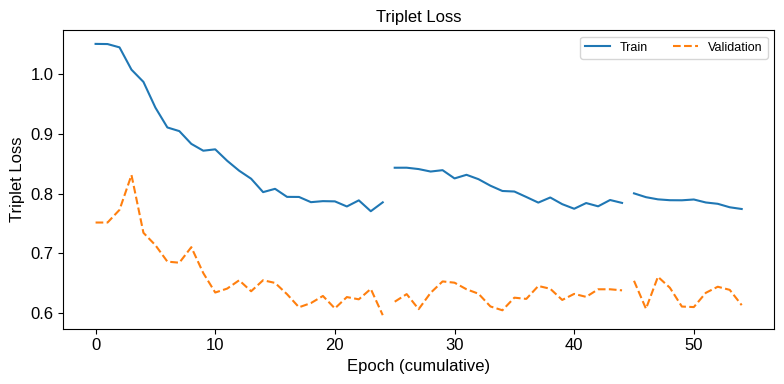

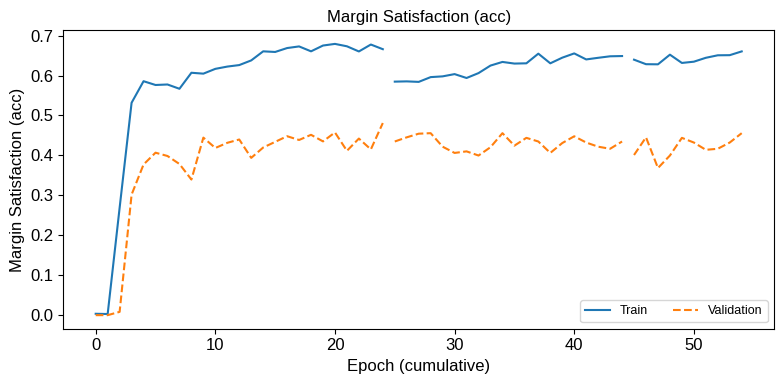

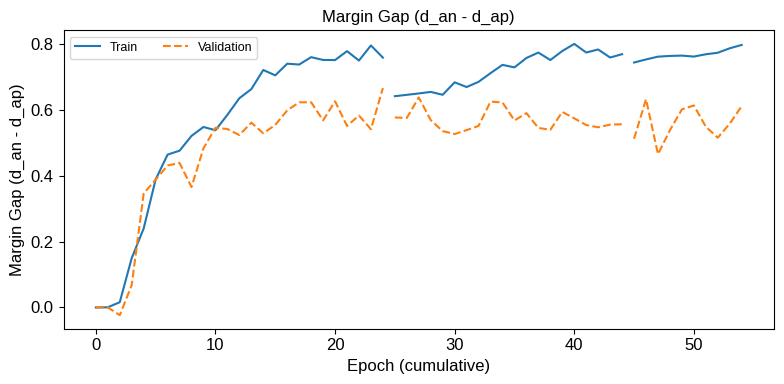

In [ ]:

def plot_total_curves(all_history):
    history, stage_spans = concat_history_with_spans(all_history)
    save_dir = "/content/drive/MyDrive/receptor/result/figures"

    plots = [
        ('train_loss','val_loss','Triplet Loss'),
        ('train_acc','val_acc','Margin Satisfaction (acc)'),
        ('train_gap','val_gap','Margin Gap (d_an - d_ap)'),
    ]

    for ktr, kval, title in plots:
        plt.figure(figsize=(8,4))
        fname = title.lower().replace(" ", "_").replace("(", "").replace(")", "")
        out_path = os.path.join(save_dir, f"{fname}.pdf")

        # === Plotting in stages (disconnected but fixed colors) ===
        for i, (s, e, name) in enumerate(stage_spans):
            x_range = range(s, e + 1)
            plt.plot(x_range, history[ktr][s:e+1], color='C0', lw=1.5)     # Fixed train color
            plt.plot(x_range, history[kval][s:e+1], color='C1', lw=1.5, ls='--')  # Fixed val color

        # === Stage background and annotations ===
        ymin, ymax = plt.ylim()
        ytext = ymax - 0.03*(ymax - ymin)
        '''
        for i, (s, e, name) in enumerate(stage_spans):
            plt.axvspan(s - 0.5, e + 0.5, alpha=0.08 if i % 2 == 0 else 0.15)
            cx = (s + e) / 2
            plt.text(cx, ytext, name, ha='center', va='top', fontsize=9)
            if i < len(stage_spans) - 1:
                plt.axvline(e + 0.5, ls='--', lw=1, color='gray')
        '''

        # === Axis and title ===
        plt.xlabel('Epoch (cumulative)')
        plt.ylabel(title)
        plt.title(title)
        #plt.grid(True, alpha=0.3)

        # Unified legend
        plt.plot([], [], color='C0', label='Train')
        plt.plot([], [], color='C1', ls='--', label='Validation')
        plt.legend(fontsize=9, ncol=2)

        plt.tight_layout()
        plt.savefig(out_path, transparent=True)
        plt.show()

# If you also want to plot the total curve, you can concatenate all_history:
def concat_history(all_history):
    keys = ['train_loss','val_loss','train_acc','val_acc','train_gap','val_gap']
    out = {k: [] for k in keys}
    for stage_name in all_history:
        for k in keys:
            out[k].extend(all_history[stage_name][k])
    return out


# === Call ===
plot_total_curves(all_history)

Load parameters

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
standalone.to(device)
standalone.load_state_dict(torch.load("/content/drive/MyDrive/receptor/models/model_checkpoint.pth", map_location=device))
standalone.eval()  # If it's inference stage, remember to switch to eval mode

Classifier(
  (model_drug): MPNN(
    (W_i): Linear(in_features=50, out_features=128, bias=False)
    (W_h): Linear(in_features=128, out_features=128, bias=False)
    (W_o): Linear(in_features=167, out_features=128, bias=True)
  )
  (model_protein): CNN(
    (conv): ModuleList(
      (0): Conv1d(26, 32, kernel_size=(4,), stride=(1,))
      (1): Conv1d(32, 64, kernel_size=(8,), stride=(1,))
      (2): Conv1d(64, 96, kernel_size=(12,), stride=(1,))
    )
    (fc1): Linear(in_features=96, out_features=256, bias=True)
    (post_convs_act): ModuleList(
      (0-2): 3 x ReLU(inplace=True)
    )
    (post_fc_act): ReLU(inplace=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (predictor): ModuleList(
    (0): Linear(in_features=384, out_features=1024, bias=True)
    (1): Linear(in_features=1024, out_features=1024, bias=True)
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): Linear(in_features=512, out_features=1, bias=Tru

/tmp/ipykernel_914/512629288.py:145: UserWarning: [Dataset] 噪声比例较高：61.4%，请检查 fuzzy_thresh 或聚类特征。
  warnings.warn(f"[Dataset] 噪声比例较高：{noise_ratio:.1%}，请检查 fuzzy_thresh 或聚类特征。")
/tmp/ipykernel_914/512629288.py:145: UserWarning: [Dataset] 噪声比例较高：57.3%，请检查 fuzzy_thresh 或聚类特征。
  warnings.warn(f"[Dataset] 噪声比例较高：{noise_ratio:.1%}，请检查 fuzzy_thresh 或聚类特征。")
/tmp/ipykernel_914/512629288.py:145: UserWarning: [Dataset] 噪声比例较高：59.0%，请检查 fuzzy_thresh 或聚类特征。
  warnings.warn(f"[Dataset] 噪声比例较高：{noise_ratio:.1%}，请检查 fuzzy_thresh 或聚类特征。")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


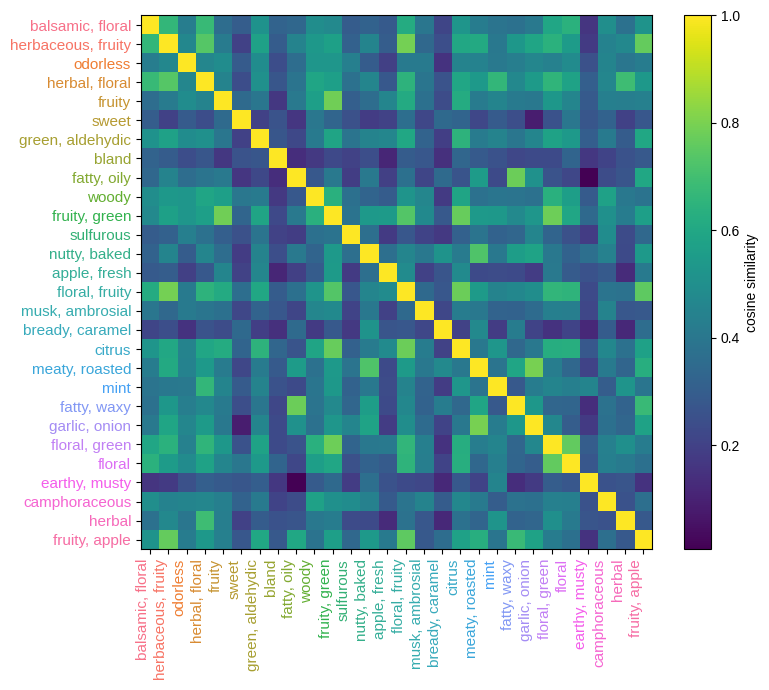

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


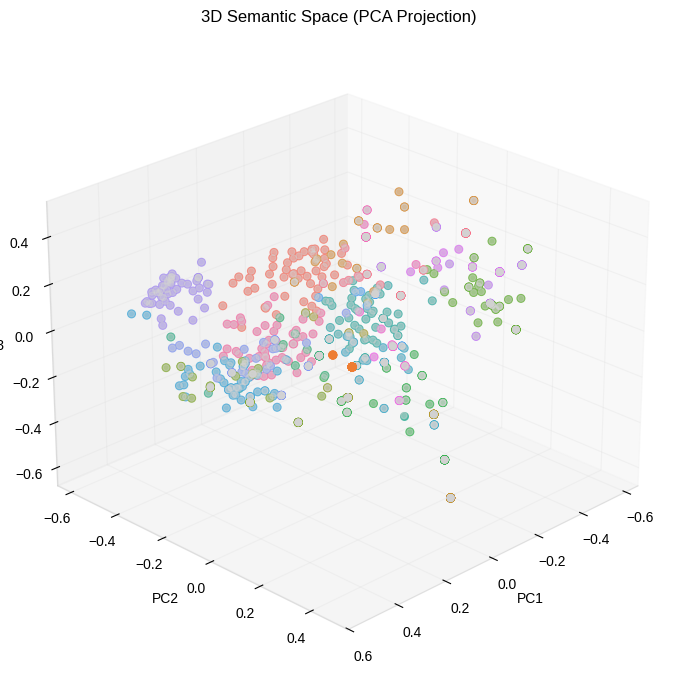

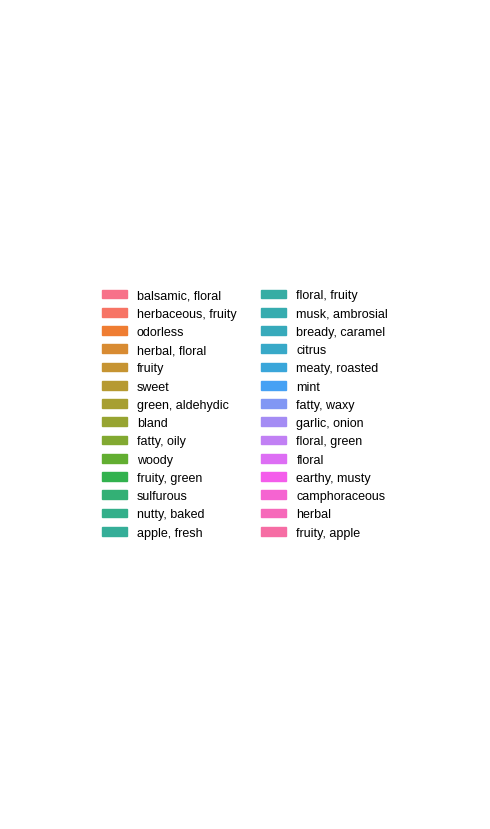

[05:27:27] WARNING: not removing hydrogen atom without neighbors
[05:27:28] WARNING: not removing hydrogen atom without neighbors
[05:27:28] WARNING: not removing hydrogen atom without neighbors
[05:27:29] WARNING: not removing hydrogen atom without neighbors
[05:27:30] WARNING: not removing hydrogen atom without neighbors


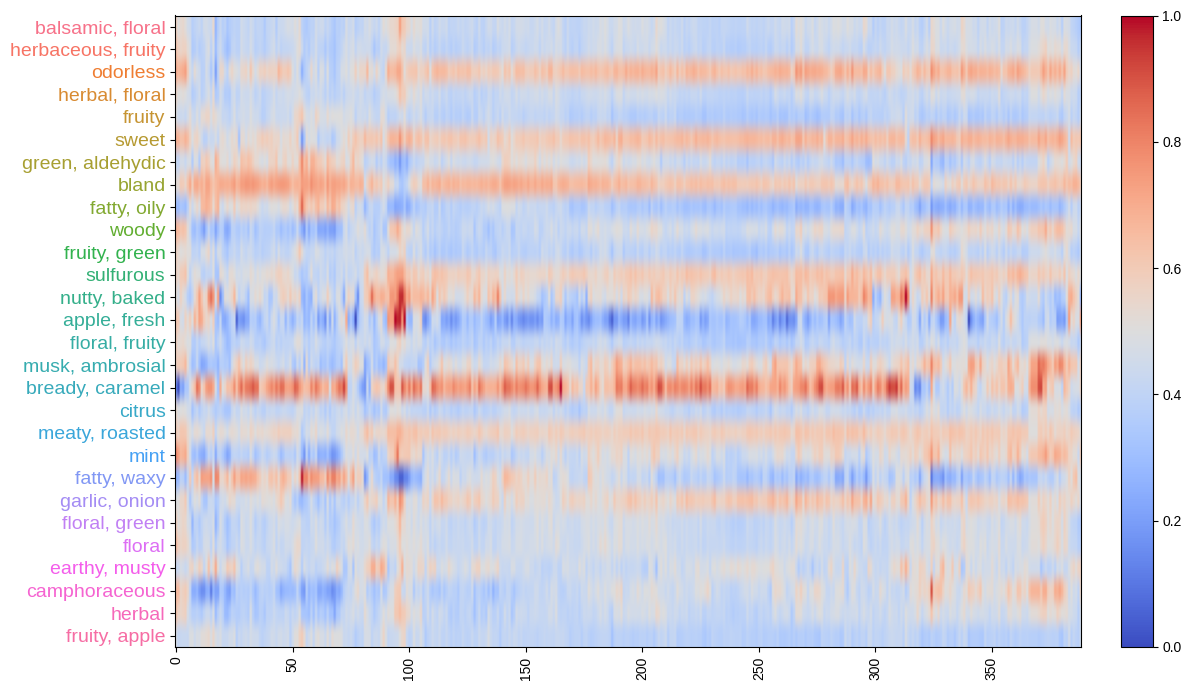

In [ ]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, optimal_leaf_ordering, leaves_list
receptor_df = pd.read_csv("/content/drive/MyDrive/receptor/cleaned_odor_data/cleanedreceptor.csv",header=None )
names = receptor_df.iloc[0].tolist()
seqs = receptor_df.iloc[1].dropna().astype(str).tolist()  # The second row is the sequence
receptor_seqs = seqs

per_sample_mode = "directional"

full_ds="/content/drive/MyDrive/receptor/cleaned_odor_data/merged_smiles.csv"
ds=SmilesTripletClusterDataset(
    full_ds, text_encoder, n_clusters=30,
    cache_path="rowvectest0.pkl", normalize_after_mean=True,
    fuzzy_rule="silhouette", fuzzy_thresh=0.15,  # Or "margin", 0.05; or "gmm", 0.6
    show_progress=False
)

ds_15=SmilesTripletClusterDataset(
    full_ds, text_encoder, n_clusters=15,
    cache_path="rowvectest0.pkl", normalize_after_mean=True,
    fuzzy_rule="silhouette", fuzzy_thresh=0.15,  # Or "margin", 0.05; or "gmm", 0.6
    show_progress=False
)
ds_50=SmilesTripletClusterDataset(
    full_ds, text_encoder, n_clusters=50,
    cache_path="rowvectest0.pkl", normalize_after_mean=True,
    fuzzy_rule="silhouette", fuzzy_thresh=0.15,  # Or "margin", 0.05; or "gmm", 0.6
    show_progress=False
)
reps = ds.get_cluster_topn_representatives(topn=50)
#print(reps)
# reps[cluster_id]["descriptors"] is the natural language label list before embedding

result = visualize_topn_reps_v2(
    reps,
    max_desc_per_sample=20,
    show_wordclouds=False,
    show_scatter=False,
    show_heatmap=True,
    maxword=2,
    #save_dir="/content/drive/MyDrive/receptor/result/figures", save_prefix="label_"
    #save_dir="/content/drive/MyDrive/receptor/result/figures/SI", save_prefix="label_50_"
)

# --- Define: Single-sample normalization (in log space) ---
def normalize_panel(panel: torch.Tensor, mode: str = "zscore", eps: float = 1e-8) -> torch.Tensor:
    """
    panel: (R,) Receptor panel for a single sample (log space scores)
    mode:  "zscore" | "mad" | "center" | "center-median"
      - zscore: (x - mean)/std
      - mad:    (x - median)/MAD            # More robust to outliers
      - center: x - mean
      - center-median: x - median
    """
    if mode == "zscore":
        mu  = panel.mean()
        std = panel.std().clamp_min(eps)
        return (panel - mu) / std
    elif mode == "mad":
        med = panel.median()
        mad = (panel - med).abs().median().values
        return (panel - med) / mad.clamp_min(eps)
    elif mode == "center":
        mu  = panel.mean()
        return panel - mu
    elif mode == "center-median":
        med = panel.median()
        return panel - med
    elif mode == "minmax":
        x_min = panel.min()
        x_max = panel.max()
        scale = (x_max - x_min).clamp_min(eps)
        return (panel - x_min) / scale

    elif mode == "directional":
        scale = (0.0, 1.0)
        # --- Step 1: Mean centering ---
        #centered = panel - panel.mean()
        centered = panel - panel.median()
        # --- Step 2: Unit normalization (if all are equal length, then norm≈0) ---
        norm = centered.norm(p=2).clamp_min(eps)
        unit = centered / norm
        # --- Step 3: Min-max scaling to target range [a,b] ---
        x_min, x_max = unit.min(), unit.max()
        denom = (x_max - x_min).clamp_min(eps)
        scaled = (unit - x_min) / denom



        a, b = scale
        return a + scaled * (b - a)


    else:
        raise ValueError("mode must be one of: 'zscore','mad','center','center-median'")



# ========== Helper functions ==========
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
standalone.to(device).eval()   # Validation phase: eval disables dropout

def protein_chars_to_cnn_tensor(chars):
    # Output of trans_protein(seq) (length=1000, including '?')
    oh_LC = enc_protein.transform(np.array(chars).reshape(-1, 1)).toarray()  # (L, 26)
    return torch.tensor(oh_LC.T.astype(np.float32))  # (26, L)

@torch.no_grad()
def build_receptor_bank(model, receptor_seqs, device):
    """Encodes 389 receptor sequences into a (389, 256) protein representation bank."""
    bank = []
    for seq in receptor_seqs:
        chars = trans_protein(seq)
        x = protein_chars_to_cnn_tensor(chars).unsqueeze(0).to(device) # (1,26,L)
        hp = model.model_protein(x)  # (1,256)
        bank.append(hp.squeeze(0))
    return torch.stack(bank, dim=0)  # (389,256)

@torch.no_grad()
def encode_smiles_hd(model, smiles, device):
    """Encodes SMILES into a drug representation h_d: (128,) (DP's MPNN forward)."""
    f_atoms, f_bonds, agraph, bgraph, shape = smiles2mpnnfeature(smiles)
    feat = (
        f_atoms.unsqueeze(0).to(device),       # (1, MAX_ATOM, 39)
        f_bonds.unsqueeze(0).to(device),       # (1, MAX_BOND, 50)
        agraph.unsqueeze(0).long().to(device), # (1, MAX_ATOM, 6)
        bgraph.unsqueeze(0).long().to(device), # (1, MAX_BOND, 6)
        shape.to(device)                       # (1, 2)
    )
    hd = model.model_drug(feat)  # (1,128)
    return hd.squeeze(0)         # (128,)

@torch.no_grad()
def predictor_head(model, x):
    """x: (M,384) -> (M,) Layer-by-layer forward (consistent with training, but no dropout in eval)."""
    y = x
    for i, layer in enumerate(model.predictor):
        y = layer(y)
        if i < len(model.predictor) - 1:
            y = torch.relu(y)
    return y.squeeze(-1)

@torch.no_grad()
def predict_panel_vector(model, h_d, receptor_bank):
    """Given a molecule's h_d and receptor_bank(389,256), returns the molecule's 389-dimensional panel vector."""
    n = receptor_bank.size(0)  # 389
    x = torch.cat([h_d.unsqueeze(0).expand(n, -1), receptor_bank], dim=1)  # (n,128+256=384)
    return predictor_head(model, x)  # (n,)

# ========== 1) Prepare receptor bank ==========
receptor_bank = build_receptor_bank(standalone, receptor_seqs, device)  # (389,256)

# ========== 2) Iterate through dataset, aggregate by class ==========
labels = np.asarray(ds.labels, dtype=np.int32)  # Class labels for each sample (-1 for noise/fuzzy)
smiles_list = list(ds.df["SMILES"])

include_noise = False  # Whether to include samples with label = -1
if not include_noise:
    valid_idx = np.where(labels != -1)[0]
else:
    valid_idx = np.arange(len(labels))

# Count class IDs (excluding -1)
class_ids = sorted(set(int(l) for l in labels if (include_noise or l != -1)))

# Accumulate sums and counts for each class
sum_by_class = {c: torch.zeros(receptor_bank.size(0), device=device) for c in class_ids}
cnt_by_class = {c: 0 for c in class_ids}

with torch.no_grad():
    for i in valid_idx:
        c = int(labels[i])
        if (not include_noise) and c == -1:
            continue
        smi = smiles_list[i]
        try:
            hd = encode_smiles_hd(standalone, smi, device)           # (128,)
            panel = predict_panel_vector(standalone, hd, receptor_bank)  # (389,)
            panel = normalize_panel(panel, mode=per_sample_mode)
            sum_by_class[c] += panel
            cnt_by_class[c] += 1
        except Exception as e:
            # Individual failed samples can be skipped
            print(f"[warn] sample #{i} failed: {e}")

# ========== 3) Calculate average activation profile matrix for each class ==========
# Rows: classes; Columns: receptors (389)
avg_panels = []
kept_classes = []
for c in class_ids:
    if cnt_by_class[c] > 0:
        avg_panels.append( (sum_by_class[c] / cnt_by_class[c]).unsqueeze(0) )
        kept_classes.append(c)

if len(avg_panels) == 0:
    raise RuntimeError("No available samples for visualization (possibly all noise or encoding failed).")

avg_mat = torch.cat(avg_panels, dim=0).cpu().numpy()  # (n_classes, 389)

eps = 1e-8
row_mean = avg_mat.mean(axis=1, keepdims=True)
row_std  = avg_mat.std(axis=1, keepdims=True) + eps
avg_mat_norm = (avg_mat - row_mean) / row_std

# ---- Receptor column reordering: Hierarchical clustering + optimal leaf ordering ----
# We measure similarity between receptors based on "class average spectra" (avg_mat_norm, where rows are z-scored).
# Data matrix: X = Receptors × Classes
X = avg_mat.T  # shape: (n_receptors, n_classes)



# Similarity metric: "correlation" (equivalent to 1 - Pearson correlation), or "cosine" is recommended.
metric = "correlation"  # Can be changed to "cosine"
D = pdist(X, metric=metric)                  # Distance vector for all receptor pairs
Z = linkage(D, method="average")             # Hierarchical clustering (average/ward/complete are all acceptable)
Z_opt = optimal_leaf_ordering(Z, D)          # Optimal leaf ordering: Makes adjacent leaves more similar
order = leaves_list(Z_opt)                   # Column reordering index, shape: (n_receptors,)


# Apply reordering
avg_mat_reordered = avg_mat[:, order]


# ========== 4) Heatmap visualization ==========

plt.figure(figsize=(12, max(4, 0.25 * len(kept_classes))))
ax = plt.gca()

# Plot heatmap (already reordered)
im = ax.imshow(avg_mat_reordered, aspect='auto', cmap="coolwarm")

# ✅ Get labels and color mapping for each class from visualize_topn_reps_v2
label_color_map = {c['id']: (c['label'], c['color']) for c in result["cluster_label_colors"]}

# ✅ Generate row labels (prioritizing classes present in kept_classes)
yticklabels = []
ytickcolors = []
for c in kept_classes:
    if c in label_color_map:
        lab, col = label_color_map[c]
        yticklabels.append(lab)
        ytickcolors.append(col)
    else:
        yticklabels.append(f"Class {c}")
        ytickcolors.append((0, 0, 0))  # Default black

# ✅ Set y-axis labels
ax.set_yticks(np.arange(len(kept_classes)))
ax.set_yticklabels(yticklabels, fontsize=14)

# ✅ Color each ytick label
for ticklabel, color in zip(ax.get_yticklabels(), ytickcolors):
    ticklabel.set_color(color)

# ✅ Set x-axis labels (receptor index)
nR = avg_mat.shape[1]
step = 50 if nR > 200 else 20
xticks = np.arange(0, nR, step)
ax.set_xticks(xticks)
ax.set_xticklabels([str(j) for j in xticks], rotation=90)

# Axes and title
#ax.set_xlabel("Receptor index (0..{})".format(nR - 1))
#ax.set_ylabel("Cluster / Class (Representative Label)")
#ax.set_title("Per-class Mean Activation Spectra (After Fine-tuning)".format(nR))

# Color bar
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/receptor/result/figures/receptormap_30.pdf", transparent=True)
#plt.savefig("/content/drive/MyDrive/receptor/result/figures/SI/receptormap_50.pdf", transparent=True)
#plt.savefig("/content/drive/MyDrive/receptor/result/figures/SI/receptormap_15.pdf", transparent=True)
plt.show()

Evaluate usability

[06:47:27] WARNING: not removing hydrogen atom without neighbors
[06:47:28] WARNING: not removing hydrogen atom without neighbors
[06:47:28] WARNING: not removing hydrogen atom without neighbors
[06:47:29] WARNING: not removing hydrogen atom without neighbors
[06:47:30] WARNING: not removing hydrogen atom without neighbors


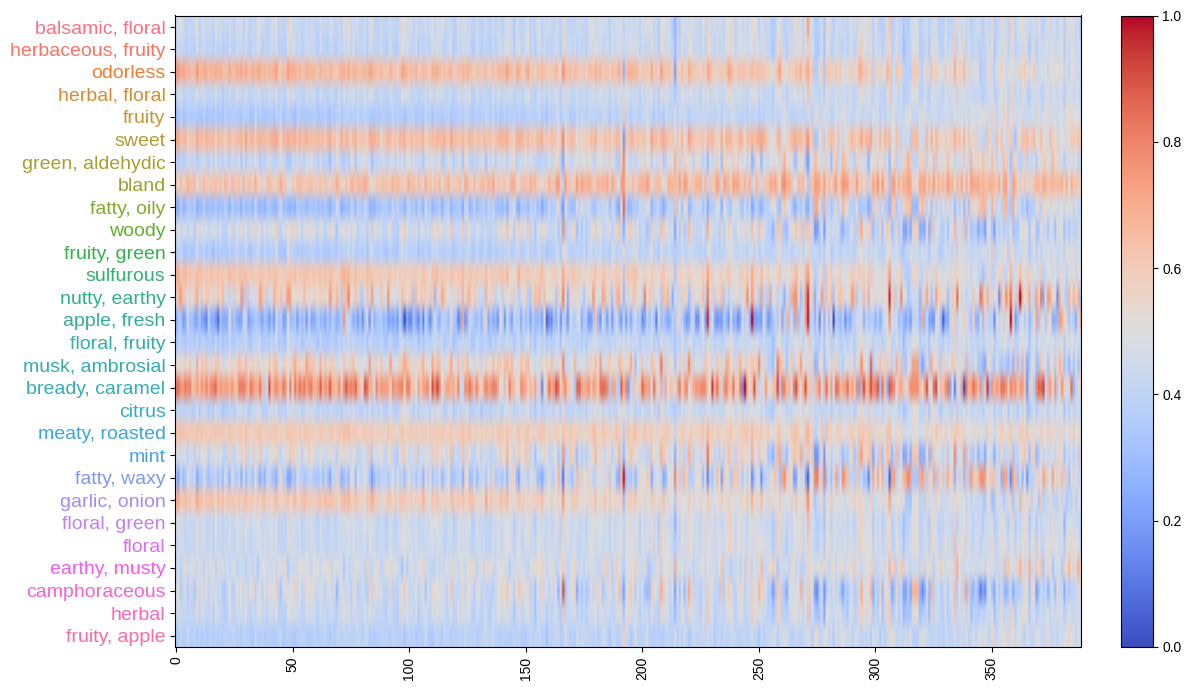

In [ ]:
# ========== 1) Prepare receptor bank ==========
receptor_bank = build_receptor_bank(standalone, receptor_seqs, device)  # (389,256)

# ========== 2) Clustering the Dataset ==========
labels = np.asarray(ds.labels, dtype=np.int32)
smiles_list = list(ds.df["SMILES"])

include_noise = False
valid_idx = np.where(labels != -1)[0] if not include_noise else np.arange(len(labels))

class_ids = sorted(set(int(l) for l in labels if (include_noise or l != -1)))

sum_by_class   = {c: torch.zeros(receptor_bank.size(0), device=device) for c in class_ids}
sumsq_by_class = {c: torch.zeros(receptor_bank.size(0), device=device) for c in class_ids}  # NEW
cnt_by_class   = {c: 0 for c in class_ids}

with torch.no_grad():
    for i in valid_idx:
        c = int(labels[i])
        if (not include_noise) and c == -1:
            continue
        smi = smiles_list[i]
        try:
            hd    = encode_smiles_hd(standalone, smi, device)             # (128,)
            panel = predict_panel_vector(standalone, hd, receptor_bank)   # (389,)
            panel = normalize_panel(panel, mode=per_sample_mode)          #
            sum_by_class[c]   += panel
            sumsq_by_class[c] += panel * panel                            # NEW
            cnt_by_class[c]   += 1
        except Exception as e:
            print(f"[warn] sample #{i} failed: {e}")

# ========== 3) Calculate mean matrix and intra-class variance matrix per cluster ==========
avg_panels = []
var_panels = []   # NEW: Intra-class variance per cluster x per receptor
kept_classes = []
eps = 1e-8

for c in class_ids:
    n = cnt_by_class[c]
    if n > 0:
        mu = (sum_by_class[c] / n)                     # (R,)
        # Unbiased intra-class variance: Var = (Σx^2 - n*mu^2) / (n-1)
        if n > 1:
            var = (sumsq_by_class[c] - n * mu * mu).clamp_min(0.0) / (n - 1)
        else:
            var = torch.zeros_like(mu)                 # if n=1, set var= 0
        avg_panels.append(mu.unsqueeze(0))             # (1,R)
        var_panels.append(var.unsqueeze(0))            # NEW
        kept_classes.append(c)

if len(avg_panels) == 0:
    raise RuntimeError("No samples")

avg_mat = torch.cat(avg_panels, dim=0).cpu().numpy()   # (C_kept, R)
var_mat = torch.cat(var_panels, dim=0).cpu().numpy()   # NEW: (C_kept, R)
n_vec   = np.array([cnt_by_class[c] for c in kept_classes], dtype=float)  # (C_kept,)
N_tot   = float(np.sum(n_vec)) + eps

#
row_mean = avg_mat.mean(axis=1, keepdims=True)
row_std  = avg_mat.std(axis=1, keepdims=True) + eps
avg_mat_norm = (avg_mat - row_mean) / row_std

# ========== 4) Ranking by Fisher Score ==========
# Fisher_r = [Σ_c n_c (μ_{c,r} - μ_{·,r})^2] / [Σ_c (n_c - 1) σ^2_{c,r} + ε]
mu_global = (n_vec[:, None] * avg_mat).sum(axis=0, keepdims=True) / N_tot        # (1,R)
num = (n_vec[:, None] * (avg_mat - mu_global)**2).sum(axis=0)                    # (R,)
den = ((np.maximum(n_vec - 1.0, 0.0))[:, None] * var_mat).sum(axis=0) + eps      # (R,)
fisher_scores = num / den                                                        # (R,)

order = np.argsort(-fisher_scores)

# Apply re-rank
avg_mat_reordered = avg_mat[:, order]



plt.figure(figsize=(12, max(4, 0.25 * len(kept_classes))))
ax = plt.gca()
im = ax.imshow(avg_mat_reordered, aspect='auto', cmap="coolwarm")


label_color_map = {c['id']: (c['label'], c['color']) for c in result["cluster_label_colors"]}

yticklabels, ytickcolors = [], []
for c in kept_classes:
    if c in label_color_map:
        lab, col = label_color_map[c]
        yticklabels.append(lab); ytickcolors.append(col)
    else:
        yticklabels.append(f"Class {c}"); ytickcolors.append((0, 0, 0))

ax.set_yticks(np.arange(len(kept_classes)))
ax.set_yticklabels(yticklabels, fontsize=14)
for ticklabel, color in zip(ax.get_yticklabels(), ytickcolors):
    ticklabel.set_color(color)

nR = avg_mat.shape[1]
step = 50 if nR > 200 else 20
xticks = np.arange(0, nR, step)
ax.set_xticks(xticks)
ax.set_xticklabels([str(j) for j in xticks], rotation=90)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/receptor/result/figures/receptormap_30_reorganizedbyFisher.pdf", transparent=True)
plt.show()

Matrix Similarity Evaluation

In [ ]:
import numpy as np
import torch

from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize

# ------------------------------------------------------------
# User setting: representatives
# ------------------------------------------------------------
reps = ds.get_cluster_topn_representatives(topn=1500)


# ---------------------------
# A) collect samples from reps
# ---------------------------
def collect_from_reps_only(reps, exclude_noise=True):
    """
    reps: {cluster_id: [ {"smiles": ..., ...}, ... ], ...}
    return:
      smiles_list: List[str]
      y: np.ndarray (N,) with labels = cluster_id
    """
    smiles_list, y_list = [], []
    for c, items in reps.items():
        c = int(c)
        if exclude_noise and c == -1:
            continue
        for it in items:
            smi = it.get("smiles", "")
            if smi is None:
                continue
            smi = str(smi).strip()
            if smi == "":
                continue
            smiles_list.append(smi)
            y_list.append(c)
    return smiles_list, np.asarray(y_list, dtype=np.int32)


# ---------------------------
# B) predict panels
# ---------------------------
@torch.no_grad()
def predict_panels_for_smiles(
    model,
    receptor_bank,
    smiles_list,
    device,
    per_sample_mode="l2",
    verbose_every=200
):
    """
    Return:
      X_ok: np.ndarray (N_ok, n_receptors)
      ok:   np.ndarray (N,) bool mask aligned with smiles_list
    """
    X = []
    ok = np.zeros(len(smiles_list), dtype=bool)

    for i, smi in enumerate(smiles_list):
        try:
            hd = encode_smiles_hd(model, smi, device)                   # (128,)
            panel = predict_panel_vector(model, hd, receptor_bank)      # (389,)
            panel = normalize_panel(panel, mode=per_sample_mode)        # (389,)
            X.append(panel.detach().float().cpu().numpy())
            ok[i] = True
        except Exception as e:
            X.append(None)
            if verbose_every and (i % verbose_every == 0):
                print(f"[warn] predict failed at #{i}: {e}")

    X_ok = np.stack([x for x in X if x is not None], axis=0) if np.any(ok) else np.zeros((0, receptor_bank.size(0)))
    return X_ok, ok


# ---------------------------
# C) Pearson geometry helpers (Pearson ~ cosine on mean-centered vectors)
# ---------------------------
def pearson_preprocess(X, eps=1e-8):
    """
    Make cosine(Xc, Yc) == Pearson(x, y) approximately,
    where Xc is per-sample mean-centered and L2-normalized.
    """
    X = np.asarray(X, dtype=float)
    Xc = X - X.mean(axis=1, keepdims=True)
    Xc = normalize(Xc, norm="l2")
    return Xc


# ---------------------------
# D) consistent filtering + metrics (fixed n_splits)
# ---------------------------
def filter_for_silhouette_and_knn(X, y):
    """
    Unified filtering:
      1) keep classes with >=2 samples (silhouette requires it)
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    uniq, cnt = np.unique(y, return_counts=True)
    keep_classes = set(uniq[cnt >= 2].tolist())
    keep = np.array([lab in keep_classes for lab in y], dtype=bool)

    Xk, yk = X[keep], y[keep]
    if len(np.unique(yk)) < 2:
        raise ValueError("Need at least 2 classes with >=2 samples each after filtering.")

    return Xk, yk


def compute_silhouette_knn(
    X,
    y,
    k=10,
    cv_splits=5,
    seed=42,
    metric="pearson",
    max_splits=10
):
    """
    metric: 'pearson' (implemented via mean-centering + cosine)
    Fix n_splits issue by setting n_splits = min(cv_splits, min_class_count),
    and requiring n_splits >= 2.
    """
    Xk, yk = filter_for_silhouette_and_knn(X, y)

    # Pearson distance = 1 - Pearson corr
    # Implemented as cosine distance on per-sample mean-centered vectors.
    if metric.lower() == "pearson":
        Xk = pearson_preprocess(Xk)
        metric_eff = "cosine"
    elif metric.lower() == "cosine":
        Xk = normalize(Xk, norm="l2")
        metric_eff = "cosine"
    else:
        metric_eff = metric  # for euclidean etc.

    # silhouette
    sil = silhouette_score(Xk, yk, metric=metric_eff)

    # fix n_splits based on min class count
    _, cnt = np.unique(yk, return_counts=True)
    min_count = int(cnt.min())
    n_splits = min(int(cv_splits), int(max_splits), min_count)
    if n_splits < 2:
        raise ValueError(f"Not enough samples per class for CV: min_class_count={min_count}")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    clf = KNeighborsClassifier(n_neighbors=int(k), metric=metric_eff)
    acc = cross_val_score(clf, Xk, yk, cv=skf, scoring="accuracy")

    return float(sil), float(acc.mean()), float(acc.std()), int(Xk.shape[0]), int(len(np.unique(yk))), int(n_splits), int(min_count)


# ---------------------------
# E) end-to-end compare (standalone vs model_ctrl)
# ---------------------------
def compare_two_models_on_reps(
    reps,
    standalone,
    model_ctrl,
    receptor_bank,
    device,
    per_sample_mode="l2",
    metric="pearson",
    k=10,
    cv_splits=5,
    seed=42,
):
    smiles_list, y = collect_from_reps_only(reps, exclude_noise=True)
    print(f"[info] reps samples: {len(smiles_list)} | classes: {len(np.unique(y))}")

    # first pass: find intersection of successful predictions
    _, ok_s = predict_panels_for_smiles(standalone, receptor_bank, smiles_list, device, per_sample_mode=per_sample_mode)
    _, ok_c = predict_panels_for_smiles(model_ctrl, receptor_bank, smiles_list, device, per_sample_mode=per_sample_mode)

    ok_both = ok_s & ok_c
    print(f"[info] success standalone: {ok_s.sum()}/{len(ok_s)} | ctrl: {ok_c.sum()}/{len(ok_c)} | both: {ok_both.sum()}")

    idx_keep = np.where(ok_both)[0]
    smiles_keep = [smiles_list[i] for i in idx_keep]
    y_keep = y[idx_keep]

    # second pass: predict aligned X for both models on the exact same sample list
    X_s, ok_s2 = predict_panels_for_smiles(standalone, receptor_bank, smiles_keep, device, per_sample_mode=per_sample_mode)
    X_c, ok_c2 = predict_panels_for_smiles(model_ctrl, receptor_bank, smiles_keep, device, per_sample_mode=per_sample_mode)

    ok_final = ok_s2 & ok_c2
    if ok_final.sum() < len(smiles_keep):
        # align again if needed
        print(f"[warn] final aligned samples reduced to {ok_final.sum()}/{len(smiles_keep)}")
        # rebuild X by re-running on the surviving subset (simple & safe)
        idx2 = np.where(ok_final)[0]
        smiles_keep2 = [smiles_keep[i] for i in idx2]
        y_keep = y_keep[idx2]
        X_s, _ = predict_panels_for_smiles(standalone, receptor_bank, smiles_keep2, device, per_sample_mode=per_sample_mode)
        X_c, _ = predict_panels_for_smiles(model_ctrl, receptor_bank, smiles_keep2, device, per_sample_mode=per_sample_mode)

    sil_s, acc_s, std_s, n_s, c_s, nsplit_s, minc_s = compute_silhouette_knn(
        X_s, y_keep, k=k, cv_splits=cv_splits, seed=seed, metric=metric
    )
    sil_c, acc_c, std_c, n_c, c_c, nsplit_c, minc_c = compute_silhouette_knn(
        X_c, y_keep, k=k, cv_splits=cv_splits, seed=seed, metric=metric
    )

    # these should match if filtering is consistent
    assert n_s == n_c and c_s == c_c, "Filtered sample size/classes mismatch—check filtering logic."

    out = {
        "N_used": n_s,
        "n_classes": c_s,
        "cv_n_splits": nsplit_s,
        "min_class_count": minc_s,
        "silhouette": {"standalone": sil_s, "ctrl": sil_c, "delta": sil_s - sil_c},
        "knn_acc": {
            "standalone": acc_s, "ctrl": acc_c, "delta": acc_s - acc_c,
            "standalone_std": std_s, "ctrl_std": std_c
        },
        "X_standalone": X_s,
        "X_ctrl": X_c,
        "y": y_keep
    }
    return out


# ==========================
# Run comparison
# ==========================
# receptor_bank = build_receptor_bank(standalone, receptor_seqs, device)

res = compare_two_models_on_reps(
    reps=reps,
    standalone=standalone,
    model_ctrl=model_ctl,              # your ctrl model variable
    receptor_bank=receptor_bank,
    device=device,
    per_sample_mode=per_sample_mode,
    metric="pearson",
    k=10,
    cv_splits=5,
    seed=42,
)

print(f"\n[RESULT] N_used={res['N_used']} | n_classes={res['n_classes']} | "
      f"CV n_splits={res['cv_n_splits']} (min_class_count={res['min_class_count']})")

print(f"Silhouette (Pearson geometry): standalone={res['silhouette']['standalone']:.4f} | "
      f"ctrl={res['silhouette']['ctrl']:.4f} | Δ={res['silhouette']['delta']:.4f}")

print(f"kNN acc (k={10}, Pearson geometry): standalone={res['knn_acc']['standalone']:.4f}±{res['knn_acc']['standalone_std']:.4f} | "
      f"ctrl={res['knn_acc']['ctrl']:.4f}±{res['knn_acc']['ctrl_std']:.4f} | Δ={res['knn_acc']['delta']:.4f}")


# ---------------------------
# F) paired permutation test for Δ (labels permuted)
# ---------------------------
def paired_perm_test_delta_sil_knn(
    Xa, Xb, y,
    metric="pearson",
    k=10,
    cv_splits=5,
    seed=0,
    n_perm=1000
):
    """
    Xa: standalone embeddings (N,D)
    Xb: ctrl embeddings (N,D)
    y: labels (N,)
    Null: label assignment is unrelated.
    We compute Δ = score(Xa,y) - score(Xb,y); permute y to form null.
    """
    rng = np.random.default_rng(seed)

    sil_a, acc_a, _, _, _, _, _ = compute_silhouette_knn(Xa, y, k=k, cv_splits=cv_splits, seed=seed, metric=metric)
    sil_b, acc_b, _, _, _, _, _ = compute_silhouette_knn(Xb, y, k=k, cv_splits=cv_splits, seed=seed, metric=metric)
    delta_sil_obs = sil_a - sil_b
    delta_acc_obs = acc_a - acc_b

    null_sil = np.zeros(n_perm, dtype=float)
    null_acc = np.zeros(n_perm, dtype=float)

    for i in range(n_perm):
        yp = rng.permutation(y)
        sil_a_p, acc_a_p, _, _, _, _, _ = compute_silhouette_knn(Xa, yp, k=k, cv_splits=cv_splits, seed=seed, metric=metric)
        sil_b_p, acc_b_p, _, _, _, _, _ = compute_silhouette_knn(Xb, yp, k=k, cv_splits=cv_splits, seed=seed, metric=metric)
        null_sil[i] = sil_a_p - sil_b_p
        null_acc[i] = acc_a_p - acc_b_p

    p_sil = (np.sum(np.abs(null_sil) >= abs(delta_sil_obs)) + 1) / (n_perm + 1)
    p_acc = (np.sum(np.abs(null_acc) >= abs(delta_acc_obs)) + 1) / (n_perm + 1)

    return {
        "delta_sil_obs": float(delta_sil_obs),
        "delta_acc_obs": float(delta_acc_obs),
        "p_sil": float(p_sil),
        "p_acc": float(p_acc),
        "null_sil": null_sil,
        "null_acc": null_acc,
    }


perm_res = paired_perm_test_delta_sil_knn(
    res["X_standalone"], res["X_ctrl"], res["y"],
    metric="pearson", k=10, cv_splits=5, seed=42, n_perm=100
)
print(f"\n[PAIRED PERM] ΔSilhouette={perm_res['delta_sil_obs']:.4f} | p={perm_res['p_sil']:.4g}")
print(f"[PAIRED PERM] ΔkNNacc   ={perm_res['delta_acc_obs']:.4f} | p={perm_res['p_acc']:.4g}")


[info] reps samples: 3325 | classes: 28


[10:03:18] WARNING: not removing hydrogen atom without neighbors
[10:03:18] WARNING: not removing hydrogen atom without neighbors
[10:03:18] WARNING: not removing hydrogen atom without neighbors
[10:03:18] WARNING: not removing hydrogen atom without neighbors
[10:03:18] WARNING: not removing hydrogen atom without neighbors
[10:03:30] WARNING: not removing hydrogen atom without neighbors
[10:03:30] WARNING: not removing hydrogen atom without neighbors
[10:03:30] WARNING: not removing hydrogen atom without neighbors
[10:03:31] WARNING: not removing hydrogen atom without neighbors
[10:03:31] WARNING: not removing hydrogen atom without neighbors


[info] success standalone: 3325/3325 | ctrl: 3325/3325 | both: 3325


[10:03:42] WARNING: not removing hydrogen atom without neighbors
[10:03:42] WARNING: not removing hydrogen atom without neighbors
[10:03:42] WARNING: not removing hydrogen atom without neighbors
[10:03:43] WARNING: not removing hydrogen atom without neighbors
[10:03:43] WARNING: not removing hydrogen atom without neighbors
[10:03:54] WARNING: not removing hydrogen atom without neighbors
[10:03:55] WARNING: not removing hydrogen atom without neighbors
[10:03:55] WARNING: not removing hydrogen atom without neighbors
[10:03:55] WARNING: not removing hydrogen atom without neighbors
[10:03:55] WARNING: not removing hydrogen atom without neighbors



[RESULT] N_used=3323 | n_classes=26 | CV n_splits=2 (min_class_count=2)
Silhouette (Pearson geometry): standalone=-0.2170 | ctrl=-0.2954 | Δ=0.0783
kNN acc (k=10, Pearson geometry): standalone=0.5248±0.0083 | ctrl=0.4565±0.0095 | Δ=0.0683

[PAIRED PERM] ΔSilhouette=0.0783 | p=0.2772
[PAIRED PERM] ΔkNNacc   =0.0683 | p=0.009901


In [ ]:
import numpy as np
import torch

# ============================================================
# 0) Basic utilities
# ============================================================

def pearson_preprocess(X, eps=1e-8):
    """
    Pearson geometry:
      - mean-center each row
      - L2-normalize the centered row
    This is required to make Pearson correlation equivalent to dot-product similarity.
    """
    X = np.asarray(X, dtype=np.float32)
    Xc = X - X.mean(axis=1, keepdims=True)
    denom = np.sqrt((Xc * Xc).sum(axis=1, keepdims=True)) + eps
    return Xc / denom


def filter_min_class_count(X, y, min_count=2):
    """
    Single-matrix version:
    Keep only classes that have >= min_count samples.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    uniq, cnt = np.unique(y, return_counts=True)
    keep_classes = set(uniq[cnt >= min_count].tolist())
    keep = np.array([lab in keep_classes for lab in y], dtype=bool)

    Xk, yk = X[keep], y[keep]
    if len(np.unique(yk)) < 2:
        raise ValueError("Need at least 2 classes after filtering.")
    return Xk, yk


def filter_min_class_count_pair(Xa, Xb, y, min_count=2):
    """
    Paired-matrix version:
    Apply the SAME class filter to Xa and Xb.
    """
    Xa = np.asarray(Xa)
    Xb = np.asarray(Xb)
    y  = np.asarray(y)

    uniq, cnt = np.unique(y, return_counts=True)
    keep_classes = set(uniq[cnt >= min_count].tolist())
    keep = np.array([lab in keep_classes for lab in y], dtype=bool)

    Xa2, Xb2, y2 = Xa[keep], Xb[keep], y[keep]
    if len(np.unique(y2)) < 2:
        raise ValueError("Need at least 2 classes after filtering.")
    return Xa2, Xb2, y2


# ============================================================
# 1) Collect samples from reps
# ============================================================

def collect_from_reps_only(reps, exclude_noise=True):
    smiles_list, y_list = [], []
    for c, items in reps.items():
        c = int(c)
        if exclude_noise and c == -1:
            continue
        for it in items:
            smi = it.get("smiles", "")
            if smi is None:
                continue
            smi = str(smi).strip()
            if smi == "":
                continue
            smiles_list.append(smi)
            y_list.append(c)
    return smiles_list, np.asarray(y_list, dtype=np.int32)


# ============================================================
# 2) Predict panels for smiles
# ============================================================

@torch.no_grad()
def predict_panels_for_smiles(
    model,
    receptor_bank,
    smiles_list,
    device,
    per_sample_mode="l2",
    verbose_every=200
):
    """
    Returns:
      X_ok: (N_ok, n_receptors)
      ok:   (N,) boolean mask aligned with smiles_list
    """
    X = []
    ok = np.zeros(len(smiles_list), dtype=bool)

    for i, smi in enumerate(smiles_list):
        try:
            hd = encode_smiles_hd(model, smi, device)                   # (128,)
            panel = predict_panel_vector(model, hd, receptor_bank)      # (nR,)
            panel = normalize_panel(panel, mode=per_sample_mode)        # (nR,)
            X.append(panel.detach().float().cpu().numpy())
            ok[i] = True
        except Exception as e:
            X.append(None)
            if verbose_every and (i % verbose_every == 0):
                print(f"[warn] predict failed at #{i}: {e}")

    nR = int(receptor_bank.size(0))
    X_ok = np.stack([x for x in X if x is not None], axis=0) if np.any(ok) else np.zeros((0, nR), dtype=np.float32)
    return X_ok.astype(np.float32), ok


# ============================================================
# 3) GAP metric (pair sampling) helpers
# ============================================================

def precompute_gap_pairs(Xp, n_pairs=200000, seed=42):
    """
    Sample index pairs (i,j), i!=j.
    """
    rng = np.random.default_rng(seed)
    n = Xp.shape[0]
    i = rng.integers(0, n, size=n_pairs, dtype=np.int32)
    j = rng.integers(0, n, size=n_pairs, dtype=np.int32)
    mask = (i != j)
    return i[mask], j[mask]


def pairwise_pearson_distance_from_preprocessed(Xp, i, j):
    """
    Xp is pearson_preprocess(X), so dot(Xp[i],Xp[j]) is Pearson correlation.
    distance = 1 - corr
    """
    dots = (Xp[i] * Xp[j]).sum(axis=1)
    return (1.0 - dots).astype(np.float32)


def gap_from_pairs(y, i, j, d):
    """
    gap = mean(d | y_i != y_j) - mean(d | y_i == y_j)
    """
    y = np.asarray(y)
    same = (y[i] == y[j])
    if same.sum() == 0 or (~same).sum() == 0:
        return np.nan
    intra = float(d[same].mean())
    inter = float(d[~same].mean())
    return inter - intra, intra, inter


def mean_intra_inter_gap(X, y, n_pairs=300000, seed=42, min_count=2):
    """
    Public API for GAP metric (single X).
    """
    Xk, yk = filter_min_class_count(X, y, min_count=min_count)
    Xp = pearson_preprocess(Xk)

    i, j = precompute_gap_pairs(Xp, n_pairs=n_pairs, seed=seed)
    d = pairwise_pearson_distance_from_preprocessed(Xp, i, j)

    gap, intra, inter = gap_from_pairs(yk, i, j, d)
    return {
        "N_used": int(len(yk)),
        "n_classes": int(len(np.unique(yk))),
        "intra_mean": float(intra),
        "inter_mean": float(inter),
        "gap": float(gap),
        "n_pairs_used": int(len(i)),
    }


# ============================================================
# 4) kNN Recall@k (fraction) — block top-k neighbors (NO NxN matrix)
# ============================================================

def precompute_knn_indices(Xp, ks=(3,5,10,15), block=1024):
    """
    Compute top-k neighbor indices using block dot-products, avoiding NxN storage.
    Xp must be pearson_preprocess(X): dot is Pearson correlation.
    """
    Xp = np.asarray(Xp, dtype=np.float32)
    n = Xp.shape[0]
    ks = sorted([int(k) for k in ks])
    kmax = min(max(ks), n - 1)
    if kmax < 1:
        raise ValueError("Not enough samples for kNN.")

    nn_idx_kmax = np.empty((n, kmax), dtype=np.int32)
    Xt = Xp.T  # (D,N)

    for start in range(0, n, block):
        end = min(start + block, n)
        Q = Xp[start:end]              # (B,D)
        S = Q @ Xt                     # (B,N)

        # exclude self
        rows = np.arange(start, end, dtype=np.int32)
        S[np.arange(end-start), rows] = -np.inf

        idx_part = np.argpartition(-S, kth=kmax-1, axis=1)[:, :kmax]
        vals_part = np.take_along_axis(S, idx_part, axis=1)
        order = np.argsort(-vals_part, axis=1)
        idx_sorted = np.take_along_axis(idx_part, order, axis=1)

        nn_idx_kmax[start:end] = idx_sorted.astype(np.int32)

        del S, idx_part, vals_part, order, idx_sorted

    return {k: nn_idx_kmax[:, :k].copy() for k in ks}


def recall_fraction_from_knn(y, nn_idx):
    """
    Recall@k (fraction): average fraction of same-label neighbors in top-k list.
    """
    y = np.asarray(y)
    y_nn = y[nn_idx]                   # (N,k)
    same = (y_nn == y[:, None])
    return float(same.mean(axis=1).mean())


def recall_fraction_curve(X, y, ks=(3,5,10,15), min_count=2, knn_block=1024):
    """
    Public API for Recall@k fraction curve (single X) using low-memory kNN.
    """
    Xk, yk = filter_min_class_count(X, y, min_count=min_count)
    Xp = pearson_preprocess(Xk)
    nn_by_k = precompute_knn_indices(Xp, ks=ks, block=knn_block)

    out = {
        "N_used": int(len(yk)),
        "n_classes": int(len(np.unique(yk))),
        "by_k": {}
    }
    for k in sorted(nn_by_k.keys()):
        out["by_k"][int(k)] = float(recall_fraction_from_knn(yk, nn_by_k[k]))
    return out


# ============================================================
# 5) End-to-end compare two models on reps
# ============================================================

def compare_two_models_on_reps(
    reps,
    standalone,
    model_ctrl,
    receptor_bank,
    device,
    per_sample_mode="l2",
    ks=(3,5,10,15),
    min_count=2,
    gap_pairs=300000,
    seed=42,
    knn_block=1024,
):
    smiles_list, y_all = collect_from_reps_only(reps, exclude_noise=True)
    print(f"[info] reps samples: {len(smiles_list)} | classes: {len(np.unique(y_all))}")

    # pass 1: success masks
    _, ok_s = predict_panels_for_smiles(standalone, receptor_bank, smiles_list, device, per_sample_mode=per_sample_mode)
    _, ok_c = predict_panels_for_smiles(model_ctrl,  receptor_bank, smiles_list, device, per_sample_mode=per_sample_mode)
    ok_both = ok_s & ok_c
    print(f"[info] success standalone: {ok_s.sum()}/{len(ok_s)} | ctrl: {ok_c.sum()}/{len(ok_c)} | both: {ok_both.sum()}")

    idx_keep = np.where(ok_both)[0]
    smiles_keep = [smiles_list[i] for i in idx_keep]
    y_keep = y_all[idx_keep]

    # pass 2: aligned predictions
    X_s, ok_s2 = predict_panels_for_smiles(standalone, receptor_bank, smiles_keep, device, per_sample_mode=per_sample_mode)
    X_c, ok_c2 = predict_panels_for_smiles(model_ctrl,  receptor_bank, smiles_keep, device, per_sample_mode=per_sample_mode)

    # align again if any failure
    ok_final = ok_s2 & ok_c2
    if ok_final.sum() < len(smiles_keep):
        print(f"[warn] final aligned samples reduced to {ok_final.sum()}/{len(smiles_keep)}")
        idx2 = np.where(ok_final)[0]
        smiles_keep2 = [smiles_keep[i] for i in idx2]
        y_keep = y_keep[idx2]
        X_s, _ = predict_panels_for_smiles(standalone, receptor_bank, smiles_keep2, device, per_sample_mode=per_sample_mode)
        X_c, _ = predict_panels_for_smiles(model_ctrl,  receptor_bank, smiles_keep2, device, per_sample_mode=per_sample_mode)

    # Metrics (single-X APIs)
    gap_s = mean_intra_inter_gap(X_s, y_keep, n_pairs=gap_pairs, seed=seed, min_count=min_count)
    gap_c = mean_intra_inter_gap(X_c, y_keep, n_pairs=gap_pairs, seed=seed, min_count=min_count)

    rec_s = recall_fraction_curve(X_s, y_keep, ks=ks, min_count=min_count, knn_block=knn_block)
    rec_c = recall_fraction_curve(X_c, y_keep, ks=ks, min_count=min_count, knn_block=knn_block)

    # build by_k dict
    ks_eff = sorted(set(rec_s["by_k"].keys()) & set(rec_c["by_k"].keys()))
    rec_by_k = {}
    for k in ks_eff:
        rec_by_k[int(k)] = {
            "standalone": float(rec_s["by_k"][k]),
            "ctrl":       float(rec_c["by_k"][k]),
            "delta":      float(rec_s["by_k"][k] - rec_c["by_k"][k]),
        }

    return {
        "X_standalone": X_s,
        "X_ctrl": X_c,
        "y": y_keep,
        "gap": {
            "standalone": gap_s,
            "ctrl": gap_c,
            "delta": float(gap_s["gap"] - gap_c["gap"]),
        },
        "recall_fraction": {
            "ks": tuple(ks_eff),
            "by_k": rec_by_k
        }
    }


# ============================================================
# 6) Paired permutation test (LOW-MEM) for ΔGap + ΔRecall@k (fraction)
# ============================================================

def paired_perm_test_delta_gap_and_recall_fraction_lowmem(
    Xa, Xb, y,
    ks=(3,5,10,15),
    min_count=2,
    gap_pairs=200000,
    n_perm=1000,
    seed=42,
    knn_block=1024,
    store_null=False,
    store_every=10
):
    """
    LOW-MEM:
      - preprocess Xa/Xb once
      - precompute (i,j) pairs once
      - precompute distances d_a, d_b once
      - precompute kNN neighbor indices once
      - permute y only; do NOT recompute distances or neighbors

    Returns p-values; optional subsampled null for visualization.
    """
    rng = np.random.default_rng(seed)

    Xa = np.asarray(Xa, dtype=np.float32)
    Xb = np.asarray(Xb, dtype=np.float32)
    y  = np.asarray(y)

    Xa, Xb, y = filter_min_class_count_pair(Xa, Xb, y, min_count=min_count)
    n = len(y)
    ks = tuple(sorted([int(k) for k in ks]))

    # preprocess
    Xap = pearson_preprocess(Xa)
    Xbp = pearson_preprocess(Xb)

    # precompute SAME pairs for both (recommended for paired delta stability)
    i, j = precompute_gap_pairs(Xap, n_pairs=gap_pairs, seed=seed+11)
    d_a = pairwise_pearson_distance_from_preprocessed(Xap, i, j)
    d_b = pairwise_pearson_distance_from_preprocessed(Xbp, i, j)

    # precompute knn indices
    nn_a = precompute_knn_indices(Xap, ks=ks, block=knn_block)
    nn_b = precompute_knn_indices(Xbp, ks=ks, block=knn_block)

    # observed
    gap_a, _, _ = gap_from_pairs(y, i, j, d_a)
    gap_b, _, _ = gap_from_pairs(y, i, j, d_b)
    delta_gap_obs = float(gap_a - gap_b)

    delta_rec_obs = {}
    for k in ks:
        ra = recall_fraction_from_knn(y, nn_a[k])
        rb = recall_fraction_from_knn(y, nn_b[k])
        delta_rec_obs[k] = float(ra - rb)

    # permutation counts
    cnt_gap = 0
    cnt_rec = {k: 0 for k in ks}

    null_gap_sub = []
    null_rec_sub = {k: [] for k in ks}

    for t in range(n_perm):
        yp = rng.permutation(y)

        gpa, _, _ = gap_from_pairs(yp, i, j, d_a)
        gpb, _, _ = gap_from_pairs(yp, i, j, d_b)
        dgap = gpa - gpb
        if abs(dgap) >= abs(delta_gap_obs):
            cnt_gap += 1

        for k in ks:
            rpa = recall_fraction_from_knn(yp, nn_a[k])
            rpb = recall_fraction_from_knn(yp, nn_b[k])
            drec = rpa - rpb
            if abs(drec) >= abs(delta_rec_obs[k]):
                cnt_rec[k] += 1

        if store_null and (t % store_every == 0):
            null_gap_sub.append(float(dgap))
            for k in ks:
                rpa = recall_fraction_from_knn(yp, nn_a[k])
                rpb = recall_fraction_from_knn(yp, nn_b[k])
                null_rec_sub[k].append(float(rpa - rpb))

    p_gap = (cnt_gap + 1) / (n_perm + 1)
    p_rec = {k: (cnt_rec[k] + 1) / (n_perm + 1) for k in ks}

    out = {
        "N_used": int(n),
        "n_classes": int(len(np.unique(y))),
        "delta_gap_obs": float(delta_gap_obs),
        "p_gap": float(p_gap),
        "delta_recall_obs": {int(k): float(delta_rec_obs[k]) for k in ks},
        "p_recall": {int(k): float(p_rec[k]) for k in ks},
    }
    if store_null:
        out["null_gap_subsample"] = np.asarray(null_gap_sub, dtype=np.float32)
        out["null_recall_subsample"] = {int(k): np.asarray(null_rec_sub[k], dtype=np.float32) for k in ks}
    return out


# ============================================================
# 7) Run
# ============================================================

KS = (3, 5, 10, 15)
reps = ds_50.get_cluster_topn_representatives(topn=3000)####选择数据集###
res2 = compare_two_models_on_reps(
    reps=reps,
    standalone=standalone,
    model_ctrl=model_ctl,
    receptor_bank=receptor_bank,
    device=device,
    per_sample_mode=per_sample_mode,
    ks=KS,
    min_count=2,
    gap_pairs=300000,
    seed=42,
    knn_block=1024,
)

print("\n=== Mean Intra-vs-Inter Distance Gap (Pearson distance) ===")
gs = res2["gap"]["standalone"]
gc = res2["gap"]["ctrl"]
print(f"STANDALONE intra={gs['intra_mean']:.4f} inter={gs['inter_mean']:.4f} gap={gs['gap']:.4f}")
print(f"CTRL       intra={gc['intra_mean']:.4f} inter={gc['inter_mean']:.4f} gap={gc['gap']:.4f}")
print(f"Δgap (standalone - ctrl) = {res2['gap']['delta']:.4f}")

print("\n=== kNN Recall@k (fraction) under Pearson geometry ===")
for k in res2["recall_fraction"]["ks"]:
    v = res2["recall_fraction"]["by_k"][k]
    print(f"Recall@{k}: standalone={v['standalone']:.4f} | ctrl={v['ctrl']:.4f} | Δ={v['delta']:.4f}")

perm = paired_perm_test_delta_gap_and_recall_fraction_lowmem(
    Xa=res2["X_standalone"],
    Xb=res2["X_ctrl"],
    y=res2["y"],
    ks=KS,
    min_count=2,
    gap_pairs=200000,
    n_perm=1000,
    seed=42,
    knn_block=1024,
    store_null=False
)

print("\n=== Paired permutation (LOW-MEM, two-sided) ===")
print(f"N_used={perm['N_used']} | n_classes={perm['n_classes']}")
print(f"ΔGap = {perm['delta_gap_obs']:+.4f} | p = {perm['p_gap']:.4g}")
for k in KS:
    print(f"ΔRecall@{k} (fraction) = {perm['delta_recall_obs'][k]:+.4f} | p = {perm['p_recall'][k]:.4g}")


[info] reps samples: 3533 | classes: 46


[05:35:31] WARNING: not removing hydrogen atom without neighbors
[05:35:32] WARNING: not removing hydrogen atom without neighbors
[05:35:32] WARNING: not removing hydrogen atom without neighbors
[05:35:32] WARNING: not removing hydrogen atom without neighbors
[05:35:32] WARNING: not removing hydrogen atom without neighbors
[05:36:00] WARNING: not removing hydrogen atom without neighbors
[05:36:01] WARNING: not removing hydrogen atom without neighbors
[05:36:01] WARNING: not removing hydrogen atom without neighbors
[05:36:01] WARNING: not removing hydrogen atom without neighbors
[05:36:02] WARNING: not removing hydrogen atom without neighbors


[info] success standalone: 3533/3533 | ctrl: 3533/3533 | both: 3533


[05:36:18] WARNING: not removing hydrogen atom without neighbors
[05:36:19] WARNING: not removing hydrogen atom without neighbors
[05:36:19] WARNING: not removing hydrogen atom without neighbors
[05:36:19] WARNING: not removing hydrogen atom without neighbors
[05:36:19] WARNING: not removing hydrogen atom without neighbors
[05:36:33] WARNING: not removing hydrogen atom without neighbors
[05:36:34] WARNING: not removing hydrogen atom without neighbors
[05:36:34] WARNING: not removing hydrogen atom without neighbors
[05:36:34] WARNING: not removing hydrogen atom without neighbors
[05:36:34] WARNING: not removing hydrogen atom without neighbors



=== Mean Intra-vs-Inter Distance Gap (Pearson distance) ===
STANDALONE intra=0.7264 inter=0.9687 gap=0.2423
CTRL       intra=0.7301 inter=0.6705 gap=-0.0596
Δgap (standalone - ctrl) = 0.3019

=== kNN Recall@k (fraction) under Pearson geometry ===
Recall@3: standalone=0.3865 | ctrl=0.3066 | Δ=0.0799
Recall@5: standalone=0.3723 | ctrl=0.2868 | Δ=0.0854
Recall@10: standalone=0.3544 | ctrl=0.2683 | Δ=0.0862
Recall@15: standalone=0.3447 | ctrl=0.2545 | Δ=0.0902

=== Paired permutation (LOW-MEM, two-sided) ===
N_used=3533 | n_classes=46
ΔGap = +0.2982 | p = 0.000999
ΔRecall@3 (fraction) = +0.0799 | p = 0.000999
ΔRecall@5 (fraction) = +0.0854 | p = 0.000999
ΔRecall@10 (fraction) = +0.0862 | p = 0.000999
ΔRecall@15 (fraction) = +0.0902 | p = 0.000999


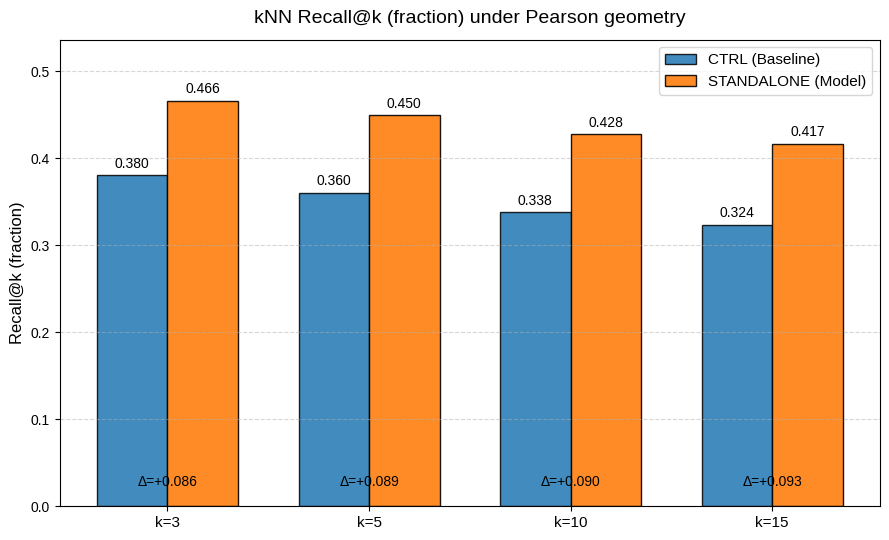

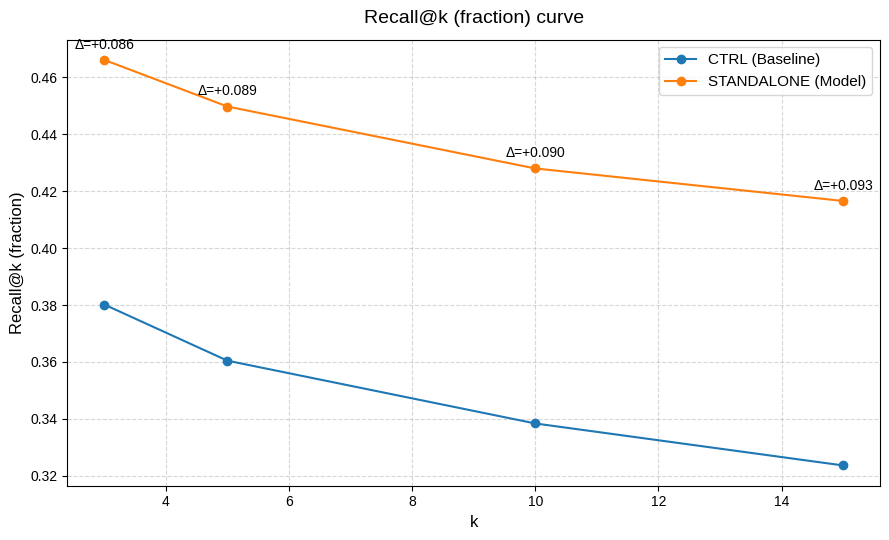

KeyError: 'null_gap'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Assumptions:
#   res2: output from compare_two_models_on_reps(...)
#     res2["gap"]["delta"]
#     res2["recall_fraction"]["ks"]
#     res2["recall_fraction"]["by_k"][k]["standalone"/"ctrl"/"delta"]
#
#   perm: output from paired_perm_test_delta_gap_and_recall_fraction(...)
#     perm["delta_gap_obs"], perm["p_gap"], perm["null_gap"]
#     perm["delta_recall_obs"][k], perm["p_recall"][k], perm["null_recall"][k]
# -----------------------------

COLOR_BASELINE = "#1f77b4"  # ctrl / baseline
COLOR_MODEL    = "#ff7f0e"  # standalone / model


def _autolabel(ax, rects, fmt="{:.3f}", dy=0.01, fontsize=10):
    for r in rects:
        h = r.get_height()
        ax.annotate(fmt.format(h),
                    xy=(r.get_x() + r.get_width()/2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=fontsize)


def plot_recall_fraction_bars(res2, title="kNN Recall@k (fraction) under Pearson geometry"):
    ks = list(res2["recall_fraction"]["ks"])
    byk = res2["recall_fraction"]["by_k"]

    standalone = [byk[k]["standalone"] for k in ks]
    ctrl       = [byk[k]["ctrl"]       for k in ks]
    delta      = [byk[k]["delta"]      for k in ks]

    x = np.arange(len(ks))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5.5))
    r1 = ax.bar(x - width/2, ctrl, width, label="CTRL (Baseline)", color=COLOR_BASELINE, edgecolor="black", alpha=0.85)
    r2 = ax.bar(x + width/2, standalone, width, label="STANDALONE (Model)", color=COLOR_MODEL, edgecolor="black", alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels([f"k={k}" for k in ks], fontsize=11)
    ax.set_ylabel("Recall@k (fraction)", fontsize=12)
    ax.set_title(title, fontsize=14, pad=12)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(fontsize=11)

    # set y-limit with some headroom
    ymax = max(max(standalone), max(ctrl)) * 1.15
    ax.set_ylim(0, min(1.0, max(0.1, ymax)))

    _autolabel(ax, r1, fmt="{:.3f}", fontsize=10)
    _autolabel(ax, r2, fmt="{:.3f}", fontsize=10)

    # Add delta text under each group
    for i, k in enumerate(ks):
        ax.text(x[i], 0.02, f"Δ={delta[i]:+.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


def plot_recall_fraction_curve(res2, title="Recall@k (fraction) curve"):
    ks = list(res2["recall_fraction"]["ks"])
    byk = res2["recall_fraction"]["by_k"]

    standalone = [byk[k]["standalone"] for k in ks]
    ctrl       = [byk[k]["ctrl"]       for k in ks]
    delta      = [byk[k]["delta"]      for k in ks]

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(ks, ctrl, marker="o", label="CTRL (Baseline)")
    ax.plot(ks, standalone, marker="o", label="STANDALONE (Model)")
    ax.set_xlabel("k", fontsize=12)
    ax.set_ylabel("Recall@k (fraction)", fontsize=12)
    ax.set_title(title, fontsize=14, pad=12)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=11)

    # annotate deltas
    for k, d in zip(ks, delta):
        ax.annotate(f"Δ={d:+.3f}", xy=(k, max(byk[k]["standalone"], byk[k]["ctrl"])),
                    xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()


def plot_perm_null_hist(null, obs, pval, title, bins=40):
    null = np.asarray(null, dtype=float)

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    ax.hist(null, bins=bins, alpha=0.8, edgecolor="black")
    ax.axvline(obs, linestyle="--", linewidth=2, label=f"Observed Δ = {obs:+.4f}")
    ax.axvline(-abs(obs), linestyle=":", linewidth=1)
    ax.axvline(+abs(obs), linestyle=":", linewidth=1)

    # descriptive 95% interval of null
    lo, hi = np.percentile(null, [2.5, 97.5])
    ax.axvline(lo, linestyle="-.", linewidth=1, label=f"Null 95%: [{lo:+.4f}, {hi:+.4f}]")
    ax.axvline(hi, linestyle="-.", linewidth=1)

    ax.set_title(f"{title}\nPermutation p (two-sided) = {pval:.4g}", fontsize=14, pad=12)
    ax.set_xlabel("Δ under label permutation", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()


def plot_all_permutation_nulls(res2, perm, bins=40):
    # 1) Gap
    plot_perm_null_hist(
        null=perm["null_gap"],
        obs=perm["delta_gap_obs"],
        pval=perm["p_gap"],
        title="Paired permutation null: ΔGap (intra–inter distance gap)",
        bins=bins
    )

    # 2) Recall@k (fraction) for each k
    ks = list(res2["recall_fraction"]["ks"])
    for k in ks:
        plot_perm_null_hist(
            null=perm["null_recall"][int(k)],
            obs=perm["delta_recall_obs"][int(k)],
            pval=perm["p_recall"][int(k)],
            title=f"Paired permutation null: ΔRecall@{k} (fraction)",
            bins=bins
        )


# -----------------------------
# Run visualizations
# -----------------------------
plot_recall_fraction_bars(res2)
plot_recall_fraction_curve(res2)

# Permutation null histograms (ΔGap + each ΔRecall@k)
plot_all_permutation_nulls(res2, perm, bins=45)


Gini Coefficient

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Input requirements:
#   avg_mat: (n_classes, n_receptors) Average receptor profiles for each class
#   kept_classes: list[int] Class IDs
#   label_color_map: dict[id] = (label_name, color_tuple)
# ============================================================

eps = 1e-8

# Center the average receptor profiles
row_mean = avg_mat.mean(axis=1, keepdims=True)
avg_centered = avg_mat - row_mean   # (n_classes, n_receptors)

# Gini Coefficient (response concentration)
def gini_coefficient(x, eps=1e-8):
    # Sort the values in ascending order
    x = np.sort(x)
    n = len(x)
    # Cumulative sum of sorted values
    cum_x = np.cumsum(x)
    # Handle cases where mean is close to zero to avoid division by zero
    if x.mean() < eps:
        return 0.0
    # Gini coefficient formula
    g = (2 * np.sum((np.arange(1, n + 1) * x)) / (n * cum_x[-1])) - (n + 1) / n
    return g

# Calculate Gini coefficient for each class
gini_per_class = []
for i in range(avg_centered.shape[0]):
    v = avg_centered[i]
    # Shift values to be non-negative for Gini calculation
    v_nonneg = v - v.min()
    gini_per_class.append(gini_coefficient(v_nonneg))
gini_per_class = np.array(gini_per_class)

# Prepare labels for classes
labels_per_class = []
for c in kept_classes:
    if c in label_color_map:
        lab, _ = label_color_map[c]
    else:
        lab = f"Class {c}"
    labels_per_class.append(lab)

# Identify indices of 'odorless' classes
odorless_idx = [i for i, lab in enumerate(labels_per_class)
                if "odorless" in lab.lower()]
print("Odorless class indices:", odorless_idx)

# ============================================================
# Sort by Gini coefficient (from high to low)
# ============================================================
# Use negative Gini values for argsort to get descending order
sorted_idx = np.argsort(-gini_per_class)
sorted_gini = gini_per_class[sorted_idx]
sorted_labels = [labels_per_class[i] for i in sorted_idx]

# ============================================================
# Plotting Gini Coefficients
# ============================================================
plt.figure(figsize=(10, 4))
bars = plt.bar(range(len(sorted_idx)), sorted_gini, color='steelblue', alpha=0.8)

# Set X-axis labels
plt.xticks(range(len(sorted_idx)), sorted_labels,
           rotation=90, ha='right', fontsize=14)

# Color labels: red for 'odorless' or 'bland', black for others
ax = plt.gca()
for i, ticklabel in enumerate(ax.get_xticklabels()):
    text = ticklabel.get_text().lower()
    if "odorless" in text or "bland" in text:
        ticklabel.set_color("red")
        ticklabel.set_fontweight("bold")
    else:
        ticklabel.set_color("black")

plt.ylabel("Gini coefficient (across receptors)", fontsize=12)
plt.title("Per-class Gini Coefficient Sorted by Concentration (High Gini = Concentrated Response)", fontsize=14)
plt.grid(alpha=0.3, linestyle='--')
plt.ylim(0,0.32) # Set consistent y-axis limit
# Uncomment to save figure if needed
#plt.savefig("/content/drive/MyDrive/receptor/result/figures/SI/gini_50_control.pdf", transparent=True)
plt.savefig("/content/drive/MyDrive/receptor/result/figures/gini_control.pdf", transparent=True)
plt.show()

Similarity Hotmap

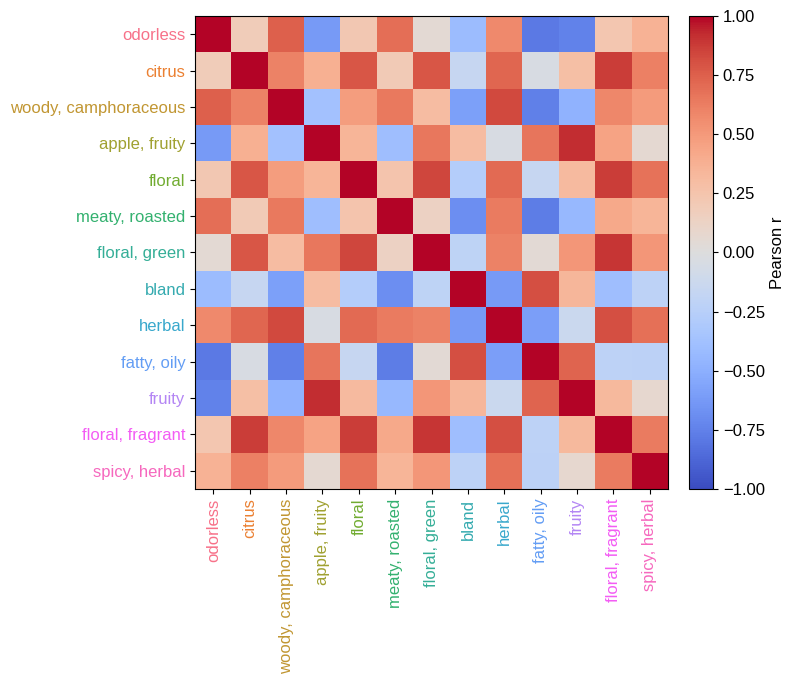

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ============================================================
# Input:
#   avg_mat: (n_classes, n_receptors)
#   kept_classes: list[int]
#   result: 来自 visualize_topn_reps_v2() 的输出
# ============================================================

# ✅ 从 visualize_topn_reps_v2 获取每个类别的标签和颜色映射
label_color_map = {c['id']: (c['label'], c['color']) for c in result["cluster_label_colors"]}

# Step 1️⃣ — calculate Pearson matrix
n = avg_mat.shape[0]
pearson_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        pearson_mat[i, j] = pearsonr(avg_mat[i], avg_mat[j])[0]

# Step 2️⃣ — label and color
labels_per_class = []
tick_colors = []
for c in kept_classes:
    if c in label_color_map:
        lab, col = label_color_map[c]
        labels_per_class.append(lab)
        tick_colors.append(col)
    else:
        labels_per_class.append(f"Class {c}")
        tick_colors.append((0, 0, 0))

# Step 3️⃣ — hotmap
plt.figure(figsize=(8, 7))
ax = plt.gca()
im = ax.imshow(pearson_mat, cmap='coolwarm', vmin=-1, vmax=1)


ax.set_xticks(np.arange(len(kept_classes)))
ax.set_xticklabels(labels_per_class, fontsize=12, rotation=90, ha='center')
ax.set_yticks(np.arange(len(kept_classes)))
ax.set_yticklabels(labels_per_class, fontsize=12)


for ticklabel, color in zip(ax.get_yticklabels(), tick_colors):
    ticklabel.set_color(color)
for ticklabel, color in zip(ax.get_xticklabels(), tick_colors):
    ticklabel.set_color(color)


#ax.set_xlabel("Odor class", fontsize=13)
#ax.set_ylabel("Odor class", fontsize=13)
#plt.title("Pearson Correlation Between Odor Classes (Mean Receptor Profiles)", fontsize=14)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")

plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/receptor/result/figures/SI/similiarity_map_15.pdf", transparent=True)
plt.show()


Comparison

[09:46:50] WARNING: not removing hydrogen atom without neighbors
[09:46:50] WARNING: not removing hydrogen atom without neighbors
[09:46:50] WARNING: not removing hydrogen atom without neighbors
[09:46:51] WARNING: not removing hydrogen atom without neighbors
[09:46:53] WARNING: not removing hydrogen atom without neighbors


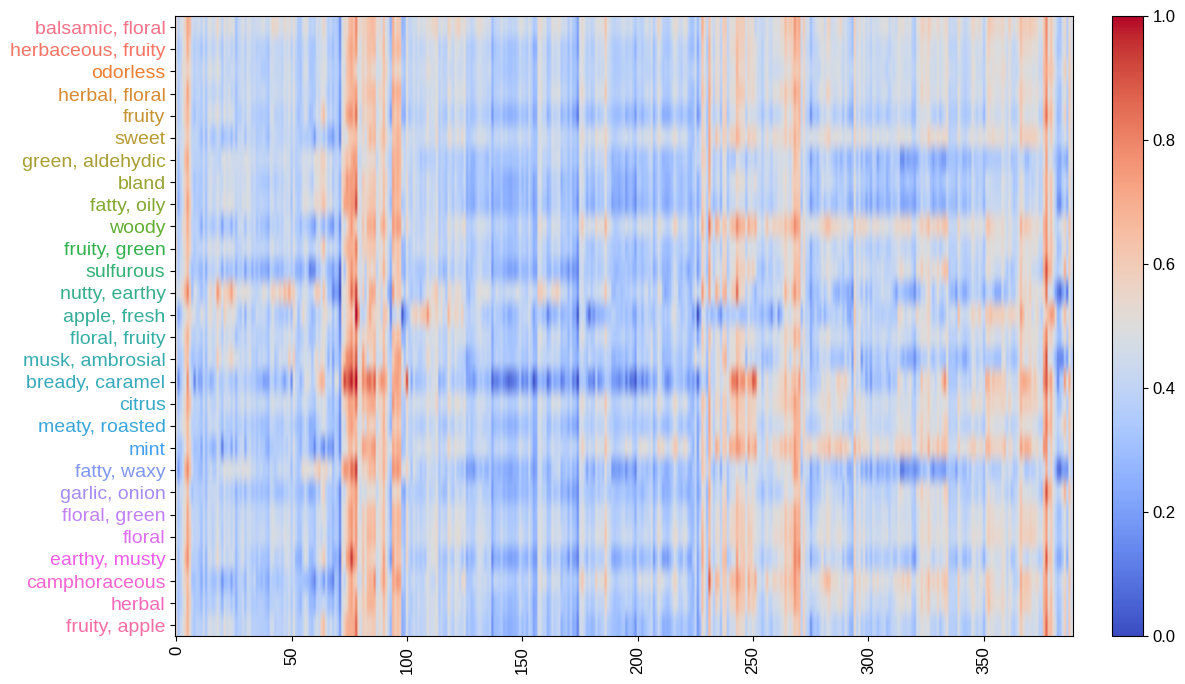

In [ ]:


# ========== Helper functions ==========

model_ctl.to(device).eval()   # Validation phase: eval disables dropout



# ========== 1) Prepare receptor bank ==========
receptor_bank = build_receptor_bank(model_ctl, receptor_seqs, device)  # (389,256)

# ========== 2) Iterate through dataset, aggregate by class ==========
labels = np.asarray(ds.labels, dtype=np.int32)  # Class labels for each sample (-1 for noise/fuzzy)
smiles_list = list(ds.df["SMILES"])

include_noise = False  # Whether to include samples with label = -1
if not include_noise:
    valid_idx = np.where(labels != -1)[0]
else:
    valid_idx = np.arange(len(labels))

# Count class IDs (excluding -1)
class_ids = sorted(set(int(l) for l in labels if (include_noise or l != -1)))

# Accumulate sums and counts for each class
sum_by_class = {c: torch.zeros(receptor_bank.size(0), device=device) for c in class_ids}
cnt_by_class = {c: 0 for c in class_ids}

with torch.no_grad():
    for i in valid_idx:
        c = int(labels[i])
        if (not include_noise) and c == -1:
            continue
        smi = smiles_list[i]
        try:
            hd = encode_smiles_hd(model_ctl, smi, device)           # (128,)
            panel = predict_panel_vector(model_ctl, hd, receptor_bank)  # (389,)
            panel = normalize_panel(panel, mode=per_sample_mode)
            sum_by_class[c] += panel
            cnt_by_class[c] += 1
        except Exception as e:
            # Individual failed samples can be skipped
            print(f"[warn] sample #{i} failed: {e}")

# ========== 3) Calculate average activation profile matrix for each class ==========
# Rows: classes; Columns: receptors (389)
avg_panels = []
kept_classes = []
for c in class_ids:
    if cnt_by_class[c] > 0:
        avg_panels.append( (sum_by_class[c] / cnt_by_class[c]).unsqueeze(0) )
        kept_classes.append(c)

if len(avg_panels) == 0:
    raise RuntimeError("No available samples for visualization (possibly all noise or encoding failed).")

avg_mat = torch.cat(avg_panels, dim=0).cpu().numpy()  # (n_classes, 389)
'''
eps = 1e-8
row_mean = avg_mat.mean(axis=1, keepdims=True)
row_std  = avg_mat.std(axis=1, keepdims=True) + eps
avg_mat_norm = (avg_mat - row_mean) / row_std
'''
# ---- Receptor column reordering: Hierarchical clustering + optimal leaf ordering ----
# We measure similarity between receptors based on "class average spectra" (avg_mat_norm, where rows are z-scored).
# Data matrix: X = Receptors × Classes
X = avg_mat.T  # shape: (n_receptors, n_classes)



# Similarity metric: "correlation" (equivalent to 1 - Pearson correlation), or "cosine" is recommended.
metric = "correlation"  # Can be changed to "cosine"
D = pdist(X, metric=metric)                  # Distance vector for all receptor pairs
Z = linkage(D, method="average")             # Hierarchical clustering (average/ward/complete are all acceptable)
Z_opt = optimal_leaf_ordering(Z, D)          # Optimal leaf ordering: Makes adjacent leaves more similar
order = leaves_list(Z_opt)                   # Column reordering index, shape: (n_receptors,)

# Apply reordering
avg_mat_reordered = avg_mat[:, order]


# ========== 4) Heatmap visualization ==========

plt.figure(figsize=(12, max(4, 0.25 * len(kept_classes))))
ax = plt.gca()

# Plot heatmap (already reordered)
im = ax.imshow(avg_mat_reordered, aspect='auto', cmap="coolwarm")

# ✅ Get labels and color mapping for each class from visualize_topn_reps_v2
label_color_map = {c['id']: (c['label'], c['color']) for c in result["cluster_label_colors"]}

# ✅ Generate row labels (prioritizing classes present in kept_classes)
yticklabels = []
ytickcolors = []
for c in kept_classes:
    if c in label_color_map:
        lab, col = label_color_map[c]
        yticklabels.append(lab)
        ytickcolors.append(col)
    else:
        yticklabels.append(f"Class {c}")
        ytickcolors.append((0, 0, 0))  # Default black

# ✅ Set y-axis labels
ax.set_yticks(np.arange(len(kept_classes)))
ax.set_yticklabels(yticklabels, fontsize=14)

# ✅ Color each ytick label
for ticklabel, color in zip(ax.get_yticklabels(), ytickcolors):
    ticklabel.set_color(color)

# ✅ Set x-axis labels (receptor index)
nR = avg_mat.shape[1]
step = 50 if nR > 200 else 20
xticks = np.arange(0, nR, step)
ax.set_xticks(xticks)
ax.set_xticklabels([str(j) for j in xticks], rotation=90)

# Axes and title
#ax.set_xlabel("Receptor index (0..{})俗".format(nR - 1))
#ax.set_ylabel("Cluster / Class (Representative Label)")
#ax.set_title("Per-class Mean Activation Panel ({} receptors)".format(nR))

# Color bar
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/receptor/result/figures/SI/receptormap_control_15.pdf", transparent=True)
plt.show()

evaluate on dataset

Receptor Significance (Fisher Score)

[07:24:18] WARNING: not removing hydrogen atom without neighbors
[07:24:19] WARNING: not removing hydrogen atom without neighbors
[07:24:19] WARNING: not removing hydrogen atom without neighbors
[07:24:20] WARNING: not removing hydrogen atom without neighbors
[07:24:22] WARNING: not removing hydrogen atom without neighbors


[OK] collected 3325 samples × 389 receptors


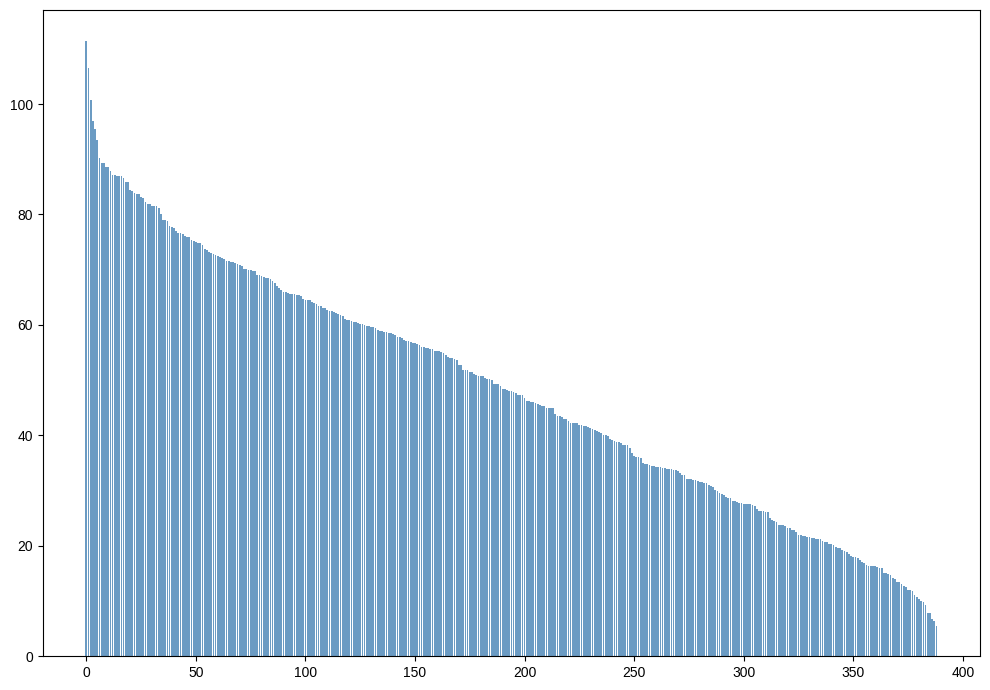

In [ ]:
from sklearn.feature_selection import f_classif
import numpy as np
import matplotlib.pyplot as plt
per_sample_mode = "directional"

X_list = []
y_list = []

with torch.no_grad():
    for i in range(len(labels)):
        c = int(labels[i])
        if c == -1:
            continue
        smi = smiles_list[i]
        try:
            hd = encode_smiles_hd(standalone, smi, device)           # (128,)
            panel = predict_panel_vector(standalone, hd, receptor_bank)  # (389,)
            panel = normalize_panel(panel, mode=per_sample_mode)     #
            X_list.append(panel.cpu().numpy())
            y_list.append(c)
        except Exception as e:
            print(f"[warn] sample #{i} failed: {e}")
            continue

X = np.vstack(X_list)   # (N_samples, 389)
y = np.array(y_list)
print(f"[OK] collected {len(y)} samples × {X.shape[1]} receptors")


f_values, p_values = f_classif(X, y)


receptor_names_reordered = [names[i] for i in range(X.shape[1])]


top_k = 389
idx_top = np.argsort(f_values)[::-1][:top_k]
#idx_top = np.argsort(f_values)[::-1][-top_k:]

plt.figure(figsize=(10, 7))
#plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # matplotlib default font

plt.bar(range(top_k), f_values[idx_top], color="steelblue", alpha=0.8)
#plt.bar(range(top_k), f_values[idx_top], color="SandyBrown", alpha=0.8)
#plt.xticks(range(top_k), [receptor_names_reordered[i] for i in idx_top], rotation=45, fontsize=16)
#plt.ylabel("Fisher score (F-value)", fontsize=20)
#plt.title(f"Top {top_k} Most Discriminative Receptors Across Classes", fontsize=20)
#plt.title(f"Total 389 Receptors' Fisher Score Across Classes", fontsize=20)
highlight_receptors = []  # Receptor names you want to annotate

for rec in highlight_receptors:
    if rec in receptor_names_reordered:

        idx_global = receptor_names_reordered.index(rec)

        if idx_global in idx_top:
            idx_in_top = np.where(idx_top == idx_global)[0][0]
            plt.axvline(
                x=idx_in_top,
                color="steelblue",
                linestyle="--",
                linewidth=1.5,
                alpha=0.8,
            )
            plt.text(
                idx_in_top,
                max(f_values[idx_top]) * 1.02,
                rec,
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=11,
                color="steelblue",
                fontweight="bold"
            )

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/receptor/result/figures/fisherscore.pdf", transparent=True)
plt.show()


In [ ]:
fisher_df = pd.DataFrame({
    "Receptor": receptor_names_reordered,
    "FisherScore": f_values
})
output_path = "/content/drive/MyDrive/receptor/cleaned_odor_data/fisher.csv"
fisher_df.to_csv(output_path, index=False, encoding="utf-8-sig")

Fill NaN values with detection limit

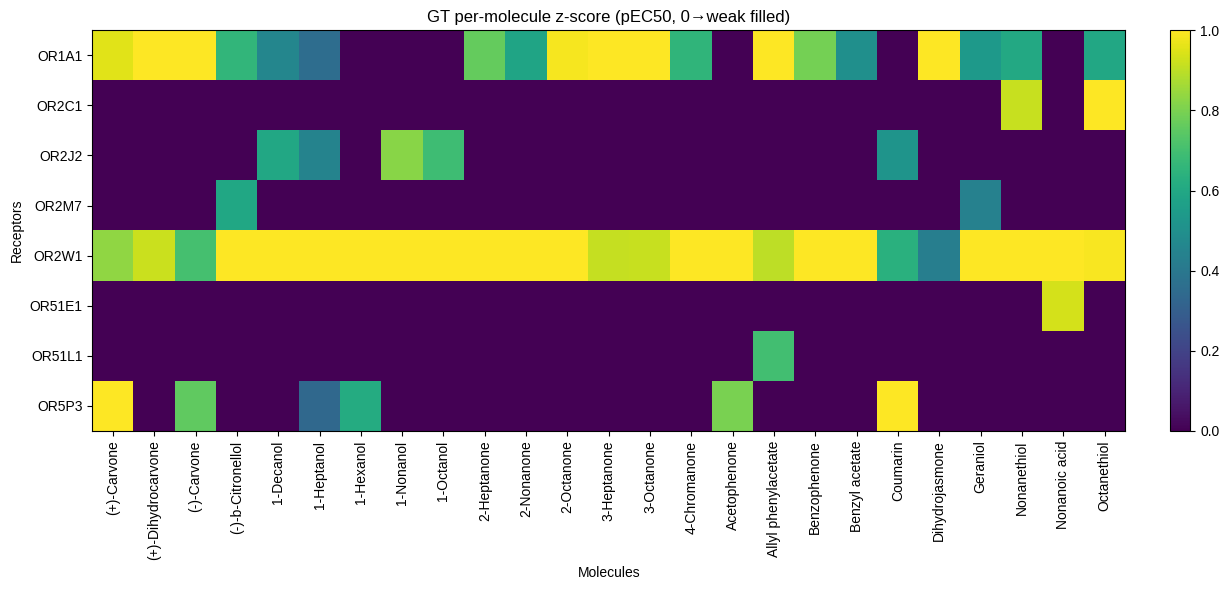

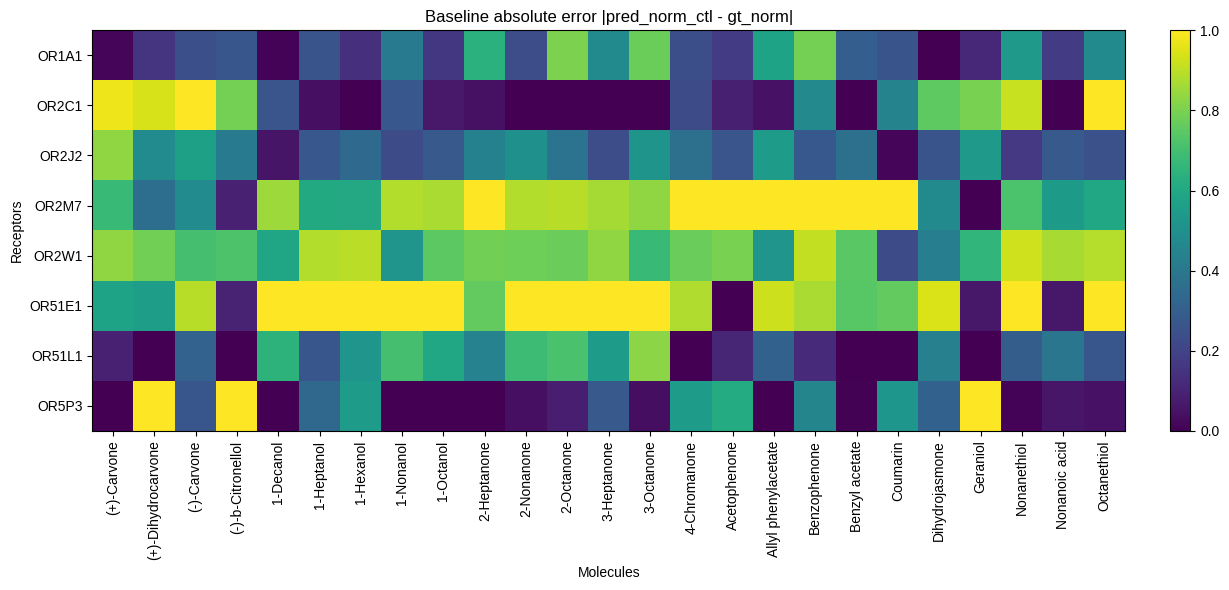

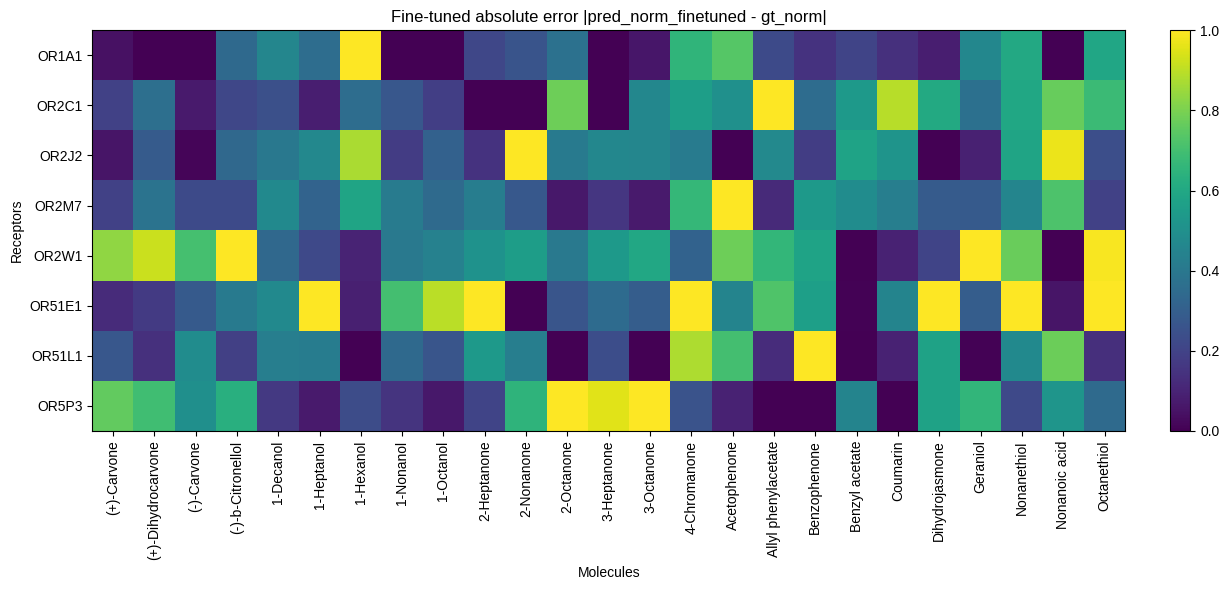

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= Read and parse CSV (two header rows + two receptor info columns) =========
#csv_path = "/content/drive/MyDrive/receptor/cleaned_odor_data/groundtruth.csv"
csv_path = "/content/drive/MyDrive/receptor/cleaned_odor_data/groundtruth_small.csv"
df = pd.read_csv(csv_path, header=None, engine="python")

# ========= Extract receptor and molecule information =========
# The first two columns are receptor information, column 0 is receptor name, column 1 is receptor sequence
rec_names = df.iloc[2:, 0].astype(str).tolist()
rec_seqs  = df.iloc[2:, 1].astype(str).tolist()

# Row 0 is molecule name, Row 1 is molecule SMILES
mol_names  = df.iloc[0, 2:].astype(str).tolist()
mol_smiles = df.iloc[1, 2:].astype(str).tolist()

rec_names = df.iloc[2:, 0].astype(str).str.strip().str.strip("'").tolist()
mol_names = df.iloc[0, 2:].astype(str).str.strip().str.strip("'").tolist()

# ====================================================
# 1. Ground truth pEC50 matrix & per-molecule normalization (z-score per molecule)
# ====================================================

# ground truth: df format
# Row 0: Molecule name
# Row 1: Molecule SMILES
# Row 2+: Receptor rows, first two columns (receptor name, sequence), followed by log(EC50[M]) values
gt_logM_raw = df.iloc[2:, 2:].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)  # (R,C)

# 0 means "no activity"; we treat it as extremely weak activity and replace it with a fixed very weak logM value, e.g., -2.0
gt_logM_filled = gt_logM_raw.copy()
mask_is0 = np.isfinite(gt_logM_filled) & (gt_logM_filled == 0.0)
gt_logM_filled[mask_is0] = -2.0  # If you decide on a weaker value later (-6.0), change it here

# pEC50 = -logM: larger value means stronger activity
gt_pEC50 = -gt_logM_filled  # (R,C)

# Mask: values other than NaN are considered valid (including cells that were originally 0 and have been filled)
mask_valid = ~np.isnan(gt_logM_filled)  # (R,C)

import numpy as np

def colwise_zscore_with_mask(M, mask):
    """
    For Ground Truth only:
    Performs directional normalization for each molecule (column):
      1) Subtracts the median from the receptor values that are mask=True and not NaN in that column
      2) Performs L2 normalization by column (unit vector)
      3) Then min-max scales that column to [0, 1]
    Cells with mask=False or NaN remain NaN.
    Returns shape (R,C).
    """
    R, C = M.shape
    out = np.full_like(M, np.nan, dtype=float)
    eps = 1e-8

    for j in range(C):
        col_mask = mask[:, j]
        if not np.any(col_mask):
            continue

        col = M[:, j].astype(float)
        # Only use cells where mask=True and not NaN
        valid = col_mask & ~np.isnan(col)
        if not np.any(valid):
            continue

        vals = col[valid]

        # Step 1: Subtract median
        median = np.median(vals)
        centered = vals - median

        # Step 2: L2 Unitization
        norm = np.sqrt(np.sum(centered ** 2))
        if norm < eps:
            norm = eps
        unit = centered / norm

        # Step 3: min-max scaling to [0, 1]
        u_min = unit.min()
        u_max = unit.max()
        denom = u_max - u_min
        if abs(denom) < eps:
            denom = eps
        scaled = (unit - u_min) / denom

        out[valid, j] = scaled

    return out  # (R,C)


def colwise_zscore_ignore_nan(M):
    """
    For Model Prediction only:
    Performs directional normalization for each molecule (column):
      1) Subtracts the median from all non-NaN values in that column
      2) Performs L2 normalization to a unit vector
      3) Then min-max scales that column to [0, 1]
    NaN positions remain NaN.
    Returns shape (R,C).
    """
    R, C = M.shape
    out = np.full_like(M, np.nan, dtype=float)
    eps = 1e-8

    for j in range(C):
        col = M[:, j].astype(float)
        # All non-NaN values participate
        valid = ~np.isnan(col)
        if not np.any(valid):
            continue

        vals = col[valid]

        # Step 1: Subtract median
        median = np.median(vals)
        centered = vals - median

        # Step 2: L2 Unitization
        norm = np.sqrt(np.sum(centered ** 2))
        if norm < eps:
            norm = eps
        unit = centered / norm

        # Step 3: min-max scaling to [0, 1]
        u_min = unit.min()
        u_max = unit.max()
        denom = u_max - u_min
        if abs(denom) < eps:
            denom = eps
        scaled = (unit - u_min) / denom

        out[valid, j] = scaled

    return out  # (R,C)


# ========= Common prediction tools =========
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
standalone.to(device).eval()
model_ctl.to(device).eval()


@torch.no_grad()
def predictor_head(model, x):
    y = x
    for i, layer in enumerate(model.predictor):
        y = layer(y)
        if i < len(model.predictor) - 1:
            y = torch.relu(y)
    return y.squeeze(-1)

@torch.no_grad()
def predict_panel_vector(model, h_d, receptor_bank):
    n = receptor_bank.size(0)
    x = torch.cat([h_d.unsqueeze(0).expand(n, -1), receptor_bank], dim=1)  # (n,384)
    return predictor_head(model, x)  # (n,)

# ========= Generate prediction matrices for each of the two models (R × C) =========
R, C = len(rec_names), len(mol_names)

# Note: The protein encoder weights of the two models may be different, so build receptor banks separately
receptor_bank_ctl  = build_receptor_bank(model_ctl,  rec_seqs, device)
receptor_bank_std  = build_receptor_bank(standalone, rec_seqs, device)

pred_mat_ctl        = np.full((R, C), np.nan, dtype=np.float32)
pred_mat_standalone = np.full((R, C), np.nan, dtype=np.float32)

with torch.no_grad():
    for j, smi in enumerate(mol_smiles):
        # baseline
        try:
            hd_ctl = encode_smiles_hd(model_ctl, smi, device)
            panel_ctl = predict_panel_vector(model_ctl, hd_ctl, receptor_bank_ctl).cpu().numpy()
            pred_mat_ctl[:, j] = panel_ctl
        except Exception as e:
            print(f"[warn][baseline] predict failed for mol #{j} ({mol_names[j]}): {e}")

        # fine-tuned
        try:
            hd_std = encode_smiles_hd(standalone, smi, device)
            panel_std = predict_panel_vector(standalone, hd_std, receptor_bank_std).cpu().numpy()
            pred_mat_standalone[:, j] = panel_std
        except Exception as e:
            print(f"[warn][finetuned] predict failed for mol #{j} ({mol_names[j]}): {e}")

# Normalize ground truth to "each molecule's own fingerprint"
gt_norm = colwise_zscore_with_mask(gt_pEC50, mask_valid)  # (R,C)


# Normalize predictions of the two models
pred_norm_ctl        = colwise_zscore_ignore_nan(pred_mat_ctl)        # baseline
pred_norm_standalone = colwise_zscore_ignore_nan(pred_mat_standalone) # fine-tuned
# First allocate error matrices (filled with NaN)
err_abs_ctl = np.full_like(gt_norm, np.nan, dtype=float)
err_abs_std = np.full_like(gt_norm, np.nan, dtype=float)
# Valid cells = GT has value (mask_valid) AND this model is not NaN in this cell
valid_ctl = mask_valid & ~np.isnan(pred_norm_ctl) & ~np.isnan(gt_norm)
valid_std = mask_valid & ~np.isnan(pred_norm_standalone) & ~np.isnan(gt_norm)
# For fair comparison, we can also define cells where both models are valid:
valid_both = valid_ctl & valid_std
# Absolute error: baseline vs GT
err_abs_ctl[valid_both] = np.abs(pred_norm_ctl[valid_both] - gt_norm[valid_both])

# Absolute error: fine-tuned vs GT
err_abs_std[valid_both] = np.abs(pred_norm_standalone[valid_both] - gt_norm[valid_both])
# ====================================================
# 2. Absolute error matrix: |prediction - GT|
#    Only keep "comparable" cells, set others to NaN
# ====================================================

# Definition of "comparable":
# (a) GT is not NaN in this cell
# (b) both baseline and finetuned are also not NaN in this cell
valid_both = (
    ~np.isnan(gt_norm) &
    ~np.isnan(pred_norm_ctl) &
    ~np.isnan(pred_norm_standalone)
)  # (R,C)

# Absolute error: baseline vs GT
#err_abs_ctl = np.full_like(gt_norm, np.nan, dtype=float)
err_abs_ctl[valid_both] = np.abs(pred_norm_ctl[valid_both] - gt_norm[valid_both])
#err_abs_ctl[valid_both] = pred_norm_ctl[valid_both] - gt_norm[valid_both]
# Absolute error: fine-tuned vs GT
err_abs_std = np.full_like(gt_norm, np.nan, dtype=float)
err_abs_std[valid_both] = np.abs(pred_norm_standalone[valid_both] - gt_norm[valid_both])

# We want the two error heatmaps to share a color bar range (0 ~ vmax)
all_abs_vals = np.concatenate([
    err_abs_ctl[~np.isnan(err_abs_ctl)],
    err_abs_std[~np.isnan(err_abs_std)]
])
if all_abs_vals.size > 0:
    # Use 99th percentile instead of max to avoid outliers stretching the color bar
    vmax_err_abs = np.nanpercentile(all_abs_vals, 99)
else:
    vmax_err_abs = 1.0

# The color bar range for the Ground Truth heatmap can be set independently
gt_vals = gt_norm[~np.isnan(gt_norm)]
if gt_vals.size > 0:
    vmin_gt = np.nanpercentile(gt_vals, 1)
    vmax_gt = np.nanpercentile(gt_vals, 99)
else:
    vmin_gt, vmax_gt = -1.0, 1.0

# ====================================================
# 3. Plot heatmaps:
#    A. Ground Truth (normalized true response profile)
#    B. Baseline Absolute Error
#    C. Fine-tuned Absolute Error
# ====================================================

def show_heat(mat, title, vmin=None, vmax=None):
    """
    mat: (R,C)
    Rows = Receptors
    Columns = Molecules
    """
    R, C = mat.shape
    plt.figure(figsize=(max(8, C*0.5), max(6, R*0.25)))
    im = plt.imshow(mat, aspect='auto', vmin=vmin, vmax=vmax)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    # Use sparse labels for axes to avoid overlap
    step_c = max(1, C // 20)
    step_r = max(1, R // 30)
    plt.xticks(
        np.arange(0, C, step_c),
        [mol_names[k] for k in range(0, C, step_c)],
        rotation=90
    )
    plt.yticks(
        np.arange(0, R, step_r),
        [rec_names[k] for k in range(0, R, step_r)]
    )

    plt.xlabel("Molecules")
    plt.ylabel("Receptors")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# (A) Ground truth fingerprint heatmap
show_heat(
    gt_norm,
    title="GT per-molecule z-score (pEC50, 0\u2192weak filled)",
    vmin=vmin_gt,
    vmax=vmax_gt
)

# (B) Baseline absolute error heatmap
show_heat(
    err_abs_ctl,
    title="Baseline absolute error |pred_norm_ctl - gt_norm|",
    vmin=0.0,
    vmax=vmax_err_abs
)

# (C) Fine-tuned absolute error heatmap
show_heat(
    err_abs_std,
    title="Fine-tuned absolute error |pred_norm_finetuned - gt_norm|",
    vmin=0.0,
    vmax=vmax_err_abs
)

Statistical Visualization

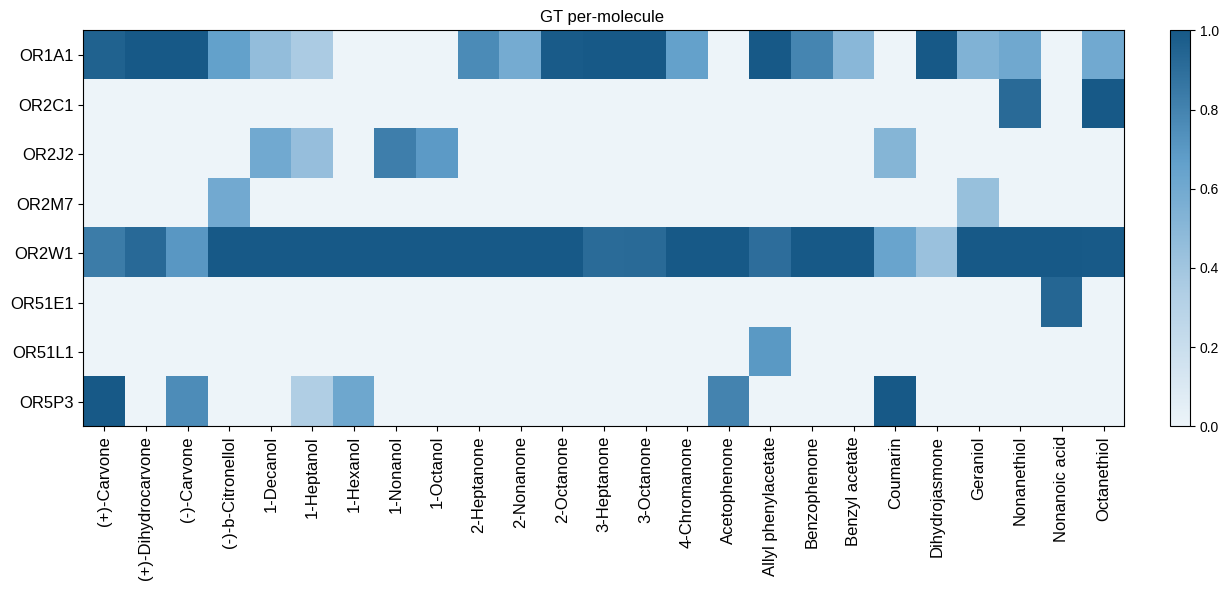

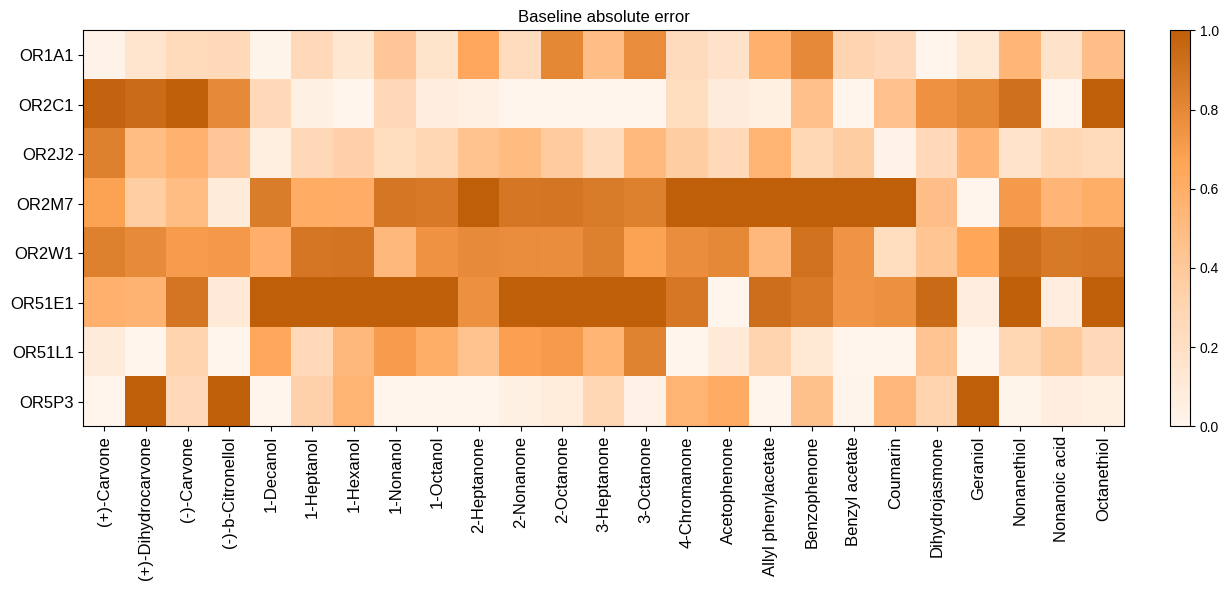

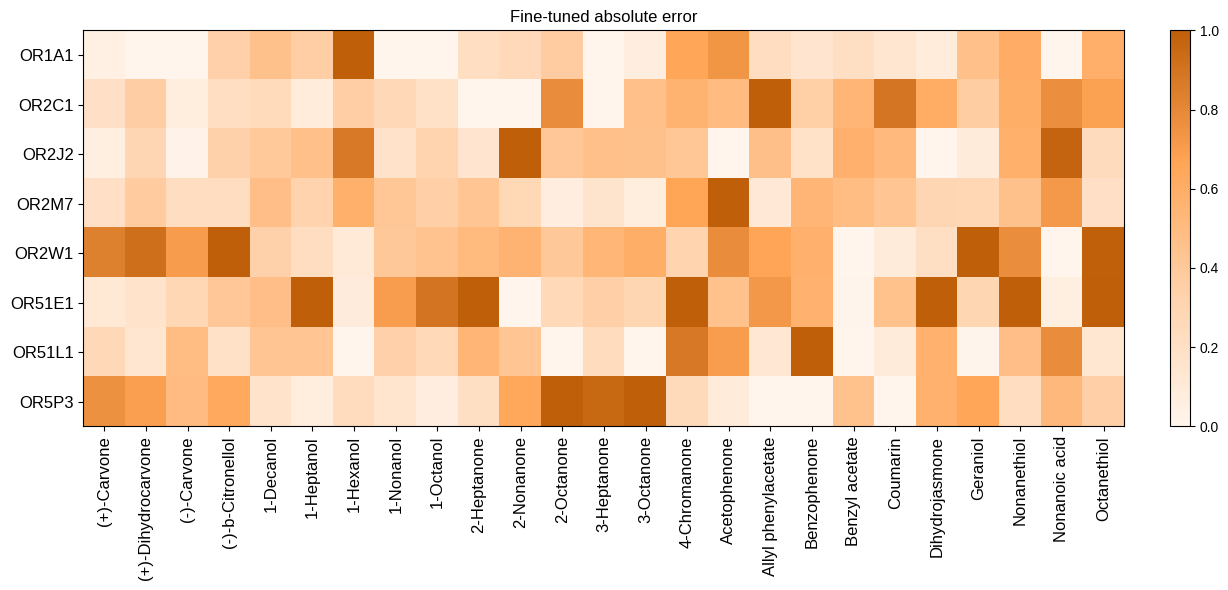

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors


err_cmap = LinearSegmentedColormap.from_list(
    "err_cmap",
    [
        "#fff5f0",
        "#fcbba1",
        "#fb6a4a",
        "#cb181d"
    ]
)


COLOR_BASELINE = "#1f77b4"
COLOR_FINETUNE = "#ff7f0e"

def blend(c1, c2, t):

    r1, g1, b1 = mcolors.to_rgb(c1)
    r2, g2, b2 = mcolors.to_rgb(c2)
    return (r1 + (r2 - r1)*t, g1 + (g2 - g1)*t, b1 + (b2 - b1)*t)

def rgb_to_hex(rgb):
    return mcolors.to_hex(rgb)

def make_seq_cmap(name, base_hex):

    c0 = rgb_to_hex(blend("#ffffff", base_hex, 0.08))

    c1 = rgb_to_hex(blend("#ffffff", base_hex, 0.35))

    c2 = rgb_to_hex(blend("#ffffff", base_hex, 0.70))

    c3 = rgb_to_hex(blend(base_hex, "#000000", 0.25))

    return LinearSegmentedColormap.from_list(name, [c0, c1, c2, c3])

gt_cmap  = make_seq_cmap("gt_cmap",  COLOR_BASELINE)
err_cmap = make_seq_cmap("err_cmap", COLOR_FINETUNE)






filled_mask = (~np.isnan(gt_logM_raw)) & (gt_logM_raw == 0.0)   # (R,C)


valid_both = (
    ~np.isnan(gt_norm) &
    ~np.isnan(pred_norm_ctl) &
    ~np.isnan(pred_norm_standalone)
)


# baseline
err_ctl_signed = np.full_like(gt_norm, np.nan, dtype=float)
err_ctl_signed[valid_both] = pred_norm_ctl[valid_both] - gt_norm[valid_both]

include_mask_ctl = valid_both

err_abs_ctl_masked = np.full_like(gt_norm, np.nan, dtype=float)
err_abs_ctl_masked[include_mask_ctl] = np.abs(err_ctl_signed[include_mask_ctl])

# finetuned
err_std_signed = np.full_like(gt_norm, np.nan, dtype=float)
err_std_signed[valid_both] = pred_norm_standalone[valid_both] - gt_norm[valid_both]
include_mask_std = valid_both
err_abs_std_masked = np.full_like(gt_norm, np.nan, dtype=float)
err_abs_std_masked[include_mask_std] = np.abs(err_std_signed[include_mask_std])

all_abs_vals = np.concatenate([
    err_abs_ctl_masked[~np.isnan(err_abs_ctl_masked)],
    err_abs_std_masked[~np.isnan(err_abs_std_masked)]
])
vmax_err_abs = np.nanpercentile(all_abs_vals, 99) if all_abs_vals.size > 0 else 1.0


gt_vals = gt_norm[~np.isnan(gt_norm)]
vmin_gt = np.nanpercentile(gt_vals, 1)  if gt_vals.size > 0 else -1.0
vmax_gt = np.nanpercentile(gt_vals, 99) if gt_vals.size > 0 else  1.0



def show_heat(
    mat, title, colormap="viridis",
    vmin=None, vmax=None,
    xticklabels=None, yticklabels=None,
    save_pdf_path=None,
    transparent=False
):
    """
    mat: (R,C) with NaN in masked-out cells.
    NaN 会显示成 vmin 的颜色。
    """

    R, C = mat.shape
    mat_plot = mat.copy()

    if vmin is None:
        vmin = np.nanmin(mat_plot)
    if vmax is None:
        vmax = np.nanmax(mat_plot)

    mat_plot[np.isnan(mat_plot)] = vmin


    fig, ax = plt.subplots(figsize=(max(8, C*0.5), max(6, R*0.25)))
    im = ax.imshow(mat_plot, aspect='auto', cmap=colormap, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ticks
    step_c = max(1, C // 20)
    step_r = max(1, R // 30)

    if xticklabels is None:
        xticklabels = [f"{k}" for k in range(C)]
    if yticklabels is None:
        yticklabels = [f"{k}" for k in range(R)]

    ax.set_xticks(np.arange(0, C, step_c))
    ax.set_yticks(np.arange(0, R, step_r))


    ax.set_xticklabels([mol_names[k] for k in range(0, C, step_c)], fontsize=12, rotation=90)
    ax.set_yticklabels([rec_names[k] for k in range(0, R, step_r)], fontsize=12)

    ax.set_title(title)
    ax.grid(False)
    fig.tight_layout()


    if save_pdf_path is not None:
        os.makedirs(os.path.dirname(save_pdf_path), exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=transparent)

    plt.show()
    plt.close(fig)


show_heat(gt_norm, "GT per-molecule ", colormap=gt_cmap,
          vmin=vmin_gt, vmax=vmax_gt, save_pdf_path="/content/drive/MyDrive/receptor/result/figures/GTheatmap.pdf")


show_heat(
    err_abs_ctl_masked,
    "Baseline absolute error",colormap=err_cmap,
    vmin=0.0, vmax=vmax_err_abs, save_pdf_path="/content/drive/MyDrive/receptor/result/figures/errheatmap_baseline.pdf"
)


show_heat(
    err_abs_std_masked,
    "Fine-tuned absolute error",colormap=err_cmap,
    vmin=0.0, vmax=vmax_err_abs, save_pdf_path="/content/drive/MyDrive/receptor/result/figures/errheatmap_RAMS.pdf"
)

def summarize_errors(err_abs_mat, include_mask, tag):
    valid = include_mask & ~np.isnan(err_abs_mat)
    global_mae = float(np.nanmean(err_abs_mat[valid])) if np.any(valid) else np.nan
    global_med = float(np.nanmedian(err_abs_mat[valid])) if np.any(valid) else np.nan
    q25, q75 = (np.nanpercentile(err_abs_mat[valid], [25, 75]) if np.any(valid) else (np.nan, np.nan))

    print(f"\n[{tag}] Global MAE = {global_mae:.4f} | Median = {global_med:.4f} | IQR = [{q25:.4f}, {q75:.4f}]")
    print(f"Included cells = {int(valid.sum())} / {err_abs_mat.size}")


    print(f"\n[{tag}] Per-molecule MAE (original order):")
    R, C = err_abs_mat.shape
    for j in range(C):
        col_mask = valid[:, j]
        n = int(col_mask.sum())
        if n == 0:
            print(f"{j:4d}  {mol_names[j]:<30s}  MAE=   nan  (valid=0)")
            continue
        vals = err_abs_mat[col_mask, j]
        mae = float(np.nanmean(vals))
        print(f"{j:4d}  {mol_names[j]:<30s}  MAE={mae:6.4f}  (valid={n})")

#summarize_errors(err_abs_ctl_masked, include_mask_ctl,  tag="Baseline")
#summarize_errors(err_abs_std_masked, include_mask_std, tag="Fine-tuned")


Pearson

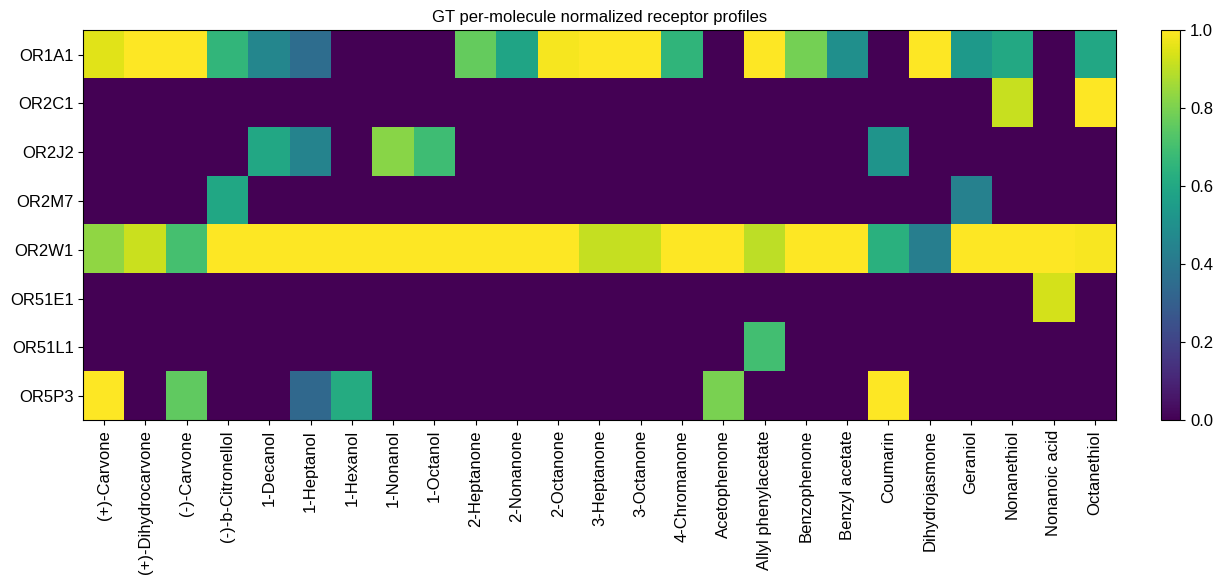

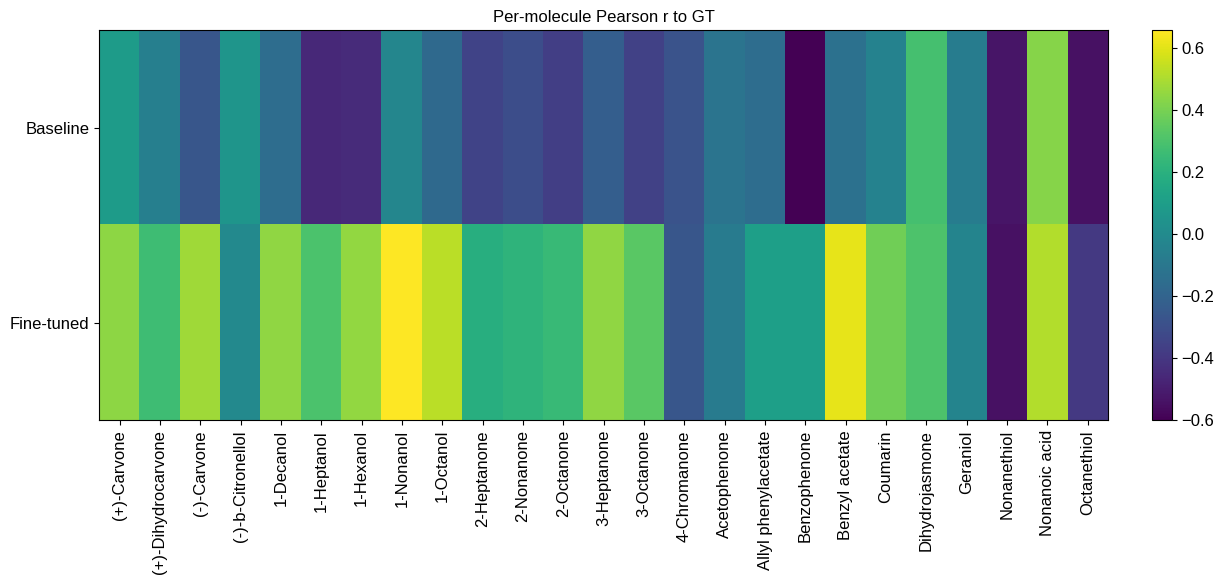


[Baseline] Per-molecule Pearson r  summary:
  Mean   = -0.1916
  Median = -0.1695
  IQR    = [-0.3590, -0.0604]
  Valid molecules = 25 / 25

[Baseline] Per-molecule Pearson r  (original order):
   0  (+)-Carvone                     cos=0.0915
   1  (+)-Dihydrocarvone              cos=-0.0604
   2  (-)-Carvone                     cos=-0.2659
   3  (-)-b-Citronellol               cos=0.0534
   4  1-Decanol                       cos=-0.1530
   5  1-Heptanol                      cos=-0.4566
   6  1-Hexanol                       cos=-0.4474
   7  1-Nonanol                       cos=-0.0244
   8  1-Octanol                       cos=-0.1695
   9  2-Heptanone                     cos=-0.3480
  10  2-Nonanone                      cos=-0.3032
  11  2-Octanone                      cos=-0.3699
  12  3-Heptanone                     cos=-0.2261
  13  3-Octanone                      cos=-0.3590
  14  4-Chromanone                    cos=-0.2776
  15  Acetophenone                    cos=-0.1148
  16  A

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Define Masks ----------
# Original 0 (inactive) positions (using raw data; not after filling)
filled_mask = (~np.isnan(gt_logM_raw)) & (gt_logM_raw == 0.0)   # (R,C)

# Positions that can be compared: GT and both models are non-NaN in this cell
valid_both = (
    ~np.isnan(gt_norm) &
    ~np.isnan(pred_norm_ctl) &
    ~np.isnan(pred_norm_standalone)
)

# If you have decided "no special treatment for filled values & negative errors",
# then include_mask_* directly uses valid_both:
include_mask_ctl = valid_both
include_mask_std = valid_both

# ---------- 2) Per-molecule Pearson correlation calculation ----------
def per_molecule_cosine(gt_mat, pred_mat, include_mask, eps=1e-8):
    """
    For each molecule (column):
      - On receptors where include_mask[:, j] & GT/pred are both non-NaN
      - Calculate cosine similarity
    Returns shape: (C,)
    """
    R, C = gt_mat.shape
    cos_vec = np.full(C, np.nan, dtype=float)

    for j in range(C):
        mask_j = include_mask[:, j] & ~np.isnan(gt_mat[:, j]) & ~np.isnan(pred_mat[:, j])
        if np.sum(mask_j) < 2:   # At least 2 receptors must be involved
            continue
        g = gt_mat[mask_j, j].astype(float)
        p = pred_mat[mask_j, j].astype(float)
        norm_g = np.linalg.norm(g)
        norm_p = np.linalg.norm(p)
        if norm_g < eps or norm_p < eps:
            continue
        cos_vec[j] = np.dot(g, p) / (norm_g * norm_p)
    return cos_vec
def per_molecule_pearson(gt_mat, pred_mat, valid_mask, eps=1e-8):
    """
    For each molecule (column):
      - On receptors where valid_mask[:, j] is True
      - Calculate Pearson correlation
    Returns shape: (C,)
    """
    R_, C_ = gt_mat.shape
    corr_vec = np.full(C_, np.nan, dtype=float)

    for j in range(C_):
        mask_j = valid_mask[:, j]
        # At least 2 points are needed for correlation coefficient (3 is more stable)
        if np.sum(mask_j) < 2:
            continue

        g = gt_mat[mask_j, j].astype(float)
        p = pred_mat[mask_j, j].astype(float)

        # Mean centering
        g_c = g - g.mean()
        p_c = p - p.mean()

        # Standard deviation
        std_g = g_c.std()
        std_p = p_c.std()
        if std_g < eps or std_p < eps:
            continue

        corr = np.mean(g_c * p_c) / (std_g * std_p)
        corr_vec[j] = corr

    return corr_vec

#per_mol_cos_ctl = per_molecule_cosine(gt_norm, pred_norm_ctl,        include_mask_ctl)
#per_mol_cos_std = per_molecule_cosine(gt_norm, pred_norm_standalone, include_mask_std)
per_mol_cos_ctl = per_molecule_pearson(gt_norm, pred_norm_ctl,        valid_both)
per_mol_cos_std = per_molecule_pearson(gt_norm, pred_norm_standalone, valid_both)

# ---------- 3) Color bar for Ground Truth heatmap (same as before) ----------
gt_vals = gt_norm[~np.isnan(gt_norm)]
vmin_gt = np.nanpercentile(gt_vals, 1)  if gt_vals.size > 0 else -1.0
vmax_gt = np.nanpercentile(gt_vals, 99) if gt_vals.size > 0 else  1.0

# ---------- 4) Plot Heatmap ----------
def show_heat(mat, title, colormap="viridis",
              vmin=None, vmax=None,
              xticklabels=None, yticklabels=None):
    """
    General heatmap:
    mat: (R,C), NaNs will be filled with vmin and displayed.
    If xticklabels / yticklabels are passed, they will be used; otherwise, default indices / global names will be used.
    """
    R, C = mat.shape
    mat_plot = mat.copy()

    if vmin is None:
        vmin = np.nanmin(mat_plot)
    if vmax is None:
        vmax = np.nanmax(mat_plot)

    mat_plot[np.isnan(mat_plot)] = vmin

    plt.figure(figsize=(max(8, C*0.5), max(6, R*0.25)))
    im = plt.imshow(mat_plot, aspect='auto', cmap=colormap, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)

    step_c = max(1, C // 20)
    step_r = max(1, R // 30)

    # x-axis labels
    if xticklabels is None:
        # Default: use mol_names
        labels_x = [mol_names[k] for k in range(0, C, step_c)]
    else:
        labels_x = [xticklabels[k] for k in range(0, C, step_c)]
    plt.xticks(np.arange(0, C, step_c), labels_x, fontsize=12, rotation=90)

    # y-axis labels
    if yticklabels is None:
        # Default: use rec_names
        labels_y = [rec_names[k] for k in range(0, R, step_r)]
    else:
        labels_y = [yticklabels[k] for k in range(0, R, step_r)]
    plt.yticks(np.arange(0, R, step_r), labels_y, fontsize=12)

    plt.title(title)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# (Optional) GT fingerprint heatmap
show_heat(gt_norm,
          "GT per-molecule normalized receptor profiles",
          vmin=vmin_gt, vmax=vmax_gt)

# ---------- 4b) Cosine similarity "heatmap style" ----------
# Construct a 2 x C matrix: first row baseline, second row fine-tuned
# Row labels are "Baseline", "Fine-tuned"
cos_mat = np.vstack([per_mol_cos_ctl, per_mol_cos_std])
yticks_cos = ["Baseline", "Fine-tuned"]

# Set color bar range (usually cosine is in [-1,1], you can also change to [0,1])
valid_cos_vals = np.concatenate([
    per_mol_cos_ctl[~np.isnan(per_mol_cos_ctl)],
    per_mol_cos_std[~np.isnan(per_mol_cos_std)]
])
if valid_cos_vals.size > 0:
    vmin_cos = max(-1.0, np.nanmin(valid_cos_vals))
    vmax_cos = min( 1.0, np.nanmax(valid_cos_vals))
else:
    vmin_cos, vmax_cos = -1.0, 1.0

show_heat(
    cos_mat,
    "Per-molecule Pearson r to GT",
    vmin=vmin_cos,
    vmax=vmax_cos,
    yticklabels=yticks_cos
)

# ---------- 5) Quantitative statistics (global and per-molecule), based on cosine ----------
def summarize_cosine(per_mol_cos, tag):
    valid = ~np.isnan(per_mol_cos)
    if not np.any(valid):
        print(f"\n[{tag}] No valid molecules for Pearson r .")
        return

    cos_vals = per_mol_cos[valid]
    global_mean = float(np.nanmean(cos_vals))
    global_med  = float(np.nanmedian(cos_vals))
    q25, q75    = np.nanpercentile(cos_vals, [25, 75])

    print(f"\n[{tag}] Per-molecule Pearson r  summary:")
    print(f"  Mean   = {global_mean:.4f}")
    print(f"  Median = {global_med:.4f}")
    print(f"  IQR    = [{q25:.4f}, {q75:.4f}]")
    print(f"  Valid molecules = {int(valid.sum())} / {len(per_mol_cos)}")

    print(f"\n[{tag}] Per-molecule Pearson r  (original order):")
    for j, ok in enumerate(valid):
        if not ok:
            print(f"{j:4d}  {mol_names[j]:<30s}  cos=   nan")
        else:
            print(f"{j:4d}  {mol_names[j]:<30s}  cos={per_mol_cos[j]:6.4f}")

summarize_cosine(per_mol_cos_ctl, tag="Baseline")
summarize_cosine(per_mol_cos_std, tag="Fine-tuned")
# ---------- 6) Statistics: how many molecules improved, median improvement magnitude ----------
# ---------- 6) Statistics: how many molecules improved, absolute & relative median improvement ----------

# Only consider molecules that have cosine for both models
paired_mask = (~np.isnan(per_mol_cos_ctl)) & (~np.isnan(per_mol_cos_std))
cos_ctl_paired = per_mol_cos_ctl[paired_mask]
cos_std_paired = per_mol_cos_std[paired_mask]

if cos_ctl_paired.size == 0:
    print("\n[Compare] No valid molecules with effective cosine in both models, unable to compare improvement.")
else:
    # Absolute improvement for each molecule: fine-tuned - baseline
    delta = cos_std_paired - cos_ctl_paired

    # Improved molecules: delta > 0
    improved_mask = delta > 0
    n_total    = delta.size
    n_improved = int(improved_mask.sum())
    frac_improved = n_improved / n_total

    # Median of absolute improvement only for "improved" molecules
    if n_improved > 0:
        median_improve_abs = float(np.nanmedian(delta[improved_mask]))
    else:
        median_improve_abs = np.nan

    # Median of absolute improvement for all molecules (can be negative)
    median_delta_all = float(np.nanmedian(delta))

    # ===== Relative improvement (percentage) =====
    # To avoid ratios exploding due to very small baseline cosine, only calculate relative magnitude for molecules with baseline >= 0.05
    baseline_thresh = 0.05
    mask_rel = improved_mask & (np.abs(cos_ctl_paired) >= baseline_thresh)

    if np.any(mask_rel):
        # Relative improvement = delta / |baseline|
        rel_delta = delta[mask_rel] / np.abs(cos_ctl_paired[mask_rel])
        median_rel_improve = float(np.nanmedian(rel_delta))
    else:
        median_rel_improve = np.nan

    print("\n[Compare] Fine-tuned vs Baseline (per-molecule cosine similarity)")
    print(f"  Total number of valid molecules  = {n_total}")
    print(f"  Number of improved molecules     = {n_improved} ({frac_improved*100:.1f}%)")
    print(f"  Median absolute improvement for improved molecules = {median_improve_abs:.4f} (cos_std - cos_ctl, only for delta>0)")
    print(f"  Median absolute improvement for all molecules     = {median_delta_all:.4f} (can be negative)")
    #print(f"  Number of molecules with improvement and baseline≥{baseline_thresh:.2f} = {int(mask_rel.sum())}")
    #print(f"  Median relative improvement for these molecules     = {median_rel_improve*100:.1f}% (based on |cos_ctl|)")

有效分子数（两种模型都能算 Pearson）: 25 / 25
Baseline mean r = -0.1916
Fine-tuned mean r = 0.2295


/tmp/ipython-input-177002499.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


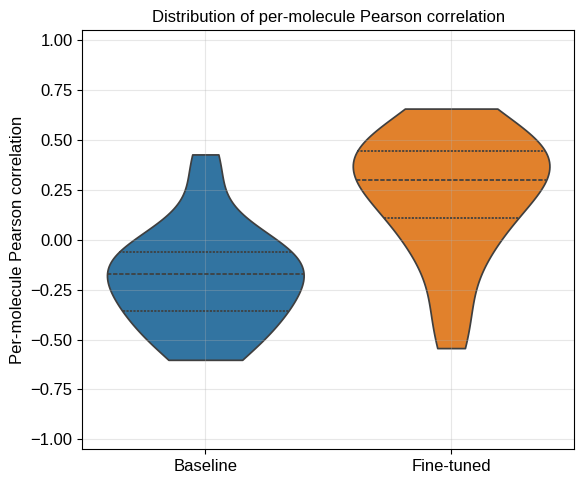

/tmp/ipython-input-177002499.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


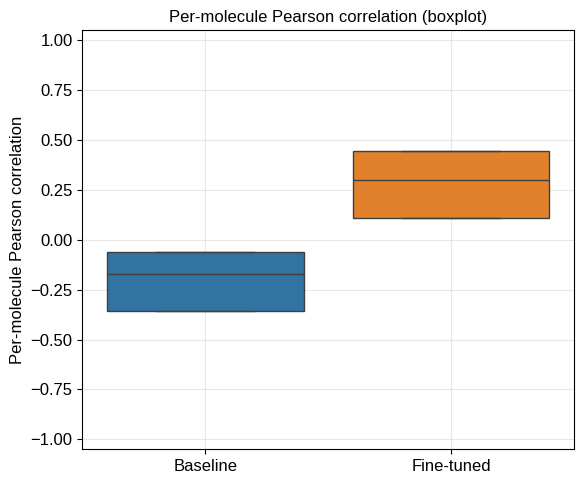

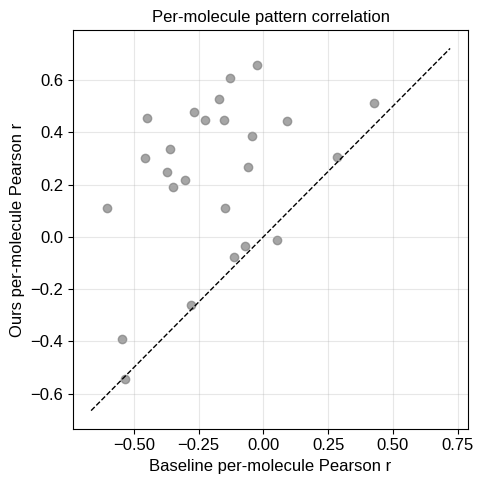

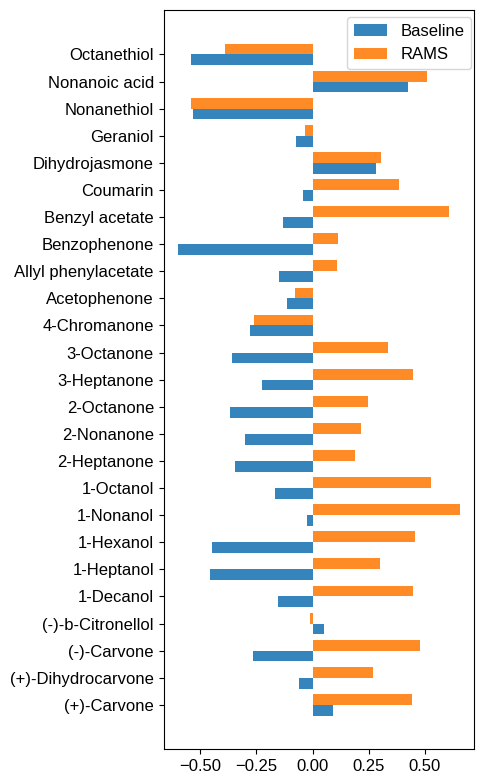

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --------------------------------------------------
# Required inputs (inherited from the previous section):
# gt_norm              (R, C): normalized ground truth
# pred_norm_ctl        (R, C): baseline model prediction
# pred_norm_standalone (R, C): fine-tuned model prediction
# include_mask_ctl     (R, C): baseline valid positions
# include_mask_std     (R, C): fine-tuned valid positions
# mol_names            length C: molecule names
# --------------------------------------------------

R, C = gt_norm.shape
eps = 1e-8

# ============ 1. Per-molecule Pearson correlation calculation =============

per_mol_r_ctl = np.full(C, np.nan, dtype=float)
per_mol_r_std = np.full(C, np.nan, dtype=float)

for j in range(C):
    # ----- baseline: molecule j -----
    mask_j_ctl = include_mask_ctl[:, j] & ~np.isnan(gt_norm[:, j]) & ~np.isnan(pred_norm_ctl[:, j])
    if np.sum(mask_j_ctl) >= 2:  # At least 2 receptors involved
        g = gt_norm[mask_j_ctl, j].astype(float)
        p = pred_norm_ctl[mask_j_ctl, j].astype(float)

        g_c = g - g.mean()
        p_c = p - p.mean()
        std_g = g_c.std()
        std_p = p_c.std()
        if std_g > eps and std_p > eps:
            per_mol_r_ctl[j] = np.mean(g_c * p_c) / (std_g * std_p)

    # ----- fine-tuned: molecule j -----
    mask_j_std = include_mask_std[:, j] & ~np.isnan(gt_norm[:, j]) & ~np.isnan(pred_norm_standalone[:, j])
    if np.sum(mask_j_std) >= 2:
        g = gt_norm[mask_j_std, j].astype(float)
        p = pred_norm_standalone[mask_j_std, j].astype(float)

        g_c = g - g.mean()
        p_c = p - p.mean()
        std_g = g_c.std()
        std_p = p_c.std()
        if std_g > eps and std_p > eps:
            per_mol_r_std[j] = np.mean(g_c * p_c) / (std_g * std_p)

# Only keep molecules that have Pearson r for both
paired_mask = (~np.isnan(per_mol_r_ctl)) & (~np.isnan(per_mol_r_std))
idxs = np.where(paired_mask)[0]

mol_names_paired = [mol_names[j] for j in idxs]
r_ctl_paired     = per_mol_r_ctl[idxs]
r_std_paired     = per_mol_r_std[idxs]

print(f"Number of valid molecules (Pearson can be calculated for both models): {len(idxs)} / {C}")
print(f"Baseline mean r = {np.nanmean(r_ctl_paired):.4f}")
print(f"Fine-tuned mean r = {np.nanmean(r_std_paired):.4f}")

# ============ 2. Per-molecule violin / box plot =============

df_mol = pd.DataFrame({
    "Baseline":   r_ctl_paired,
    "Fine-tuned": r_std_paired
})
df_mol_long = df_mol.melt(var_name="model", value_name="pearson_r")

COLOR_BASELINE = "#1f77b4"   # Blue
COLOR_FINETUNE = "#ff7f0e"   # Orange

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# Violin plot
plt.figure(figsize=(6, 5))
sns.violinplot(
    data=df_mol_long,
    x="model",
    y="pearson_r",
    cut=0,
    inner="quartile",
    palette={"Baseline": COLOR_BASELINE, "Fine-tuned": COLOR_FINETUNE}
)
plt.ylabel("Per-molecule Pearson correlation")
plt.xlabel("")
plt.ylim(-1.05, 1.05)
plt.title("Distribution of per-molecule Pearson correlation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Box plot
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=df_mol_long,
    x="model",
    y="pearson_r",
    showcaps=True,
    showfliers=False,
    whis=[25, 75],
    palette={"Baseline": COLOR_BASELINE, "Fine-tuned": COLOR_FINETUNE}
)
plt.ylabel("Per-molecule Pearson correlation")
plt.xlabel("")
plt.ylim(-1.05, 1.05)
plt.title("Per-molecule Pearson correlation (boxplot)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============ 3. Paired scatter: each molecule baseline vs finetune r =============

plt.figure(figsize=(5, 5))
plt.scatter(r_ctl_paired, r_std_paired, alpha=0.7, color="gray")
min_lim = min(np.min(r_ctl_paired), np.min(r_std_paired))
max_lim = max(np.max(r_ctl_paired), np.max(r_std_paired))
pad = (max_lim - min_lim) * 0.05 if max_lim > min_lim else 0.05
plt.plot([min_lim - pad, max_lim + pad],
         [min_lim - pad, max_lim + pad],
         'k--', linewidth=1)

plt.xlabel("Baseline per-molecule Pearson r")
plt.ylabel("Ours per-molecule Pearson r")
plt.title("Per-molecule pattern correlation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============ 4. Molecule-level grouped bar chart (optional) =============

x = np.arange(len(idxs))      # This can also be renamed to y, it's just an index
bar_h = 0.4                   # Bar height

# The chart becomes "vertical": fixed width, height increases with the number of molecules
plt.figure(figsize=(5, max(8, len(idxs) * 0.3)))

# Horizontal bar chart: x is Pearson r, y is molecule index
plt.barh(
    x - bar_h/2,
    r_ctl_paired,
    height=bar_h,
    color=COLOR_BASELINE,
    alpha=0.9,
    label="Baseline"
)

plt.barh(
    x + bar_h/2,
    r_std_paired,
    height=bar_h,
    color=COLOR_FINETUNE,
    alpha=0.9,
    label="RAMS"
)

ax = plt.gca()

# Y-axis is molecule name
plt.yticks(x, mol_names_paired)
# X-axis is Pearson r
#plt.xlabel("Per-molecule Pearson correlation")
# Don't move the y-axis to the right, for vertical charts, the left side is usually fine
# ax.yaxis.set_label_position("right")
# ax.yaxis.tick_right()

# Legend in the upper left corner (inside the chart)
legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(0.99, 0.99),  # Shrink slightly inward
    borderaxespad=0.0,
    frameon=True
)

#plt.grid(axis='x', alpha=0.3)  # When it's a vertical chart, the grid is usually along the x-axis
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/receptor/result/figures/pearson_bar.pdf",transparent=True)
plt.show()


[Baseline Pearson r] Five-number summary:
  min   = -0.6016
  Q1    = -0.3590
  median= -0.1695
  Q3    = -0.0604
  max   = 0.4280

[Ours Pearson r] Five-number summary:
  min   = -0.5429
  Q1    = 0.1103
  median= 0.3018
  Q3    = 0.4475
  max   = 0.6577


/tmp/ipython-input-184945150.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


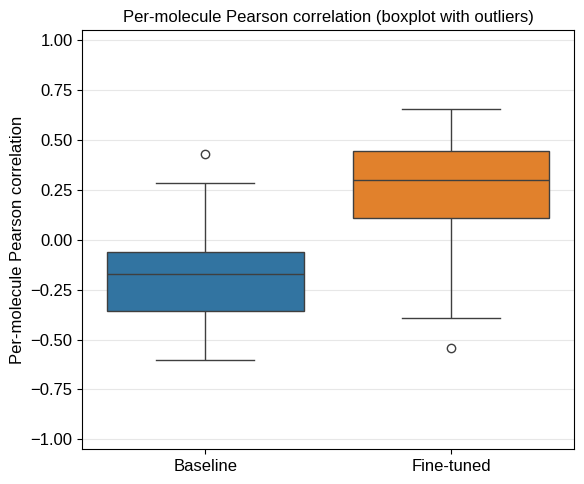

/tmp/ipython-input-184945150.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


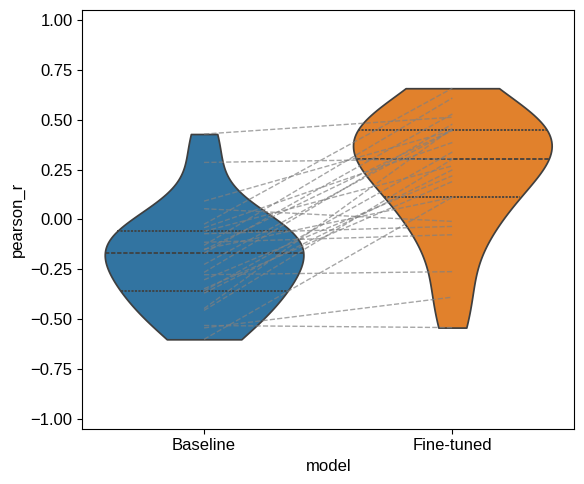

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you already have:
# r_ctl_paired: baseline Pearson r for each molecule
# r_std_paired: fine-tuned Pearson r for each molecule

# Assemble into DataFrame
df_mol = pd.DataFrame({
    "Baseline":   r_ctl_paired,
    "Fine-tuned": r_std_paired
})
df_long = df_mol.melt(var_name="model", value_name="pearson_r")

COLOR_BASELINE = "#1f77b4"   # Blue
COLOR_FINETUNE = "#ff7f0e"   # Orange

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# ============== 1) Pure box plot (no connecting lines, show outliers + print five-number summary) ==============

def five_number_summary(vals, name):
    vals = np.asarray(vals)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        print(f"[{name}] no valid values.")
        return
    v_min  = np.min(vals)
    q1     = np.percentile(vals, 25)
    med    = np.median(vals)
    q3     = np.percentile(vals, 75)
    v_max  = np.max(vals)
    print(f"\n[{name}] Five-number summary:")
    print(f"  min   = {v_min:.4f}")
    print(f"  Q1    = {q1:.4f}")
    print(f"  median= {med:.4f}")
    print(f"  Q3    = {q3:.4f}")
    print(f"  max   = {v_max:.4f}")

five_number_summary(r_ctl_paired, "Baseline Pearson r")
five_number_summary(r_std_paired, "Ours Pearson r")

plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=df_long,
    x="model",
    y="pearson_r",
    showcaps=True,
    showfliers=True,   # Show outliers
    whis=1.5,          # Use 1.5 IQR rule to define whiskers, outliers are plotted separately
    palette={"Baseline": COLOR_BASELINE, "Fine-tuned": COLOR_FINETUNE}
)

plt.ylabel("Per-molecule Pearson correlation")
plt.xlabel("")
plt.ylim(-1.05, 1.05)
plt.title("Per-molecule Pearson correlation (boxplot with outliers)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# ============== 2) Violin plot + dashed lines showing changes for each molecule ==============

plt.figure(figsize=(6, 5))

ax = sns.violinplot(
    data=df_long,
    x="model",
    y="pearson_r",
    cut=0,
    inner="quartile",
    palette={"Baseline": COLOR_BASELINE, "Fine-tuned": COLOR_FINETUNE}
)

# Find the positions of Baseline / Fine-tuned on the x-axis
x_pos = {label.get_text(): i for i, label in enumerate(ax.get_xticklabels())}
x0 = x_pos["Baseline"]
x1 = x_pos["Fine-tuned"]

# Draw dashed lines for each molecule: from baseline r -> finetuned r
for r0, r1 in zip(r_ctl_paired, r_std_paired):
    if np.isnan(r0) or np.isnan(r1):
        continue
    plt.plot(
        [x0, x1],
        [r0, r1],
        linestyle="--",
        color="gray",
        alpha=0.7,
        linewidth=1
    )

#plt.ylabel("Per-molecule Pearson correlation")
#plt.xlabel("")
plt.ylim(-1.05, 1.05)
#plt.title("Per-molecule Pearson correlation")
#plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/receptor/result/figures/pearson_violin.pdf",transparent=True)
plt.show()

In [ ]:
#torch.save(standalone.state_dict(), "/content/drive/MyDrive/receptor/models/model_checkpoint.pth")
